# Multi-Frame Gestalt Experiment with Frame-by-Frame Gibbs Sampling

This notebook runs tracking analysis with re-initialization at each frame:
1. Load and visualize depth/flow data
2. Compute 3D points and motion
3. Extract gestalt segmentation
4. Initialize with hierarchical k-means
5. Run full Gibbs sampling on first frame
6. Analyze and visualize results
7. Run frame-by-frame tracking with fresh Gibbs initialization (10 frames)
8. Save and visualize tracked segmentation masks

## Imports and Setup

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter, sobel
import matplotlib.cm as cm


# Set random seeds for reproducibility
RANDOM_SEED = 42

import random

# Seed all random number generators
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"Random seed set to {RANDOM_SEED} for reproducibility")
sys.path.append('/home/esli/GenMatter')

from gestalt_experiment_algorithm import *

Random seed set to 42 for reproducibility


## Configuration

In [2]:
explore_scene = 'scene_00001' # try 00, 22 next 
explore_texture = 'texture_22'
custom_hyperparams = {
    "number_of_blobs": 100,
    "number_of_hyperblobs": 5,
    "num_seeded_runs": 1,
}

number_of_blobs = custom_hyperparams["number_of_blobs"]
number_of_hyperblobs = custom_hyperparams["number_of_hyperblobs"]

print(f"Scene: {explore_scene}")
print(f"Texture: {explore_texture}")
print(f"Number of blobs: {number_of_blobs}")
print(f"Number of hyperblobs: {number_of_hyperblobs}")

Scene: scene_00001
Texture: texture_22
Number of blobs: 100
Number of hyperblobs: 5


In [3]:
def load_six_frame_gestalt_data(scene, texture):
    """Load depth and flow data for first 6 frames only"""
    # Load depth data from six-frame file
    depth_file = os.path.join('/home/esli/GenMatter/assets/from_thomas', 
                               scene, texture, 'output_six_frame_depths.npz')
    if not os.path.exists(depth_file):
        raise FileNotFoundError(f"Depth file not found: {depth_file}")
    
    depth_data = np.load(depth_file)
    if 'depths' in depth_data:
        inv_rel_depth = depth_data['depths']
    else:
        inv_rel_depth = next(iter(depth_data.values()))
    
    # Process depth data (matching load_gestalt_data processing)
    clipped_inverse_depth = np.clip(inv_rel_depth, 5, 1500)
    epsilon = 1e-6
    depth = 3000.0 / (clipped_inverse_depth + epsilon)
    depth = np.clip(depth, 0.25, 20.0)
    
    # Only use first 6 frames of depth
    depth = depth[:6]
    
    # Load flow data
    flow_file = os.path.join('/home/esli/GenMatter/raft_flows',
                             f'raft_flows_{scene}_{texture}.npz')
    if not os.path.exists(flow_file):
        raise FileNotFoundError(f"Flow file not found: {flow_file}")
    
    flow_data = np.load(flow_file)
    if 'flow' in flow_data:
        flow = flow_data['flow']
    else:
        flow = next(iter(flow_data.values()))
    
    # Only use first 5 frames of flow (for 6 depth frames)
    flow = flow[:5]
    
    return depth, flow


## STEP 1: Load Raw Data

Depth shape: (6, 1000, 1000)
Flow shape: (5, 520, 960, 2)


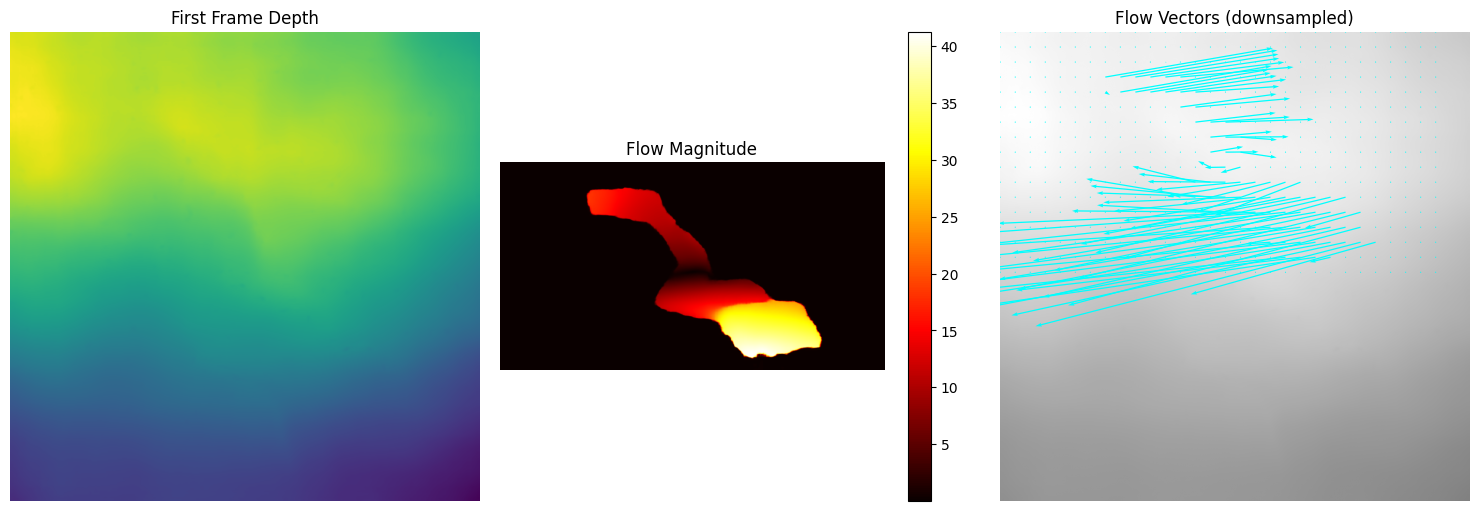

In [4]:
depth, flow = load_six_frame_gestalt_data(explore_scene, explore_texture)

print(f"Depth shape: {depth.shape}")  # [6, H, W]
print(f"Flow shape: {flow.shape}")    # [5, H, W, 2]

# Visualize first frame
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Depth map
axes[0].imshow(depth[0], cmap='viridis')
axes[0].set_title('First Frame Depth')
axes[0].axis('off')

# Flow magnitude
flow_mag = np.sqrt(flow[0, :, :, 0]**2 + flow[0, :, :, 1]**2)
im1 = axes[1].imshow(flow_mag, cmap='hot')
axes[1].set_title('Flow Magnitude')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1])

# Flow vectors (downsampled for visibility)
step = 32
y, x = np.mgrid[0:flow.shape[1]:step, 0:flow.shape[2]:step]
u = flow[0, ::step, ::step, 0]
v = flow[0, ::step, ::step, 1]
axes[2].imshow(depth[0], cmap='gray', alpha=0.5)
axes[2].quiver(x, y, u, -v, color='cyan', scale=50)
axes[2].set_title('Flow Vectors (downsampled)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [5]:
# Data is now loaded from `output_six_frame_depths.npz` with first 6 frames only (5 flow frames)

## STEP 2: Compute 3D Points and Motion

Downsampling from 1000 to 96 (factor: 8)


Valid motion vectors: 7109/46080 (15.43%) with magnitude >= 0.05
Points 3D shape: (5, 9216, 3)
Motion 3D shape: (5, 9216, 3)
Valid motion mask shape: (5, 9216)


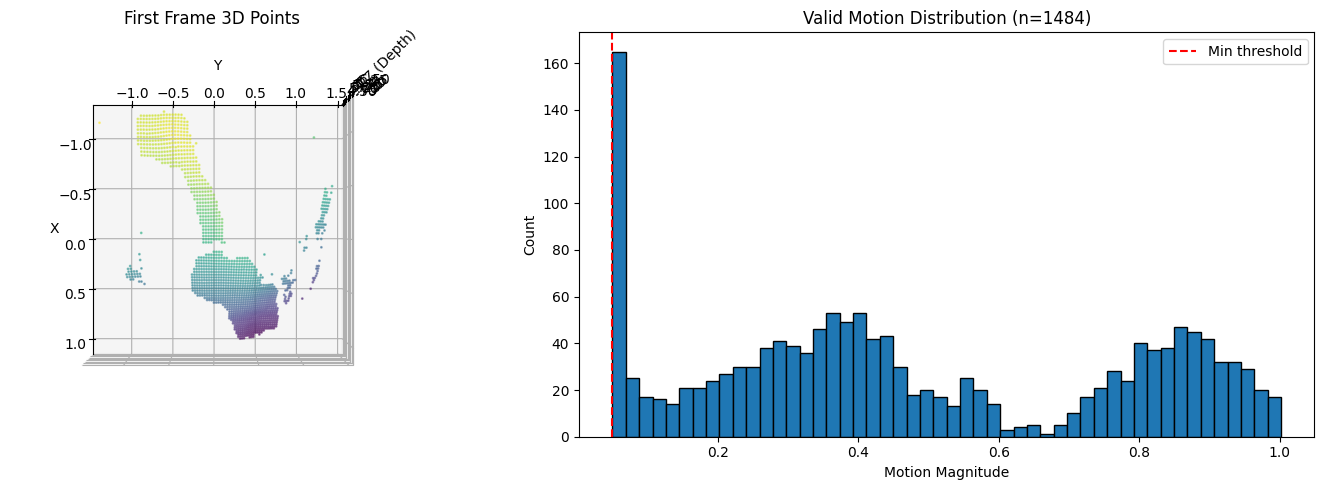

In [6]:
points_3d, motion_3d, motion_valid_mask = compute_3d_points_and_motion(
    depth, flow, downsample_factor=8, min_motion_magnitude=0.05, focal_length_scale=2.0
)

print(f"Points 3D shape: {points_3d.shape}")  # [N_frames, N_points, 3]
print(f"Motion 3D shape: {motion_3d.shape}")  # [N_frames, N_points, 3]
print(f"Valid motion mask shape: {motion_valid_mask.shape}")

# Get first frame data for visualization
tracked_points_frame0 = points_3d[0]  # [N_points, 3]
tracked_motion_vectors_frame0 = motion_3d[0]  # [N_points, 3]

# Visualize
fig = plt.figure(figsize=(15, 5))

# 3D scatter plot
ax1 = fig.add_subplot(121, projection='3d')
valid_points = tracked_points_frame0[motion_valid_mask[0]]
# Transpose XY for visualization only
valid_points_vis = valid_points[:, [1, 0, 2]]
ax1.scatter(valid_points_vis[:, 0], valid_points_vis[:, 1], valid_points_vis[:, 2], 
           c=valid_points[:, 2], cmap='viridis', s=1, alpha=0.5)
ax1.set_title('First Frame 3D Points')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z (Depth)')
ax1.view_init(elev=90, azim=0)

# Motion magnitude histogram
ax2 = fig.add_subplot(122)
motion_mag = np.linalg.norm(motion_3d[0], axis=1)
valid_motion_mag = motion_mag[motion_valid_mask[0]]
ax2.hist(valid_motion_mag, bins=50, edgecolor='black')
ax2.set_xlabel('Motion Magnitude')
ax2.set_ylabel('Count')
ax2.set_title(f'Valid Motion Distribution (n={np.sum(motion_valid_mask[0])})')
ax2.axvline(0.05, color='red', linestyle='--', label='Min threshold')
ax2.legend()

plt.tight_layout()
plt.show()

## STEP 3: Extract Gestalt Segmentation

In [7]:
# # Check if depth map is (nearly) planar or otherwise degenerate (i.e. no meaningful signal)

# def is_depth_degenerate(depth, tol_plane=1e-2, tol_std=1e-3, sample_frac=0.05, verbose=True):
#     """
#     Returns True if depth map is degenerate: either (1) nearly planar, (2) nearly constant, or (3) fails to vary much.

#     depth: [N_frames, H, W] or [H, W]
#     tol_plane: ratio threshold for plane fit residual (for planarity test)
#     tol_std:   absolute std threshold relative to depth range (for constant/flat test)
#     sample_frac: sample fraction for plane fit
#     """
#     import numpy as np

#     if depth.ndim == 3:
#         d = depth[0]
#     else:
#         d = depth

#     # Flatten for statistics
#     d_flat = d.flatten()
#     depth_range = np.ptp(d_flat)
#     depth_std = np.std(d_flat)
#     depth_min = np.min(d_flat)
#     depth_max = np.max(d_flat)

#     msg = []

#     # 1. Flat/constant check
#     if depth_range < 1e-6 or depth_std < tol_std:
#         if verbose:
#             print(f"WARNING: Depth range ({depth_range:.3g}) or std ({depth_std:.3g}) too small; depth might be constant or all zeros.")
#         msg.append("flat_or_constant")
#         return True

#     # 2. Plane fit check
#     H, W = d.shape
#     coords_y, coords_x = np.meshgrid(np.arange(H), np.arange(W), indexing='ij')
#     coords_flat = np.stack([coords_x.flatten(), coords_y.flatten()], axis=1)  # [n_pix, 2]
#     n_samples = int(sample_frac * d_flat.shape[0])
#     if n_samples < d_flat.shape[0]:
#         inds = np.random.choice(d_flat.shape[0], n_samples, replace=False)
#         X = coords_flat[inds]
#         Z = d_flat[inds]
#     else:
#         X = coords_flat
#         Z = d_flat
#     A = np.c_[X, np.ones(len(X))]
#     coeffs, residuals, rank, s = np.linalg.lstsq(A, Z, rcond=None)
#     Z_fit = A @ coeffs
#     resid_std = np.std(Z - Z_fit)
#     resid_mean = np.mean(Z - Z_fit)
#     plane_fit_ratio = resid_std / (depth_range + 1e-9)
#     if verbose:
#         print(f"Depth plane fit coefficients: {coeffs}")
#         print(f"Residual std: {resid_std:.5g}, mean: {resid_mean:.5g}")
#         print(f"Residual std/dynamic range ratio: {plane_fit_ratio:.5g}")
#     if plane_fit_ratio < tol_plane:
#         if verbose:
#             print("WARNING: Depth is nearly planar (failed depth estimate likely: only plane structure).")
#         msg.append("planar")
#         return True

#     # depth is not degenerate by these tests
#     return False

# is_degenerate = is_depth_degenerate(depth)
# if is_degenerate:
#     print("WARNING: Depth estimate appears to have failed or has no valid signal (degenerate!).")
# else:
#     print("Depth has non-degenerate structure.")


Target resolution: 96x96
Extracting heuristic-based gestalt segmentation for all frames...
Debug: flow_magnitude shape: 9216, depth_flat shape: 9216, points shape: 9216
Segmentation extracted: 1843/9216 points (20.0%) in ROI
Gestalt segmentation (heuristic): 1843 / 9216 points
Combined mask (heuristic & motion valid): 1340 / 9216 points
Initialized heuristic segmentation storage for 5 frames

Loading ground truth masks for evaluation...
Loaded 6 ground truth masks for evaluation

First frame comparison:
  Heuristic segmentation: 1843 points
  Ground truth: 1441 points
  Overlap (intersection): 1435 points
  IoU: 0.776


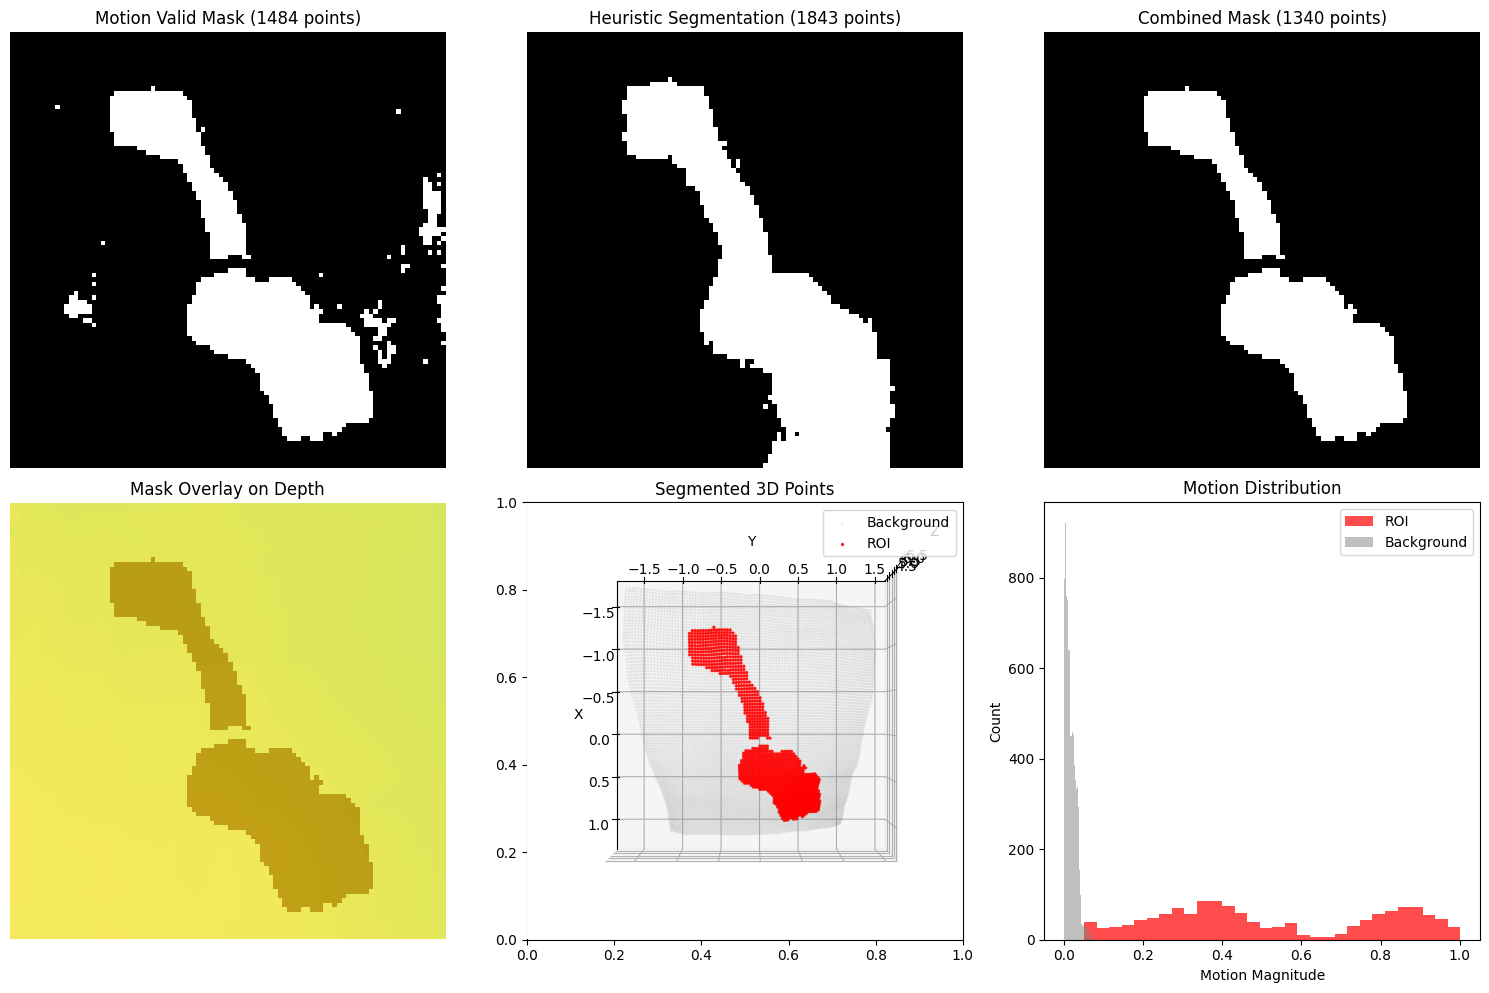

In [8]:
# Compute target size (matching compute_3d_points_and_motion downsampling)
orig_H, orig_W = depth.shape[1:3]
target_hw = max(orig_H, orig_W) // 8  # Match downsample_factor=8
target_hw = (target_hw // 32) * 32  # Round to nearest multiple of 32
if target_hw < 32:
    target_hw = 32

print(f"Target resolution: {target_hw}x{target_hw}")

# Resize to square
depth_sq = resize_to_square(depth, target_hw)
flow_sq = resize_to_square(flow, target_hw)

# Extract HEURISTIC-BASED gestalt segmentation for ALL frames (NOT using ground truth)
# This is used for tracking to identify the ROI hyperblob in each frame
print("Extracting heuristic-based gestalt segmentation for all frames...")

# For simplicity in tracking, we'll use the first frame heuristic segmentation 
# to identify the ROI, then track that object through subsequent frames
first_frame_seg = extract_gestalt_segmentation(depth_sq, flow_sq, points_3d)
combined_mask = first_frame_seg & motion_valid_mask[0]

print(f"Gestalt segmentation (heuristic): {np.sum(first_frame_seg)} / {len(first_frame_seg)} points")
print(f"Combined mask (heuristic & motion valid): {np.sum(combined_mask)} / {len(combined_mask)} points")

# For tracking: create heuristic segmentation masks for all frames
# These are used to determine which hyperblob is the ROI in each frame
# Note: We could compute fresh segmentation for each frame, but for consistency
# we'll use a simpler approach: use the first frame to identify the ROI hyperblob,
# then track it through subsequent frames based on the model's assignments

# Create array to store heuristic segmentation for all frames (for tracking)
num_tracking_frames = min(len(depth_sq), len(points_3d))
all_frame_segmentation_masks = np.zeros((num_tracking_frames, len(first_frame_seg)), dtype=bool)
all_frame_segmentation_masks[0] = first_frame_seg

# For frames 1+, we'll determine the ROI based on overlap with previous frame's tracked mask
# This will be filled in during the tracking loop
print(f"Initialized heuristic segmentation storage for {num_tracking_frames} frames")

# Load ground truth masks for EVALUATION ONLY (not for segmentation proposal)
print(f"\nLoading ground truth masks for evaluation...")
from PIL import Image

# Use the proper function from gestalt_experiment_algorithm
gt_masks_raw = load_ground_truth_masks(explore_scene, explore_texture, num_frames=len(depth_sq))

if gt_masks_raw is not None:
    # Resize ground truth masks to match our downsampled resolution
    gt_masks_resized = []
    for gt_mask in gt_masks_raw:
        # Resize to target_hw x target_hw
        gt_mask_img = Image.fromarray(gt_mask.astype(np.uint8) * 255)
        gt_mask_resized_img = gt_mask_img.resize((target_hw, target_hw), Image.NEAREST)
        gt_mask_resized = np.array(gt_mask_resized_img) > 127
        gt_masks_resized.append(gt_mask_resized.flatten())
    
    gt_masks_resized = np.array(gt_masks_resized)
    print(f"Loaded {len(gt_masks_resized)} ground truth masks for evaluation")
    
    # Compare first frame heuristic segmentation with ground truth
    gt_first_frame = gt_masks_resized[0]
    print(f"\nFirst frame comparison:")
    print(f"  Heuristic segmentation: {np.sum(first_frame_seg)} points")
    print(f"  Ground truth: {np.sum(gt_first_frame)} points")
    print(f"  Overlap (intersection): {np.sum(first_frame_seg & gt_first_frame)} points")
    print(f"  IoU: {np.sum(first_frame_seg & gt_first_frame) / np.sum(first_frame_seg | gt_first_frame):.3f}")
else:
    print("  Warning: Ground truth masks not available")
    gt_masks_resized = None

# Visualize masks
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Motion mask
axes[0, 0].imshow(motion_valid_mask[0].reshape((target_hw, target_hw)), cmap='gray')
axes[0, 0].set_title(f'Motion Valid Mask ({np.sum(motion_valid_mask[0])} points)')
axes[0, 0].axis('off')

# Heuristic segmentation (NOT ground truth)
axes[0, 1].imshow(first_frame_seg.reshape((target_hw, target_hw)), cmap='gray')
axes[0, 1].set_title(f'Heuristic Segmentation ({np.sum(first_frame_seg)} points)')
axes[0, 1].axis('off')

# Combined mask (heuristic & motion valid)
axes[0, 2].imshow(combined_mask.reshape((target_hw, target_hw)), cmap='gray')
axes[0, 2].set_title(f'Combined Mask ({np.sum(combined_mask)} points)')
axes[0, 2].axis('off')

# Overlay on depth
axes[1, 0].imshow(depth[0], cmap='viridis')
axes[1, 0].imshow(combined_mask.reshape((target_hw, target_hw)), cmap='Reds', alpha=0.3)
axes[1, 0].set_title('Mask Overlay on Depth')
axes[1, 0].axis('off')

# 3D visualization
ax_3d = fig.add_subplot(2, 3, 5, projection='3d')
roi_points = tracked_points_frame0[combined_mask]
bg_points = tracked_points_frame0[~combined_mask]
# Transpose XY for visualization only
roi_points_vis = roi_points[:, [1, 0, 2]]
bg_points_vis = bg_points[:, [1, 0, 2]]
ax_3d.scatter(bg_points_vis[:, 0], bg_points_vis[:, 1], bg_points_vis[:, 2], 
             c='gray', s=1, alpha=0.1, label='Background')
ax_3d.scatter(roi_points_vis[:, 0], roi_points_vis[:, 1], roi_points_vis[:, 2], 
             c='red', s=2, alpha=0.8, label='ROI')
ax_3d.set_title('Segmented 3D Points')
ax_3d.set_xlabel('X')
ax_3d.set_ylabel('Y')
ax_3d.set_zlabel('Z')
ax_3d.legend()
ax_3d.view_init(elev=90, azim=0)

# Motion magnitude of ROI
motion_mag = np.linalg.norm(tracked_motion_vectors_frame0, axis=1)
axes[1, 2].hist(motion_mag[combined_mask], bins=30, alpha=0.7, label='ROI', color='red')
axes[1, 2].hist(motion_mag[~combined_mask], bins=30, alpha=0.5, label='Background', color='gray')
axes[1, 2].set_xlabel('Motion Magnitude')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Motion Distribution')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

## Ground Truth vs Heuristic Segmentation Comparison

Compare the heuristic-based gestalt segmentation (used for initialization) with the ground truth masks (used only for evaluation).


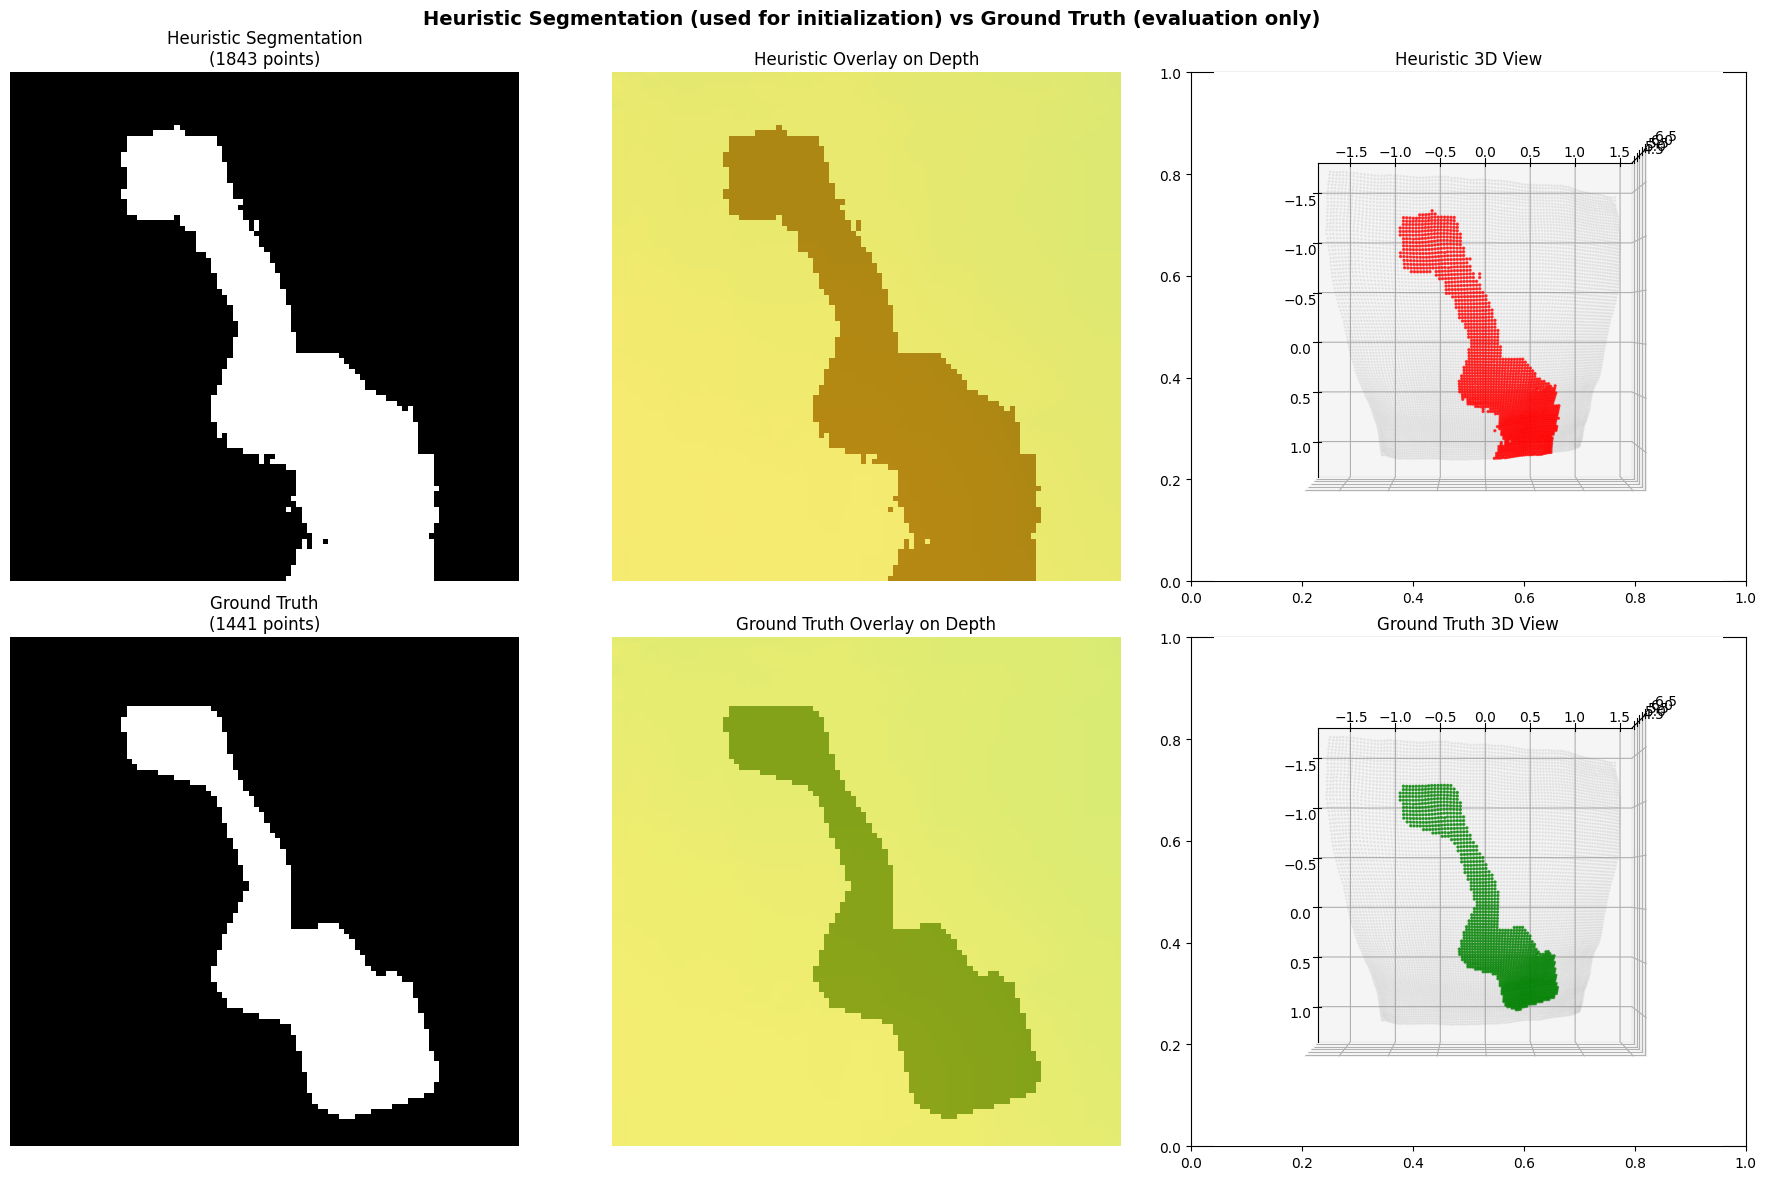


SEGMENTATION COMPARISON
Heuristic segmentation: 1843 points (20.0%)
Ground truth: 1441 points (15.6%)
Intersection (overlap): 1435 points
Union: 1849 points
IoU (Intersection over Union): 0.776
Precision (heuristic vs GT): 0.779
Recall (heuristic vs GT): 0.996


In [9]:
# Visualize comparison between heuristic and ground truth segmentation
if gt_masks_resized is not None:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Row 1: Heuristic segmentation
    axes[0, 0].imshow(first_frame_seg.reshape((target_hw, target_hw)), cmap='gray')
    axes[0, 0].set_title(f'Heuristic Segmentation\n({np.sum(first_frame_seg)} points)', fontsize=12)
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(depth[0], cmap='viridis')
    axes[0, 1].imshow(first_frame_seg.reshape((target_hw, target_hw)), cmap='Reds', alpha=0.4)
    axes[0, 1].set_title('Heuristic Overlay on Depth', fontsize=12)
    axes[0, 1].axis('off')
    
    # Heuristic 3D view
    ax_3d_heur = fig.add_subplot(2, 3, 3, projection='3d')
    heur_pts = tracked_points_frame0[first_frame_seg]
    heur_pts_vis = heur_pts[:, [1, 0, 2]]
    bg_pts = tracked_points_frame0[~first_frame_seg]
    bg_pts_vis = bg_pts[:, [1, 0, 2]]
    ax_3d_heur.scatter(bg_pts_vis[:, 0], bg_pts_vis[:, 1], bg_pts_vis[:, 2], 
                       c='gray', s=1, alpha=0.1)
    ax_3d_heur.scatter(heur_pts_vis[:, 0], heur_pts_vis[:, 1], heur_pts_vis[:, 2], 
                       c='red', s=2, alpha=0.7)
    ax_3d_heur.set_title('Heuristic 3D View', fontsize=12)
    ax_3d_heur.view_init(elev=90, azim=0)
    
    # Row 2: Ground truth
    gt_first = gt_masks_resized[0]
    axes[1, 0].imshow(gt_first.reshape((target_hw, target_hw)), cmap='gray')
    axes[1, 0].set_title(f'Ground Truth\n({np.sum(gt_first)} points)', fontsize=12)
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(depth[0], cmap='viridis')
    axes[1, 1].imshow(gt_first.reshape((target_hw, target_hw)), cmap='Greens', alpha=0.4)
    axes[1, 1].set_title('Ground Truth Overlay on Depth', fontsize=12)
    axes[1, 1].axis('off')
    
    # Ground truth 3D view
    ax_3d_gt = fig.add_subplot(2, 3, 6, projection='3d')
    gt_pts = tracked_points_frame0[gt_first]
    gt_pts_vis = gt_pts[:, [1, 0, 2]]
    bg_pts_gt = tracked_points_frame0[~gt_first]
    bg_pts_gt_vis = bg_pts_gt[:, [1, 0, 2]]
    ax_3d_gt.scatter(bg_pts_gt_vis[:, 0], bg_pts_gt_vis[:, 1], bg_pts_gt_vis[:, 2], 
                     c='gray', s=1, alpha=0.1)
    ax_3d_gt.scatter(gt_pts_vis[:, 0], gt_pts_vis[:, 1], gt_pts_vis[:, 2], 
                     c='green', s=2, alpha=0.7)
    ax_3d_gt.set_title('Ground Truth 3D View', fontsize=12)
    ax_3d_gt.view_init(elev=90, azim=0)
    
    plt.suptitle('Heuristic Segmentation (used for initialization) vs Ground Truth (evaluation only)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print detailed comparison
    print("\n" + "="*70)
    print("SEGMENTATION COMPARISON")
    print("="*70)
    print(f"Heuristic segmentation: {np.sum(first_frame_seg)} points ({100*np.sum(first_frame_seg)/len(first_frame_seg):.1f}%)")
    print(f"Ground truth: {np.sum(gt_first)} points ({100*np.sum(gt_first)/len(gt_first):.1f}%)")
    print(f"Intersection (overlap): {np.sum(first_frame_seg & gt_first)} points")
    print(f"Union: {np.sum(first_frame_seg | gt_first)} points")
    print(f"IoU (Intersection over Union): {np.sum(first_frame_seg & gt_first) / np.sum(first_frame_seg | gt_first):.3f}")
    print(f"Precision (heuristic vs GT): {np.sum(first_frame_seg & gt_first) / np.sum(first_frame_seg):.3f}")
    print(f"Recall (heuristic vs GT): {np.sum(first_frame_seg & gt_first) / np.sum(gt_first):.3f}")
    print("="*70)
else:
    print("Ground truth masks not available - skipping comparison visualization")


## STEP 4: Hierarchical K-Means Clustering

K-means CHM created
ROI blobs: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
ROI hyperblobs: [0]


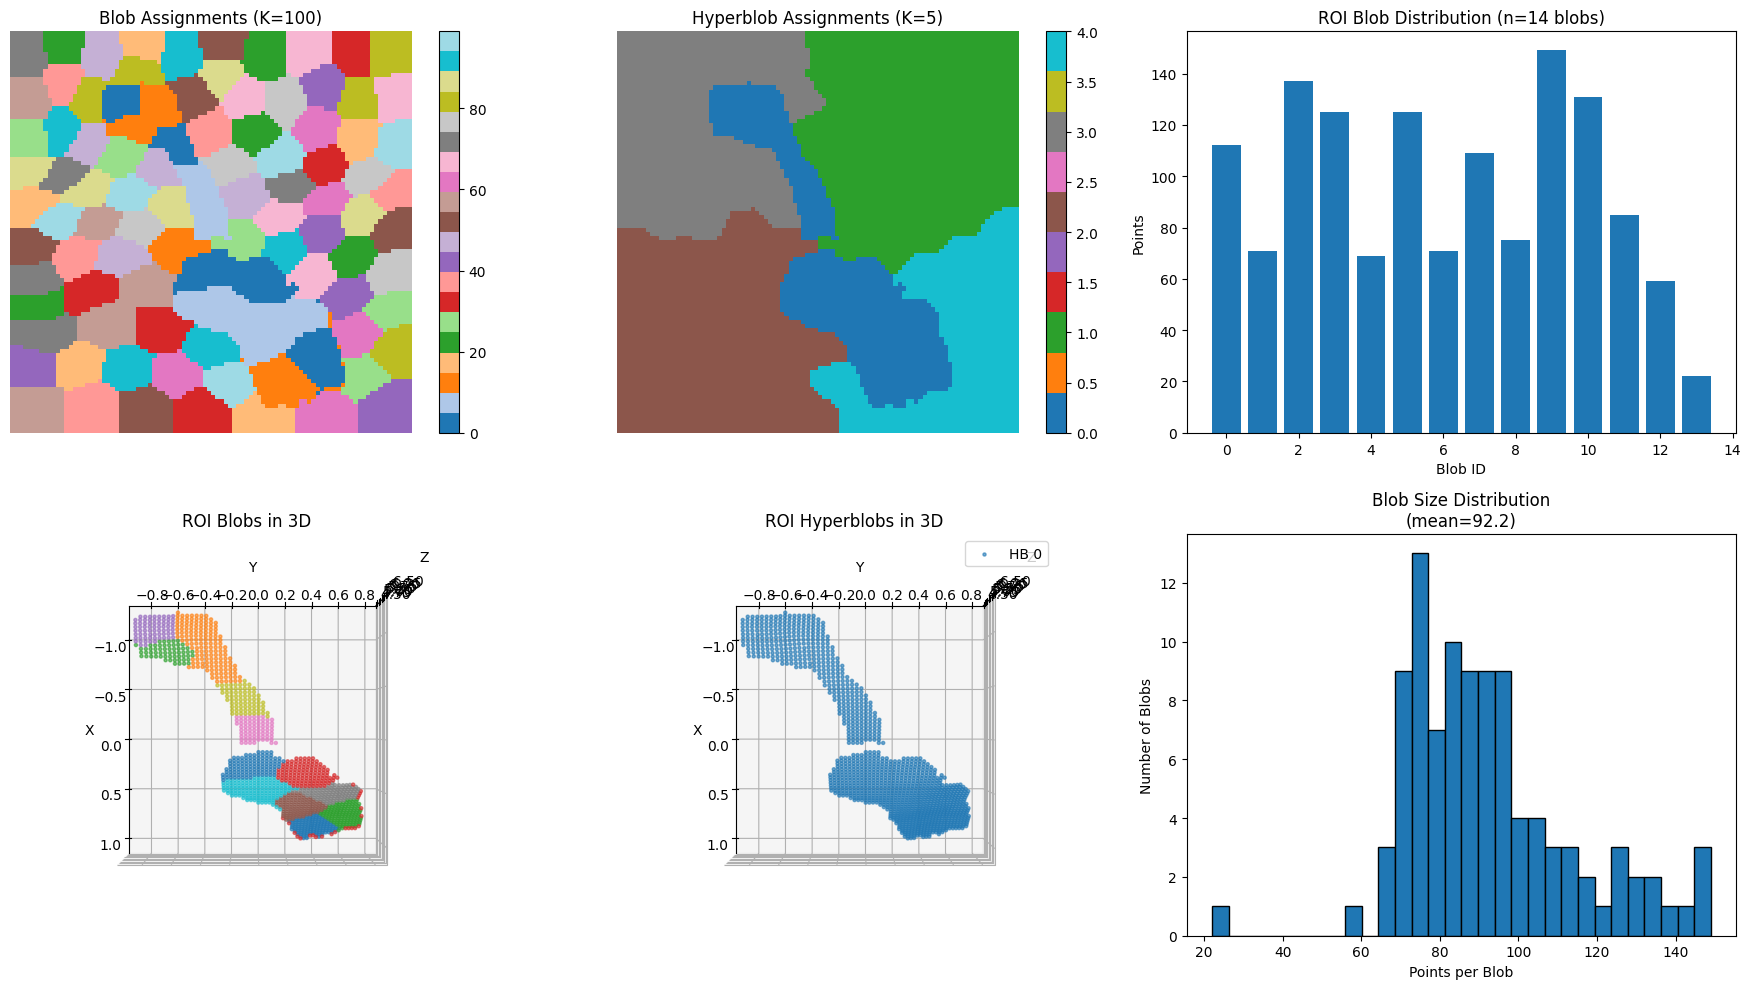

In [10]:
# Initialize with hierarchical k-means
# Note: Pass full 3D arrays, function will extract frame_idx=0 internally
kmeans_chm, roi_blob_indices, roi_hyperblob_indices = make_hierarchical_kmeans_chm_with_mask_fixed_hyperblob(
    points_3d, number_of_blobs, number_of_hyperblobs,
    segmentation_mask=combined_mask, motion_vectors=motion_3d, frame_idx=0
)

print(f"K-means CHM created")
print(f"ROI blobs: {roi_blob_indices}")
print(f"ROI hyperblobs: {roi_hyperblob_indices}")

# Get assignments from choice map
blob_assignments = np.array(kmeans_chm['datapoints', 'blob_assignments'])
hyperblob_assignments = np.array(kmeans_chm['blobs', 'hyperblob_assignments'])

# Visualize clustering
fig = plt.figure(figsize=(18, 10))

# Blob-level clustering (2D)
ax1 = fig.add_subplot(2, 3, 1)
blob_img = blob_assignments.reshape((target_hw, target_hw))
im1 = ax1.imshow(blob_img, cmap='tab20')
ax1.set_title(f'Blob Assignments (K={number_of_blobs})')
ax1.axis('off')
plt.colorbar(im1, ax=ax1)

# Hyperblob-level clustering (via blob mapping)
ax2 = fig.add_subplot(2, 3, 2)
pixel_hyperblobs = np.zeros_like(blob_assignments)
for i in range(len(blob_assignments)):
    blob_id = blob_assignments[i]
    if blob_id < number_of_blobs:
        pixel_hyperblobs[i] = hyperblob_assignments[blob_id]
    else:
        pixel_hyperblobs[i] = -1
im2 = ax2.imshow(pixel_hyperblobs.reshape((target_hw, target_hw)), cmap='tab10')
ax2.set_title(f'Hyperblob Assignments (K={number_of_hyperblobs})')
ax2.axis('off')
plt.colorbar(im2, ax=ax2)

# ROI blobs histogram
ax3 = fig.add_subplot(2, 3, 3)
roi_blob_assignments = blob_assignments[combined_mask]
unique_blobs, counts = np.unique(roi_blob_assignments[roi_blob_assignments < number_of_blobs], 
                                  return_counts=True)
ax3.bar(unique_blobs, counts)
ax3.set_xlabel('Blob ID')
ax3.set_ylabel('Points')
ax3.set_title(f'ROI Blob Distribution (n={len(unique_blobs)} blobs)')

# 3D visualization of blobs
ax4 = fig.add_subplot(2, 3, 4, projection='3d')
roi_mask = combined_mask
for blob_id in roi_blob_indices:
    mask = (blob_assignments == blob_id) & roi_mask
    if np.sum(mask) > 0:
        pts = tracked_points_frame0[mask]
        pts_vis = pts[:, [1, 0, 2]]  # Transpose for visualization
        ax4.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=5, alpha=0.6)
ax4.set_title('ROI Blobs in 3D')
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.view_init(elev=90, azim=0)

# 3D visualization of hyperblobs
ax5 = fig.add_subplot(2, 3, 5, projection='3d')
for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(hyperblob_assignments == hb_id)[0]
    mask = np.isin(blob_assignments, hb_blobs) & roi_mask
    if np.sum(mask) > 0:
        pts = tracked_points_frame0[mask]
        pts_vis = pts[:, [1, 0, 2]]  # Transpose for visualization
        ax5.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=5, alpha=0.6, label=f'HB {hb_id}')
ax5.set_title('ROI Hyperblobs in 3D')
ax5.set_xlabel('X')
ax5.set_ylabel('Y')
ax5.set_zlabel('Z')
ax5.legend()
ax5.view_init(elev=90, azim=0)

# Blob size distribution
ax6 = fig.add_subplot(2, 3, 6)
all_blob_sizes = [np.sum(blob_assignments == i) for i in range(number_of_blobs)]
ax6.hist(all_blob_sizes, bins=30, edgecolor='black')
ax6.set_xlabel('Points per Blob')
ax6.set_ylabel('Number of Blobs')
ax6.set_title(f'Blob Size Distribution\n(mean={np.mean(all_blob_sizes):.1f})')

plt.tight_layout()
plt.show()

## STEP 5: Initialize HDGMM Hyperparameters

In [11]:
# Extract empirical statistics from k-means clustering
blob_means = np.array([tracked_points_frame0[blob_assignments == i].mean(axis=0) 
                       for i in range(number_of_blobs)])

# Debug: Check hyperblob assignments
print("\nDEBUG: Hyperblob assignment distribution:")
for i in range(number_of_hyperblobs):
    n_blobs = np.sum(hyperblob_assignments == i)
    print(f"  Hyperblob {i}: {n_blobs} blobs")

# Compute hyperblob means, handling empty clusters
hyperblob_means_list = []
for i in range(number_of_hyperblobs):
    hb_blob_means = blob_means[hyperblob_assignments == i]
    if len(hb_blob_means) > 0:
        hyperblob_means_list.append(hb_blob_means.mean(axis=0))
    else:
        # Use overall blob mean for empty hyperblob
        print(f"  WARNING: Hyperblob {i} has no blobs! Using overall blob mean.")
        hyperblob_means_list.append(blob_means.mean(axis=0))

hyperblob_means = np.array(hyperblob_means_list)

empirical_mu_H = hyperblob_means.mean(axis=0)
empirical_sigma_H = np.std(hyperblob_means, axis=0).mean()

print(f"\nDEBUG: After computation:")
print(f"  hyperblob_means shape: {hyperblob_means.shape}")
print(f"  empirical_mu_H: {empirical_mu_H}")
print(f"  empirical_sigma_H: {empirical_sigma_H}")

# Compute empirical covariances
blob_points = [tracked_points_frame0[blob_assignments == i] for i in range(number_of_blobs)]
blob_covs = [np.cov(pts.T) if len(pts) > 3 else np.eye(3) * 0.01 for pts in blob_points]
empirical_Psi_B = np.mean(blob_covs, axis=0)

hyperblob_blob_means = [blob_means[hyperblob_assignments == i] for i in range(number_of_hyperblobs)]
hyperblob_covs = [np.cov(means.T) if len(means) > 3 else np.eye(3) * 0.1 
                  for means in hyperblob_blob_means]
empirical_Psi_H = np.mean(hyperblob_covs, axis=0)

# Velocity covariances
blob_velocities = [tracked_motion_vectors_frame0[blob_assignments == i] for i in range(number_of_blobs)]
blob_vel_covs = [np.cov(vels.T) if len(vels) > 3 else np.eye(3) * 0.01 for vels in blob_velocities]
empirical_Psi_V = np.mean(blob_vel_covs, axis=0)

# Concentration parameters (degrees of freedom)
empirical_nu_H = 5.0
empirical_nu_B = 5.0
empirical_nu_V = 5.0

# Helper functions for parameter types
f_ = lambda x: jnp.float32(x)
snp = lambda x: StaticJnp(jnp.array(x))

# Get dimensions from k-means results
num_datapoints = kmeans_chm['datapoints', 'datapoint_positions'].shape[0]
num_blobs = number_of_blobs
num_hyperblobs = number_of_hyperblobs

# Create hyperparameters with all required fields
  # IMPORTANT: Rotation and translation hyperparameters for tracking
hypers = HDGMM_Hyperparams.create(
    outlier_prob=f_(0.001),
    outlier_velocity_gamma_shape=f_(7.5),
    outlier_velocity_gamma_rate=f_(0.5),
    alpha=f_(1.0),
    beta=f_(1.0),
    mu_H=empirical_mu_H,
    sigma_H=empirical_sigma_H,
    nu_H=empirical_nu_H,
    Psi_H=empirical_Psi_H,
    nu_B=empirical_nu_B,
    Psi_B=empirical_Psi_B,
    sigma_V=f_(10e14),
    nu_V=empirical_nu_V,
    Psi_V=empirical_Psi_V,
    translation_gaussian_scale=snp(f_(0.2)),
    translation_max_radius=snp(0.35),
    translation_num_radii_cells=snp(15),
    translation_theta_step_deg=snp(15),
    # Rotation hyperparameters - broader proposals for ~4 deg rotations
    rotation_vmf_kappa=snp(f_(5.0)),      # Weak prior for broad proposals
    rotation_angle_max_deg=snp(15),       # Allow up to 15 degrees (3-4x expected)
    rotation_angle_step_deg=snp(1.0),     # 1 degree steps for good coverage
    n_hyperblobs=num_hyperblobs,
    n_blobs=num_blobs,
    n_datapoints=num_datapoints
)

# Define Gibbs sampling configuration
# NOTE: Do not allow updating of pixel assignments (blob_assignments), as instructed.
# Set 'blob_assignments' and 'hyperblob_assignments' to False
GIBBS_DIALS = {
    "blob_weights": True,
    "hyperblob_weights": False,
    "blob_assignments": True, 
    "hyperblob_assignments": False,  # <--- DO NOT UPDATE PIXEL ASSIGNMENTS
    "hyperblob_covs": False,
    "blob_covs": True,
    "blob_vel_covs": True,
    "blob_vel_means": True,
    "hyperblob_means": False,  # Keep hyperblob structure fixed
    "blob_means": True,  # Allow updates with soft prior
    'hyperblob_rot_vels': True,     # ENABLED - was False!
    'hyperblob_trans_vels': True    # ENABLED - was False!
}

print("Hyperparameters initialized:")
print(f"  n_datapoints: {num_datapoints}")
print(f"  n_blobs: {num_blobs}")
print(f"  n_hyperblobs: {num_hyperblobs}")
print(f"  mu_H: {empirical_mu_H}")
print(f"  sigma_H: {empirical_sigma_H:.4f}")
print(f"  nu_H: {empirical_nu_H}")
print(f"  nu_B: {empirical_nu_B}")
print(f"  nu_V: {empirical_nu_V}")
print(f"\nRotation hyperparameters (for tracking):")
print(f"  rotation_vmf_kappa: 5.0 (weak prior for broad proposals)")
print(f"  rotation_angle_max_deg: 15")
print(f"  rotation_angle_step_deg: 1.0")
print(f"\nGibbs dials (first frame):")
for key, val in GIBBS_DIALS.items():
    print(f"  {key}: {val}")



DEBUG: Hyperblob assignment distribution:
  Hyperblob 0: 14 blobs
  Hyperblob 1: 29 blobs
  Hyperblob 2: 21 blobs
  Hyperblob 3: 23 blobs
  Hyperblob 4: 13 blobs

DEBUG: After computation:
  hyperblob_means shape: (5, 3)
  empirical_mu_H: [-0.01260687 -0.06070298  5.561611  ]
  empirical_sigma_H: 0.590766966342926
Hyperparameters initialized:
  n_datapoints: 9216
  n_blobs: 100
  n_hyperblobs: 5
  mu_H: [-0.01260687 -0.06070298  5.561611  ]
  sigma_H: 0.5908
  nu_H: 5.0
  nu_B: 5.0
  nu_V: 5.0

Rotation hyperparameters (for tracking):
  rotation_vmf_kappa: 5.0 (weak prior for broad proposals)
  rotation_angle_max_deg: 15
  rotation_angle_step_deg: 1.0

Gibbs dials (first frame):
  blob_weights: True
  hyperblob_weights: False
  blob_assignments: True
  hyperblob_assignments: False
  hyperblob_covs: False
  blob_covs: True
  blob_vel_covs: True
  blob_vel_means: True
  hyperblob_means: False
  blob_means: True
  hyperblob_rot_vels: True
  hyperblob_trans_vels: True


## STEP 6: Run Full Gibbs Sampling on First Frame

In [12]:
import jax
from jax.random import key as jkey

# Initialize random key
# Initialize JAX random key with fixed seed for reproducibility
key = jkey(RANDOM_SEED)
print(f"JAX key initialized with seed {RANDOM_SEED}")

# Initialize model with importance sampling
key, key_importance = jax.random.split(key)
init_tr, _ = model_jimportance(key_importance, kmeans_chm, (hypers,))
init_hdgmm_state = init_tr.get_retval()

print("Initial state created via importance sampling")

# Run Gibbs burn-in
num_gibbs_iterations = 50
num_inner_loops = 5

print(f"\nRunning {num_gibbs_iterations} Gibbs iterations...")
key, init_gibbs_key = jax.random.split(key)

gibbs_wtrs = hdgmm_full_gibbs(
    init_gibbs_key, 
    init_hdgmm_state, 
    num_gibbs_iterations, 
    GIBBS_DIALS, 
    use_weighted_blobs=True, 
    num_gibbs_inner_loops=num_inner_loops
)

print("Gibbs sampling complete!")

# Get final converged state
converged_state = gibbs_wtrs[-1].retval

JAX key initialized with seed 42
Initial state created via importance sampling

Running 50 Gibbs iterations...
Gibbs sampling complete!


In [13]:
# ============================================================================
# EXTRACT ASSIGNMENTS FROM GIBBS SAMPLES FOR UNCERTAINTY ANALYSIS
# ============================================================================

print("\nExtracting blob and hyperblob assignments from Gibbs samples...")

# Extract assignments from all Gibbs samples
gibbs_blob_assignments = []
gibbs_hyperblob_assignments = []

num_samples = len(gibbs_wtrs)
print(f"Total samples: {num_samples}")

# Use range + indexing instead of direct iteration to avoid pytree issues
for sample_idx in range(num_samples):
    sample = gibbs_wtrs[sample_idx]
    
    # Extract blob assignments for all datapoints
    blob_assigns = np.array(sample.retval.datapoints_state.blob_assignments)
    gibbs_blob_assignments.append(blob_assigns)
    
    # Extract hyperblob assignments for blobs
    hyperblob_assigns = np.array(sample.retval.blobs_state.hyperblob_assignments)
    gibbs_hyperblob_assignments.append(hyperblob_assigns)

# Convert to numpy arrays: (num_samples, num_pixels)
gibbs_blob_assignments = np.array(gibbs_blob_assignments)
gibbs_hyperblob_assignments = np.array(gibbs_hyperblob_assignments)

print(f"✓ Extracted {len(gibbs_blob_assignments)} samples")
print(f"  Blob assignments shape: {gibbs_blob_assignments.shape}")
print(f"  Hyperblob assignments shape: {gibbs_hyperblob_assignments.shape}")


Extracting blob and hyperblob assignments from Gibbs samples...
Total samples: 51
✓ Extracted 51 samples
  Blob assignments shape: (51, 9216)
  Hyperblob assignments shape: (51, 100)



PERCEPTUAL UNCERTAINTY ANALYSIS

Using last 51 samples (after 0 burn-in)...


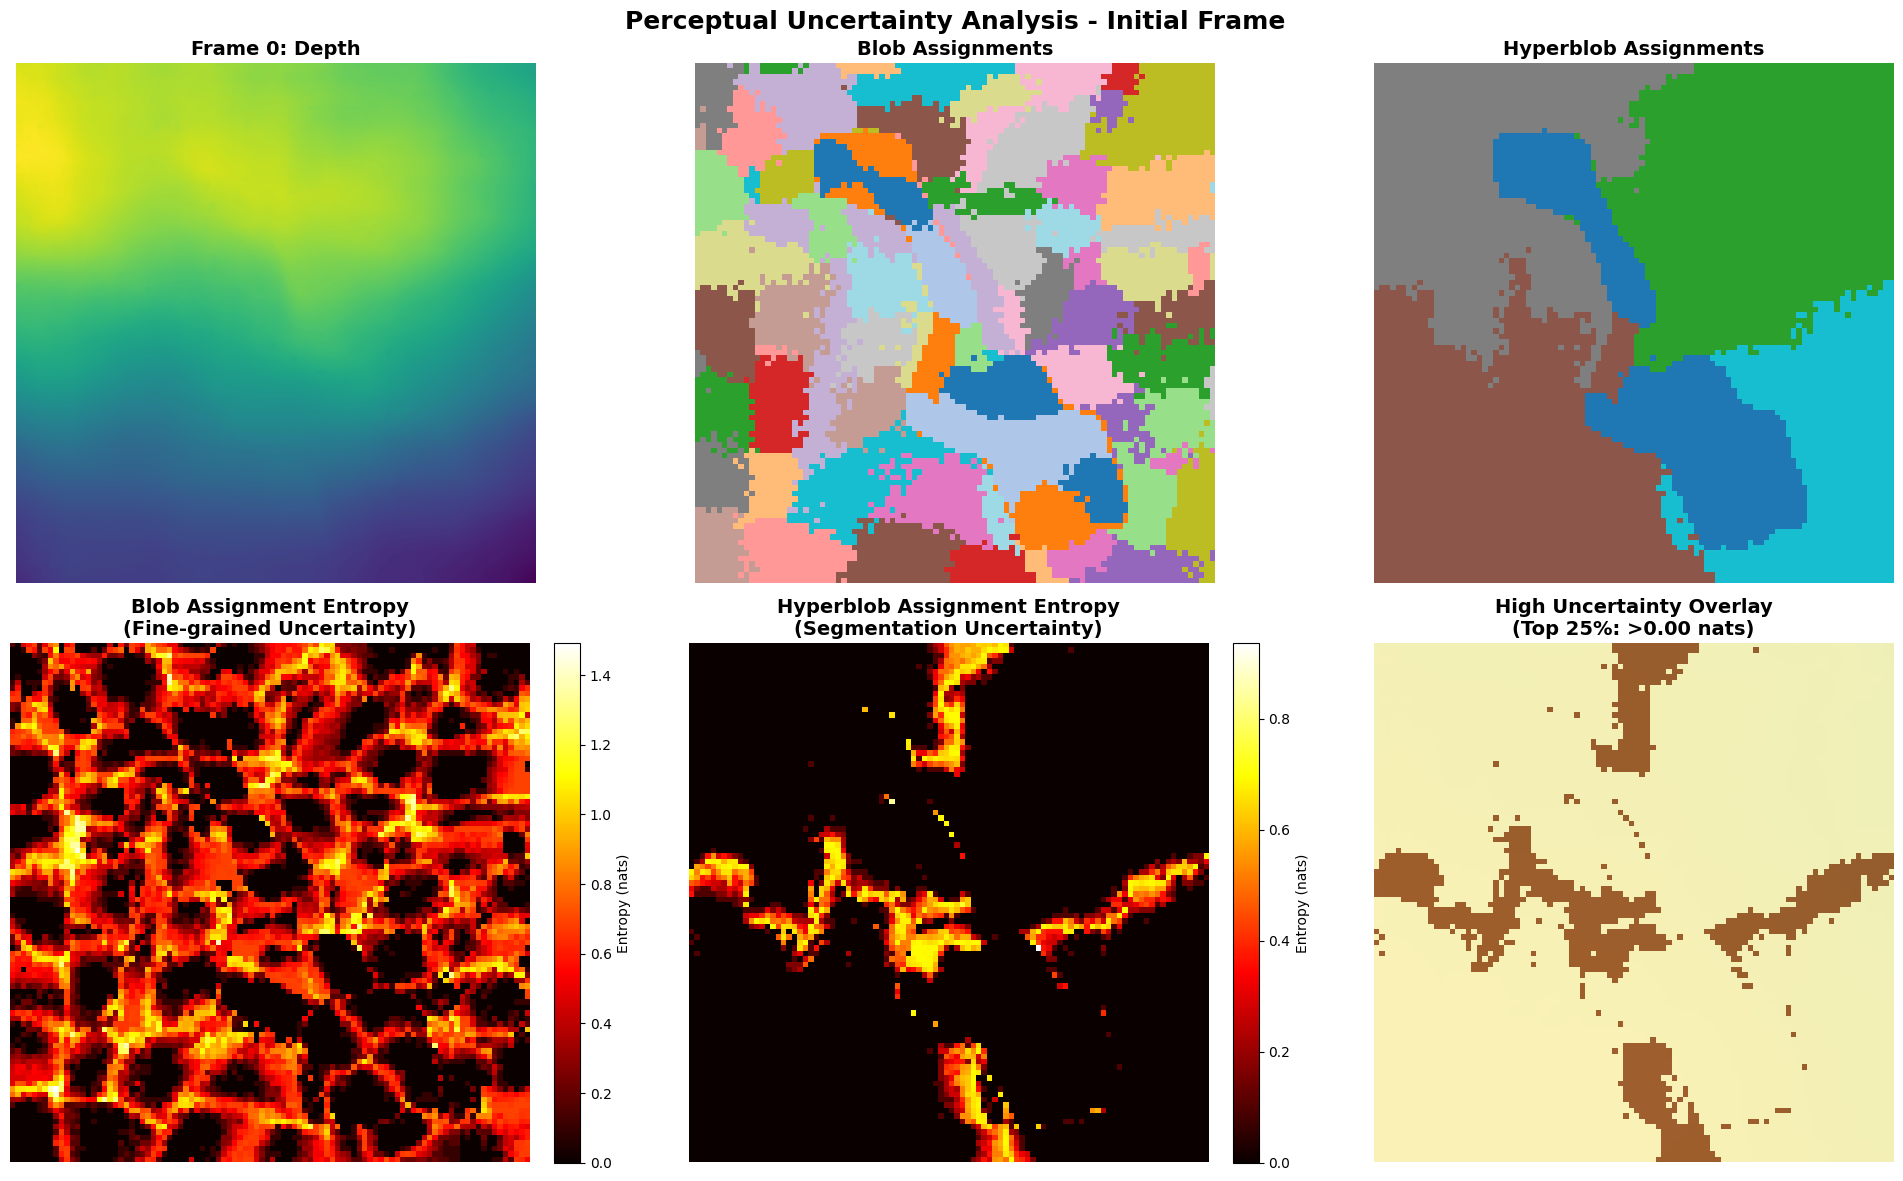


UNCERTAINTY STATISTICS

Blob Assignment Entropy:
  Mean:   0.364 nats
  Median: 0.319 nats
  Max:    1.492 nats
  95th percentile: 0.983 nats

Hyperblob Assignment Entropy:
  Mean:   0.053 nats
  Median: 0.000 nats
  Max:    0.936 nats
  95th percentile: 0.521 nats

High uncertainty pixels (top 25%): 1226 / 9216
Percentage: 13.3%

Interpretation:
  - High entropy = model is uncertain about assignments
  - Typically occurs at object boundaries and textureless regions
  - Hyperblob entropy measures segmentation-level uncertainty
  - Blob entropy measures finer-grained structural uncertainty

✓ Perceptual uncertainty analysis complete!


In [14]:
# ============================================================================
# PERCEPTUAL UNCERTAINTY ANALYSIS - ENTROPY MAPS
# ============================================================================
# Analyze model's perceptual uncertainty by computing entropy from Gibbs samples
# High entropy = ambiguous regions (boundaries, textureless areas)

def compute_blob_entropy_map(blob_assignments, num_blobs, target_hw):
    """
    Compute per-pixel entropy of blob assignments.
    
    Args:
        blob_assignments: (num_samples, num_pixels) array of blob assignments
        num_blobs: Number of blobs
        target_hw: Image size (height/width)
    
    Returns:
        entropy_map: (H, W) array of entropy values
    """
    num_samples, num_pixels = blob_assignments.shape
    
    # Compute empirical probability distribution for each pixel
    entropy_map = np.zeros(num_pixels)
    
    for pixel_idx in range(num_pixels):
        pixel_assignments = blob_assignments[:, pixel_idx]
        
        # Count frequency of each blob assignment
        counts = np.bincount(pixel_assignments, minlength=num_blobs + 1)
        probs = counts / num_samples
        
        # Compute Shannon entropy: H = -sum(p * log(p))
        probs = probs[probs > 0]  # Remove zeros to avoid log(0)
        entropy = -np.sum(probs * np.log(probs)) if len(probs) > 0 else 0.0
        entropy_map[pixel_idx] = entropy
    
    return entropy_map.reshape((target_hw, target_hw))


def compute_hyperblob_entropy_map(blob_assignments, hyperblob_assignments, 
                                   num_blobs, num_hyperblobs, target_hw):
    """
    Compute per-pixel entropy of hyperblob assignments.
    
    Args:
        blob_assignments: (num_samples, num_pixels) array of blob assignments
        hyperblob_assignments: (num_samples, num_blobs) array of hyperblob assignments
        num_blobs: Number of blobs
        num_hyperblobs: Number of hyperblobs
        target_hw: Image size
    
    Returns:
        entropy_map: (H, W) array of hyperblob assignment entropy
    """
    num_samples, num_pixels = blob_assignments.shape
    
    # Map pixels to hyperblobs for each sample
    pixel_hyperblobs = np.zeros((num_samples, num_pixels), dtype=int)
    
    for sample_idx in range(num_samples):
        for pixel_idx in range(num_pixels):
            blob_id = blob_assignments[sample_idx, pixel_idx]
            if blob_id < num_blobs:
                pixel_hyperblobs[sample_idx, pixel_idx] = hyperblob_assignments[sample_idx, blob_id]
            else:
                # Outlier blob
                pixel_hyperblobs[sample_idx, pixel_idx] = -1
    
    # Compute entropy for each pixel
    entropy_map = np.zeros(num_pixels)
    
    for pixel_idx in range(num_pixels):
        pixel_assignments = pixel_hyperblobs[:, pixel_idx]
        
        # Count frequency (+1 to handle -1 outliers)
        counts = np.bincount(pixel_assignments + 1, minlength=num_hyperblobs + 2)
        probs = counts / num_samples
        
        # Compute entropy
        probs = probs[probs > 0]
        entropy = -np.sum(probs * np.log(probs)) if len(probs) > 0 else 0.0
        entropy_map[pixel_idx] = entropy
    
    return entropy_map.reshape((target_hw, target_hw))


# ============================================================================
# COMPUTE ENTROPY MAPS
# ============================================================================

print("\n" + "="*70)
print("PERCEPTUAL UNCERTAINTY ANALYSIS")
print("="*70)

# Use last N samples after burn-in
num_samples_to_use = min(100, len(gibbs_blob_assignments))
burn_in = max(0, len(gibbs_blob_assignments) - num_samples_to_use)

print(f"\nUsing last {num_samples_to_use} samples (after {burn_in} burn-in)...")

# Compute blob-level entropy
blob_entropy_map = compute_blob_entropy_map(
    gibbs_blob_assignments[burn_in:], number_of_blobs, target_hw
)

# Compute hyperblob-level entropy
hyperblob_entropy_map = compute_hyperblob_entropy_map(
    gibbs_blob_assignments[burn_in:], 
    gibbs_hyperblob_assignments[burn_in:],
    number_of_blobs, number_of_hyperblobs, target_hw
)

# ============================================================================
# VISUALIZE UNCERTAINTY
# ============================================================================

fig = plt.figure(figsize=(20, 12))

# Row 1: Original data and assignments
ax1 = plt.subplot(2, 3, 1)
ax1.imshow(depth[0], cmap='viridis')
ax1.set_title('Frame 0: Depth', fontsize=14, fontweight='bold')
ax1.axis('off')

ax2 = plt.subplot(2, 3, 2)
final_blob_assignments = gibbs_blob_assignments[-1]
blob_img = final_blob_assignments.reshape((target_hw, target_hw))
ax2.imshow(blob_img, cmap='tab20')
ax2.set_title('Blob Assignments', fontsize=14, fontweight='bold')
ax2.axis('off')

ax3 = plt.subplot(2, 3, 3)
final_hyperblob_assignments = gibbs_hyperblob_assignments[-1]
final_pixel_hyperblobs = np.array([
    final_hyperblob_assignments[blob_id] if blob_id < number_of_blobs else -1
    for blob_id in final_blob_assignments
])
hyperblob_img = final_pixel_hyperblobs.reshape((target_hw, target_hw))
ax3.imshow(hyperblob_img, cmap='tab10')
ax3.set_title('Hyperblob Assignments', fontsize=14, fontweight='bold')
ax3.axis('off')

# Row 2: Uncertainty maps
ax4 = plt.subplot(2, 3, 4)
im1 = ax4.imshow(blob_entropy_map, cmap='hot', vmin=0)
ax4.set_title('Blob Assignment Entropy\n(Fine-grained Uncertainty)', fontsize=14, fontweight='bold')
ax4.axis('off')
plt.colorbar(im1, ax=ax4, fraction=0.046, pad=0.04, label='Entropy (nats)')

ax5 = plt.subplot(2, 3, 5)
im2 = ax5.imshow(hyperblob_entropy_map, cmap='hot', vmin=0)
ax5.set_title('Hyperblob Assignment Entropy\n(Segmentation Uncertainty)', fontsize=14, fontweight='bold')
ax5.axis('off')
plt.colorbar(im2, ax=ax5, fraction=0.046, pad=0.04, label='Entropy (nats)')

# Overlay high-uncertainty regions on depth
ax6 = plt.subplot(2, 3, 6)
ax6.imshow(depth[0], cmap='viridis', alpha=0.7)
uncertainty_threshold = np.percentile(hyperblob_entropy_map, 75)  # Top 25% uncertainty
high_uncertainty_mask = hyperblob_entropy_map > uncertainty_threshold
ax6.imshow(high_uncertainty_mask, cmap='Reds', alpha=0.6)
ax6.set_title(f'High Uncertainty Overlay\n(Top 25%: >{uncertainty_threshold:.2f} nats)', 
              fontsize=14, fontweight='bold')
ax6.axis('off')

plt.suptitle('Perceptual Uncertainty Analysis - Initial Frame', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# ============================================================================
# STATISTICS
# ============================================================================

print(f"\n{'='*60}")
print("UNCERTAINTY STATISTICS")
print(f"{'='*60}")

print(f"\nBlob Assignment Entropy:")
print(f"  Mean:   {np.mean(blob_entropy_map):.3f} nats")
print(f"  Median: {np.median(blob_entropy_map):.3f} nats")
print(f"  Max:    {np.max(blob_entropy_map):.3f} nats")
print(f"  95th percentile: {np.percentile(blob_entropy_map, 95):.3f} nats")

print(f"\nHyperblob Assignment Entropy:")
print(f"  Mean:   {np.mean(hyperblob_entropy_map):.3f} nats")
print(f"  Median: {np.median(hyperblob_entropy_map):.3f} nats")
print(f"  Max:    {np.max(hyperblob_entropy_map):.3f} nats")
print(f"  95th percentile: {np.percentile(hyperblob_entropy_map, 95):.3f} nats")

print(f"\nHigh uncertainty pixels (top 25%): {np.sum(high_uncertainty_mask)} / {target_hw**2}")
print(f"Percentage: {100 * np.sum(high_uncertainty_mask) / (target_hw**2):.1f}%")

print(f"\n{'='*60}")
print("Interpretation:")
print("  - High entropy = model is uncertain about assignments")
print("  - Typically occurs at object boundaries and textureless regions")
print("  - Hyperblob entropy measures segmentation-level uncertainty")
print("  - Blob entropy measures finer-grained structural uncertainty")
print(f"{'='*60}")

print("\n✓ Perceptual uncertainty analysis complete!")

## Convergence Diagnostics

Computing convergence diagnostics and log probabilities...


E1026 01:18:34.285771   90073 hlo_lexer.cc:443] Failed to parse int literal: 9473407607229978178777909
/var/tmp/ipykernel_90073/3134497736.py:138: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax6.legend()


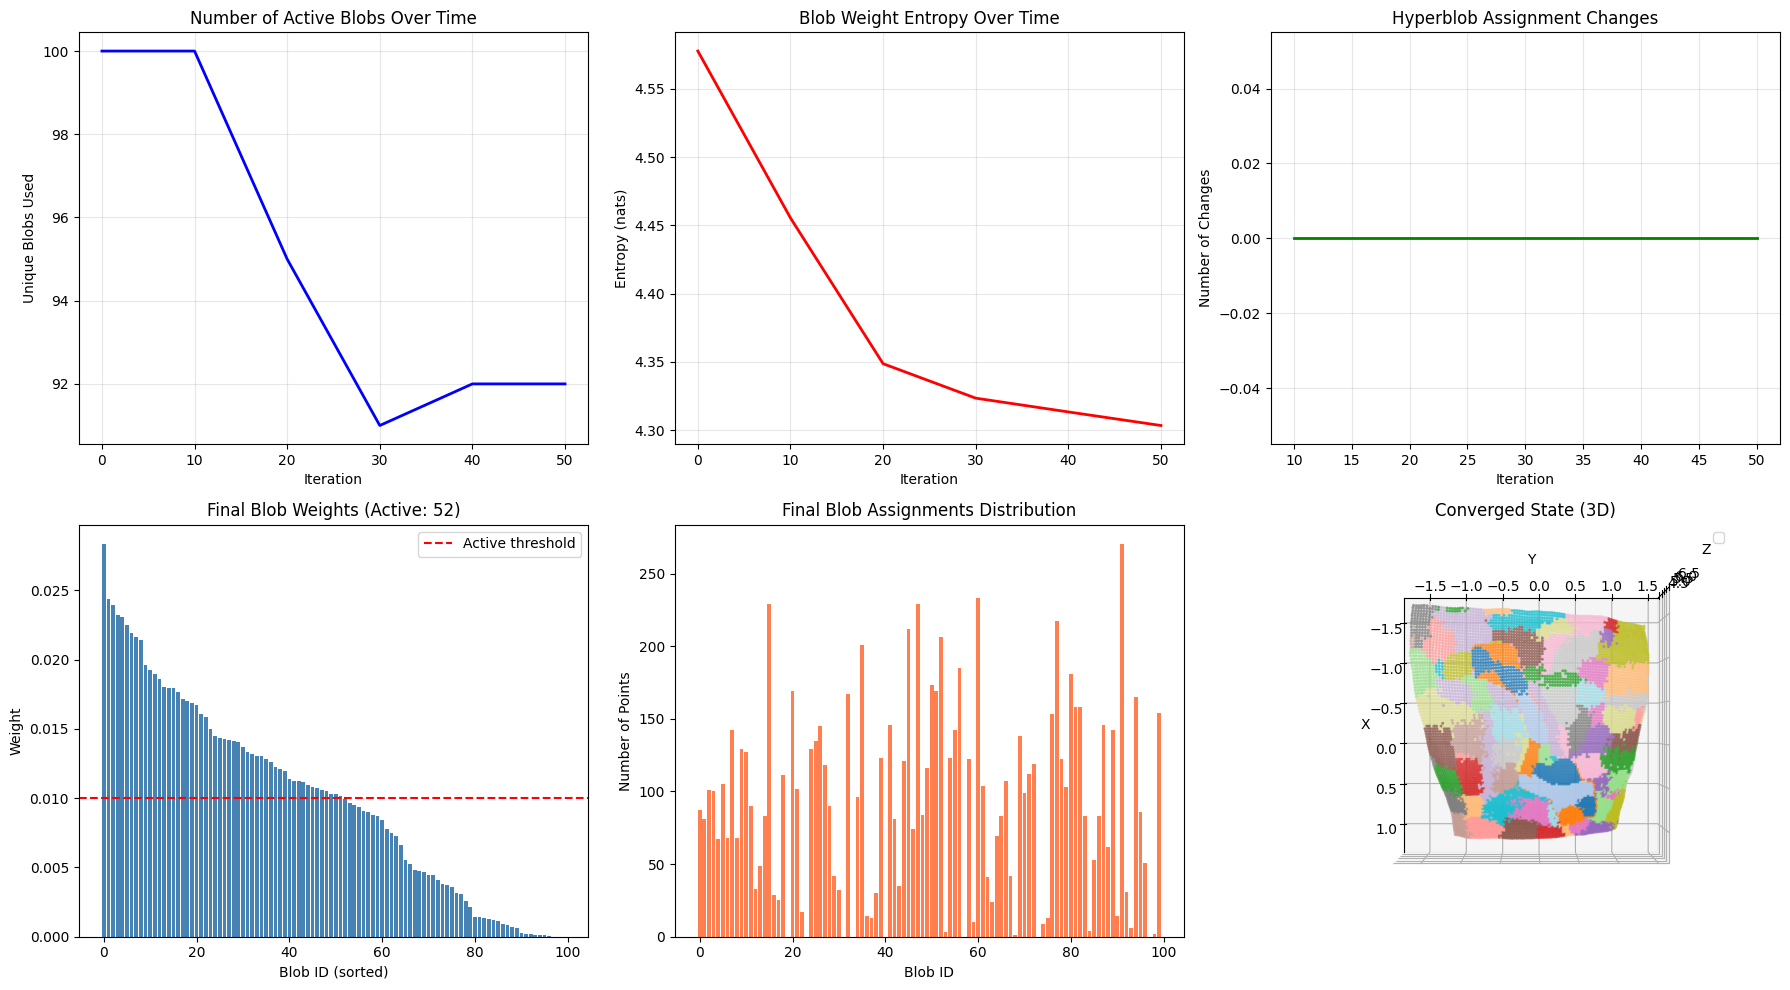


CONVERGENCE SUMMARY
Total iterations: 51
Final unique blobs: 92
Final blob weight entropy: 4.30 nats
Outlier points: 0 / 9216 (0.00%)
Mean points per active blob: 177.2

Log probabilities computed and saved for 6 samples
Max log prob: 127391.41 at iteration 50


In [15]:
# Extract statistics over iterations
n_blobs_history = []
blob_weight_entropy_history = []
hyperblob_assignment_changes = []
log_probs = []  # Store log probabilities

sample_freq = 10  # Sample every 10 iterations for efficiency

from gestalt_experiment_algorithm import HDGMM_model_3d
from genjax import ChoiceMapBuilder as C

print("Computing convergence diagnostics and log probabilities...")

for idx in range(0, len(gibbs_wtrs), sample_freq):
    state = gibbs_wtrs[idx].retval
    blob_assigns = np.array(state.datapoints_state.blob_assignments)
    blob_weights = np.array(state.blobs_state.blob_weights)
    hyperblob_assigns = np.array(state.blobs_state.hyperblob_assignments)
    
    # Track number of unique blobs used
    unique_blobs = len(np.unique(blob_assigns))
    n_blobs_history.append(unique_blobs)
    
    # Track blob weight entropy (higher = more uniform)
    weight_probs = blob_weights / blob_weights.sum()
    entropy = -np.sum(weight_probs * np.log(weight_probs + 1e-10))
    blob_weight_entropy_history.append(entropy)
    
    # Track hyperblob assignment changes
    if idx > 0:
        prev_hyperblob_assigns = np.array(gibbs_wtrs[idx - sample_freq].retval.blobs_state.hyperblob_assignments)
        n_changes = np.sum(hyperblob_assigns != prev_hyperblob_assigns)
        hyperblob_assignment_changes.append(n_changes)
    
    # Compute log probability for this sample
    chm = (
        C['hyperblobs', 'hyperblob_weights'].set(state.hyperblobs_state.hyperblob_weights) |
        C['hyperblobs', 'hyperblob_means'].set(state.hyperblobs_state.hyperblob_means) |
        C['hyperblobs', 'hyperblob_covs'].set(state.hyperblobs_state.hyperblob_covs) |
        C['hyperblobs', 'hyperblob_trans_vels'].set(state.hyperblobs_state.hyperblob_trans_vels) |
        C['hyperblobs', 'hyperblob_rot_vels'].set(state.hyperblobs_state.hyperblob_rot_vels) |
        
        C['blobs', 'hyperblob_assignments'].set(state.blobs_state.hyperblob_assignments) |
        C['blobs', 'blob_weights'].set(state.blobs_state.blob_weights) |
        C['blobs', 'blob_means'].set(state.blobs_state.blob_means) |
        C['blobs', 'blob_covs'].set(state.blobs_state.blob_covs) |
        C['blobs', 'blob_vel_means'].set(state.blobs_state.blob_vel_means) |
        C['blobs', 'blob_vel_covs'].set(state.blobs_state.blob_vel_covs) |
        
        C['datapoints', 'blob_assignments'].set(state.datapoints_state.blob_assignments) |
        C['datapoints', 'datapoint_positions'].set(state.datapoints_state.datapoint_positions) |
        C['datapoints', 'datapoint_vels'].set(state.datapoints_state.datapoint_vels)
    )
    
    weight, tr = HDGMM_model_3d.assess(chm, (state.hypers,))
    log_probs.append(float(weight))
    
    if (idx + 1) % 100 == 0:
        print(f"  Processed {idx+1}/{len(gibbs_wtrs)} samples")

log_probs = np.array(log_probs)

# Create convergence plots
iterations = np.arange(0, len(gibbs_wtrs), sample_freq)

fig = plt.figure(figsize=(18, 10))

# Plot 1: Number of active blobs
ax1 = fig.add_subplot(2, 3, 1)
ax1.plot(iterations, n_blobs_history, linewidth=2, color='blue')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Unique Blobs Used')
ax1.set_title('Number of Active Blobs Over Time')
ax1.grid(True, alpha=0.3)

# Plot 2: Blob weight entropy
ax2 = fig.add_subplot(2, 3, 2)
ax2.plot(iterations, blob_weight_entropy_history, linewidth=2, color='red')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Entropy (nats)')
ax2.set_title('Blob Weight Entropy Over Time')
ax2.grid(True, alpha=0.3)

# Plot 3: Hyperblob assignment changes
ax3 = fig.add_subplot(2, 3, 3)
ax3.plot(iterations[1:], hyperblob_assignment_changes, linewidth=2, color='green')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Number of Changes')
ax3.set_title('Hyperblob Assignment Changes')
ax3.grid(True, alpha=0.3)

# Get final state for remaining plots
converged_state = gibbs_wtrs[-1].retval
final_blob_assignments = np.array(converged_state.datapoints_state.blob_assignments)
final_blob_weights = np.array(converged_state.blobs_state.blob_weights)

# Plot 4: Final blob weights
ax4 = fig.add_subplot(2, 3, 4)
sorted_weights = np.sort(final_blob_weights)[::-1]
ax4.bar(range(len(sorted_weights)), sorted_weights, color='steelblue')
ax4.set_xlabel('Blob ID (sorted)')
ax4.set_ylabel('Weight')
ax4.set_title(f'Final Blob Weights (Active: {np.sum(final_blob_weights > 0.01)})')
ax4.axhline(0.01, color='red', linestyle='--', label='Active threshold')
ax4.legend()

# Plot 5: Final blob assignments distribution
ax5 = fig.add_subplot(2, 3, 5)
unique_assignments, counts = np.unique(final_blob_assignments[final_blob_assignments < number_of_blobs], 
                                       return_counts=True)
ax5.bar(unique_assignments, counts, color='coral')
ax5.set_xlabel('Blob ID')
ax5.set_ylabel('Number of Points')
ax5.set_title(f'Final Blob Assignments Distribution')

# Plot 6: 3D visualization of converged state
ax6 = fig.add_subplot(2, 3, 6, projection='3d')
outlier_mask = final_blob_assignments >= number_of_blobs
inlier_mask = ~outlier_mask

if np.sum(outlier_mask) > 0:
    outlier_pts = tracked_points_frame0[outlier_mask]
    outlier_pts_vis = outlier_pts[:, [1, 0, 2]]  # Transpose for visualization
    ax6.scatter(outlier_pts_vis[:, 0], outlier_pts_vis[:, 1], outlier_pts_vis[:, 2], 
               c='red', s=5, alpha=0.5, label='Outliers')

if np.sum(inlier_mask) > 0:
    inlier_pts = tracked_points_frame0[inlier_mask]
    inlier_pts_vis = inlier_pts[:, [1, 0, 2]]  # Transpose for visualization
    assignments = final_blob_assignments[inlier_mask]
    ax6.scatter(inlier_pts_vis[:, 0], inlier_pts_vis[:, 1], inlier_pts_vis[:, 2], 
               c=assignments, cmap='tab20', s=2, alpha=0.6)

ax6.set_title('Converged State (3D)')
ax6.set_xlabel('X')
ax6.set_ylabel('Y')
ax6.set_zlabel('Z')
ax6.legend()
ax6.view_init(elev=90, azim=0)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*60)
print("CONVERGENCE SUMMARY")
print("="*60)
print(f"Total iterations: {len(gibbs_wtrs)}")
print(f"Final unique blobs: {n_blobs_history[-1]}")
print(f"Final blob weight entropy: {blob_weight_entropy_history[-1]:.2f} nats")
print(f"Outlier points: {np.sum(outlier_mask)} / {len(outlier_mask)} ({100 * np.sum(outlier_mask) / len(outlier_mask):.2f}%)")
active_blobs = np.sum(final_blob_weights > 0.01)
if active_blobs > 0:
    print(f"Mean points per active blob: {np.sum(inlier_mask) / active_blobs:.1f}")
print(f"\nLog probabilities computed and saved for {len(log_probs)} samples")
print(f"Max log prob: {np.max(log_probs):.2f} at iteration {iterations[np.argmax(log_probs)]}")
print("="*60)

## Display Converged State

In [16]:
converged_state

HDGMM_State(
  hypers=HDGMM_Hyperparams(outlier_prob=<jax.Array(0.001, dtype=float32)>, outlier_velocity_gamma_shape=<jax.Array(7.5, dtype=float32)>, outlier_velocity_gamma_rate=<jax.Array(0.5, dtype=float32)>, alpha=<jax.Array(1., dtype=float32)>, beta=<jax.Array(1., dtype=float32)>, mu_H=<jax.Array([-0.01260687, -0.06070298,  5.561611  ], dtype=float32)>, sigma_H=<jax.Array(0.59076697, dtype=float32)>, nu_H=<jax.Array(5., dtype=float32, weak_type=True)>, Psi_H=<jax.Array float32(3, 3) ≈0.022 ±0.13 [≥-0.16, ≤0.24] nonzero:9>, nu_B=<jax.Array(5., dtype=float32, weak_type=True)>, Psi_B=<jax.Array float32(3, 3) ≈0.0011 ±0.0036 [≥-0.0026, ≤0.0079] nonzero:9>, sigma_V=<jax.Array(1.e+15, dtype=float32)>, nu_V=<jax.Array(5., dtype=float32, weak_type=True)>, Psi_V=<jax.Array float32(3, 3) ≈0.00013 ±0.00028 [≥-0.00012, ≤0.00084] nonzero:9>, translation_max_radius=StaticJnp(v=<jax.Array(0.35, dtype=float32, weak_type=True)>), translation_num_radii_cells=StaticJnp(v=<jax.Array(15, dtype=int32, w

In [17]:
from rerun_visualizations import visualize_converged_state

# visualize_converged_state(
#     converged_state=converged_state,
#     tracked_points=tracked_points_frame0,
#     number_of_blobs=number_of_blobs,
#     number_of_hyperblobs=number_of_hyperblobs,
#     scene_name=explore_scene,
#     texture_name=explore_texture
# )

## Simple Blob Assignment Visualization

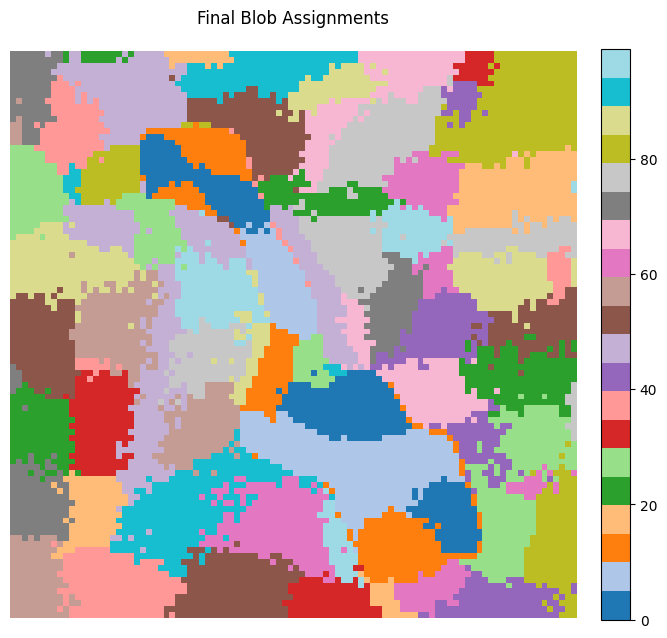

In [18]:
fig, ax = plt.subplots(figsize=(8, 8))
blob_assignments_img = converged_state.datapoints_state.blob_assignments.reshape((target_hw, target_hw))
im = ax.matshow(blob_assignments_img, cmap='tab20')
ax.set_title('Final Blob Assignments', pad=20)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

## Per-Pixel Hyperblob Visualization with Analysis

/var/tmp/ipykernel_90073/3404172346.py:40: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))


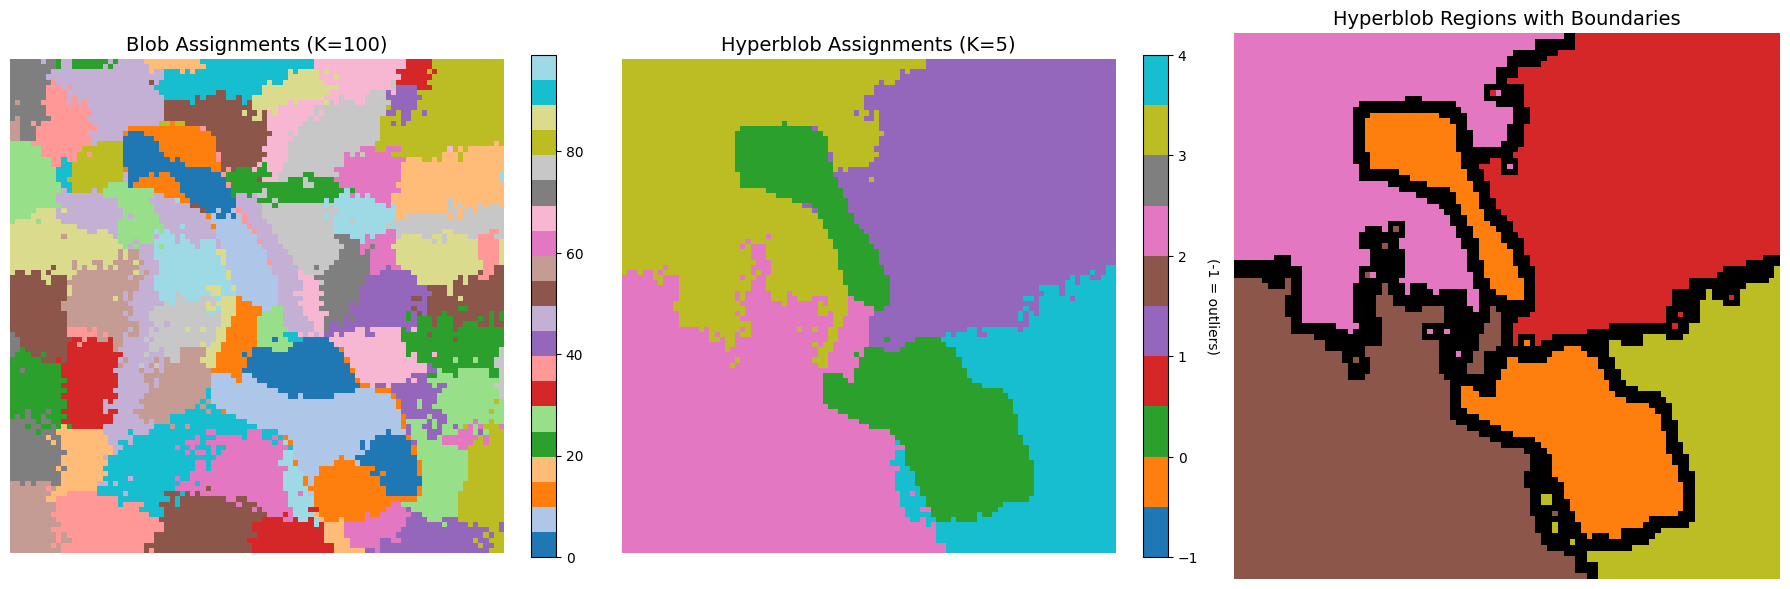


HIERARCHICAL SEGMENTATION STATISTICS

HYPERBLOB ANALYSIS:
----------------------------------------------------------------------
Hyperblob 0:
  - Pixels: 1247 (13.5%)
  - Blobs: 14
  - Points: 1247
  - Spatial extent (X,Y,Z): (1.623, 2.175, 1.823)
Hyperblob 1:
  - Pixels: 2373 (25.7%)
  - Blobs: 29
  - Points: 2373
  - Spatial extent (X,Y,Z): (1.830, 1.744, 0.925)
Hyperblob 2:
  - Pixels: 2436 (26.4%)
  - Blobs: 21
  - Points: 2436
  - Spatial extent (X,Y,Z): (1.815, 1.592, 1.491)
Hyperblob 3:
  - Pixels: 1904 (20.7%)
  - Blobs: 23
  - Points: 1904
  - Spatial extent (X,Y,Z): (1.950, 1.916, 1.193)
Hyperblob 4:
  - Pixels: 1256 (13.6%)
  - Blobs: 13
  - Points: 1256
  - Spatial extent (X,Y,Z): (1.221, 1.346, 1.463)

Outliers: 0 pixels (0.0%)

----------------------------------------------------------------------
BLOB-LEVEL STATISTICS:
----------------------------------------------------------------------
Active blobs: 92 / 100
Blob size - Mean: 100.2, Std: 62.9
Blob size - Min: 1, Max:

In [19]:
# Extract assignments
blob_assignments = np.array(converged_state.datapoints_state.blob_assignments)
blob_to_hyperblob = np.array(converged_state.blobs_state.hyperblob_assignments)

# Map pixels -> blobs -> hyperblobs
pixel_hyperblobs = np.zeros_like(blob_assignments)
for i in range(len(blob_assignments)):
    blob_id = blob_assignments[i]
    if blob_id < number_of_blobs:
        pixel_hyperblobs[i] = blob_to_hyperblob[blob_id]
    else:
        pixel_hyperblobs[i] = -1  # Outliers

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Blob assignments
blob_img = blob_assignments.reshape((target_hw, target_hw))
im1 = axes[0].imshow(blob_img, cmap='tab20')
axes[0].set_title(f'Blob Assignments (K={number_of_blobs})', fontsize=14)
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Plot 2: Hyperblob assignments (via blob mapping)
hyperblob_img = pixel_hyperblobs.reshape((target_hw, target_hw))
im2 = axes[1].imshow(hyperblob_img, cmap='tab10', vmin=-1, vmax=number_of_hyperblobs-1)
axes[1].set_title(f'Hyperblob Assignments (K={number_of_hyperblobs})', fontsize=14)
axes[1].axis('off')
cbar2 = plt.colorbar(im2, ax=axes[1], fraction=0.046)
cbar2.set_label('(-1 = outliers)', rotation=270, labelpad=15)

# Plot 3: Hyperblob regions with boundaries
# Use Sobel edge detection to highlight boundaries
edges_x = sobel(hyperblob_img, axis=0)
edges_y = sobel(hyperblob_img, axis=1)
edges = np.hypot(edges_x, edges_y)
edges = edges > 0.5

# Create colored hyperblob image with black boundaries
hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))
hyperblob_colored[edges] = [0, 0, 0, 1]  # Black boundaries

axes[2].imshow(hyperblob_colored)
axes[2].set_title('Hyperblob Regions with Boundaries', fontsize=14)
axes[2].axis('off')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("HIERARCHICAL SEGMENTATION STATISTICS")
print("="*70)

print("\nHYPERBLOB ANALYSIS:")
print("-" * 70)
for hb_id in range(number_of_hyperblobs):
    # Pixels in this hyperblob
    hb_pixels = np.sum(pixel_hyperblobs == hb_id)
    
    # Blobs assigned to this hyperblob
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    
    # Points assigned to blobs in this hyperblob
    hb_blob_mask = np.isin(blob_assignments, hb_blobs)
    hb_points = np.sum(hb_blob_mask)
    
    print(f"Hyperblob {hb_id}:")
    print(f"  - Pixels: {hb_pixels} ({100*hb_pixels/len(pixel_hyperblobs):.1f}%)")
    print(f"  - Blobs: {len(hb_blobs)}")
    print(f"  - Points: {hb_points}")
    
    if len(hb_blobs) > 0:
        # Compute spatial extent
        hb_positions = tracked_points_frame0[hb_blob_mask]
        if len(hb_positions) > 0:
            extent = np.ptp(hb_positions, axis=0)
            print(f"  - Spatial extent (X,Y,Z): ({extent[0]:.3f}, {extent[1]:.3f}, {extent[2]:.3f})")

# Outlier statistics
outlier_pixels = np.sum(pixel_hyperblobs == -1)
print(f"\nOutliers: {outlier_pixels} pixels ({100*outlier_pixels/len(pixel_hyperblobs):.1f}%)")

# Blob-level statistics
print("\n" + "-" * 70)
print("BLOB-LEVEL STATISTICS:")
print("-" * 70)

active_blobs = np.unique(blob_assignments[blob_assignments < number_of_blobs])
print(f"Active blobs: {len(active_blobs)} / {number_of_blobs}")

blob_sizes = [np.sum(blob_assignments == i) for i in active_blobs]
print(f"Blob size - Mean: {np.mean(blob_sizes):.1f}, Std: {np.std(blob_sizes):.1f}")
print(f"Blob size - Min: {np.min(blob_sizes)}, Max: {np.max(blob_sizes)}")

# Hyperblob weights
hyperblob_weights = np.array(converged_state.hyperblobs_state.hyperblob_weights)
print("\nHyperblob weights:")
for hb_id in range(number_of_hyperblobs):
    print(f"  Hyperblob {hb_id}: {hyperblob_weights[hb_id]:.4f}")

print("="*70)

## 3D Visualization of Final Hierarchical Structure

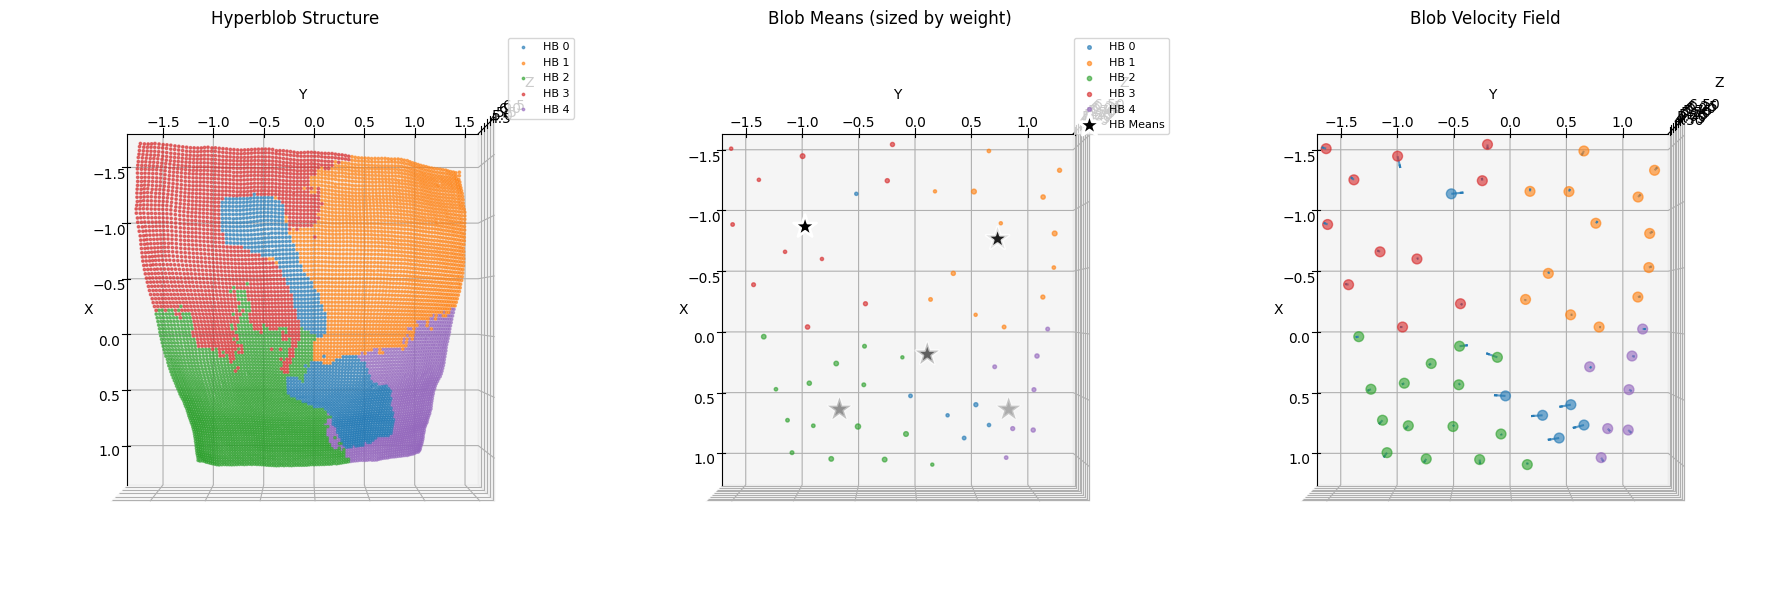

In [20]:
fig = plt.figure(figsize=(18, 6))

# Plot 1: All blobs colored by hyperblob
ax1 = fig.add_subplot(131, projection='3d')
for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    hb_mask = np.isin(blob_assignments, hb_blobs) & (blob_assignments < number_of_blobs)
    if np.sum(hb_mask) > 0:
        pts = tracked_points_frame0[hb_mask]
        pts_vis = pts[:, [1, 0, 2]]  # Transpose for visualization
        ax1.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=3, alpha=0.6, label=f'HB {hb_id}')

outlier_mask = blob_assignments >= number_of_blobs
if np.sum(outlier_mask) > 0:
    outlier_pts = tracked_points_frame0[outlier_mask]
    outlier_pts_vis = outlier_pts[:, [1, 0, 2]]  # Transpose for visualization
    ax1.scatter(outlier_pts_vis[:, 0], outlier_pts_vis[:, 1], outlier_pts_vis[:, 2],
               c='gray', s=1, alpha=0.2, label='Outliers')

ax1.set_title('Hyperblob Structure', fontsize=12)
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.set_zlabel('Z')
ax1.legend(loc='upper right', fontsize=8)
ax1.view_init(elev=90, azim=0)

# Plot 2: Blob means colored by hyperblob
ax2 = fig.add_subplot(132, projection='3d')
blob_means = np.array(converged_state.blobs_state.blob_means)
blob_weights = np.array(converged_state.blobs_state.blob_weights)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    active_hb_blobs = hb_blobs[blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]  # Transpose for visualization
        weights = blob_weights[active_hb_blobs]
        ax2.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2],
                   s=weights*500, alpha=0.6, label=f'HB {hb_id}')

# Add hyperblob means
hyperblob_means = np.array(converged_state.hyperblobs_state.hyperblob_means)
hyperblob_means_vis = hyperblob_means[:, [1, 0, 2]]  # Transpose for visualization
ax2.scatter(hyperblob_means_vis[:, 0], hyperblob_means_vis[:, 1], hyperblob_means_vis[:, 2],
           c='black', marker='*', s=300, edgecolors='white', linewidths=2,
           label='HB Means', zorder=10)

ax2.set_title('Blob Means (sized by weight)', fontsize=12)
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.set_zlabel('Z')
ax2.legend(loc='upper right', fontsize=8)
ax2.view_init(elev=90, azim=0)

# Plot 3: Velocity field
ax3 = fig.add_subplot(133, projection='3d')
blob_vel_means = np.array(converged_state.blobs_state.blob_vel_means)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(blob_to_hyperblob == hb_id)[0]
    active_hb_blobs = hb_blobs[blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]  # Transpose for visualization
        vels = blob_vel_means[active_hb_blobs]
        vels_vis = vels[:, [1, 0, 2]]  # Transpose for visualization

        # Plot points
        ax3.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2], s=50, alpha=0.6)

        # Plot velocity vectors
        for i in range(len(means_vis)):
            ax3.quiver(means_vis[i, 0], means_vis[i, 1], means_vis[i, 2],
                      vels_vis[i, 0], vels_vis[i, 1], vels_vis[i, 2],
                      length=0.1, normalize=True, alpha=0.7)

ax3.set_title('Blob Velocity Field', fontsize=12)
ax3.set_xlabel('X')
ax3.set_ylabel('Y')
ax3.set_zlabel('Z')
ax3.view_init(elev=90, azim=0)

plt.tight_layout()
plt.show()

## Max Scoring Trace Visualization

MAXIMUM SCORING TRACE
Maximum log probability: 127391.4141
Found at iteration: 50 (sample 5)
Final iteration log prob: 127391.4141

Rebuilding choice map for max scoring trace...
Verified log probability: 127391.4141
Trace successfully rebuilt!



/var/tmp/ipykernel_90073/710270924.py:191: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))


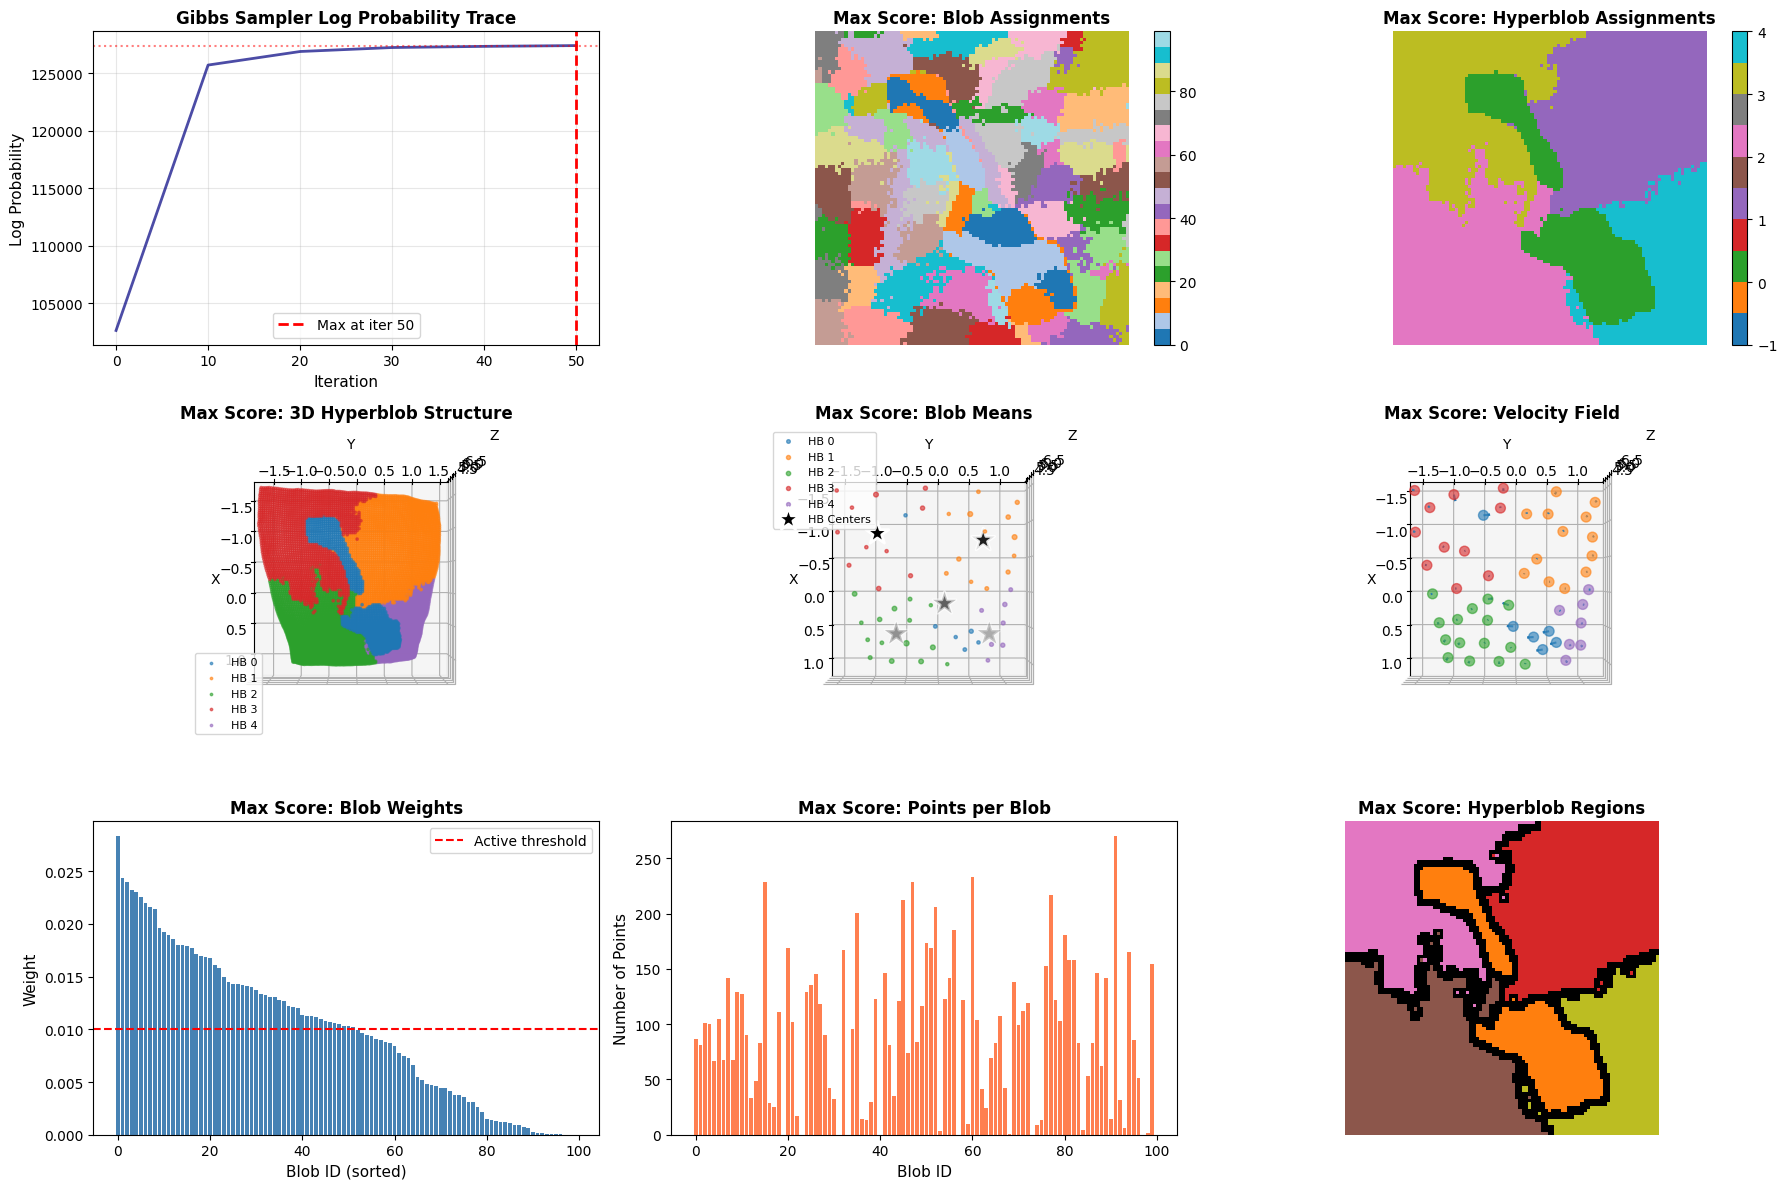


MAX SCORING TRACE STATISTICS
Log probability: 127391.4141
Iteration: 50 / 51

Outliers: 0 / 9216 (0.00%)
Active blobs: 52 / 100
Mean points per active blob: 177.2

Hyperblob distribution:
  Hyperblob 0: 1247 pixels (13.5%), 14 blobs
  Hyperblob 1: 2373 pixels (25.7%), 29 blobs
  Hyperblob 2: 2436 pixels (26.4%), 21 blobs
  Hyperblob 3: 1904 pixels (20.7%), 23 blobs
  Hyperblob 4: 1256 pixels (13.6%), 13 blobs

Hyperblob weights:
  Hyperblob 0: 0.1454
  Hyperblob 1: 0.2708
  Hyperblob 2: 0.2470
  Hyperblob 3: 0.1963
  Hyperblob 4: 0.1405

Max scoring trace is now available as 'max_score_trace' for further processing
Max scoring state is available as 'max_score_state'
Max scoring choice map is available as 'max_chm'


In [21]:
# Find the max scoring trace and rebuild it
from gestalt_experiment_algorithm import HDGMM_model_3d
from genjax import ChoiceMapBuilder as C

# Find max scoring sample
max_score_idx_in_sampled = np.argmax(log_probs)
max_score_idx = max_score_idx_in_sampled * sample_freq  # Convert to actual iteration index
max_score_state = gibbs_wtrs[max_score_idx].retval

print("="*70)
print("MAXIMUM SCORING TRACE")
print("="*70)
print(f"Maximum log probability: {log_probs[max_score_idx_in_sampled]:.4f}")
print(f"Found at iteration: {max_score_idx} (sample {max_score_idx_in_sampled})")
print(f"Final iteration log prob: {log_probs[-1]:.4f}")
print("="*70)

# Rebuild the choice map for the max scoring trace
print("\nRebuilding choice map for max scoring trace...")
max_chm = (
    C['hyperblobs', 'hyperblob_weights'].set(max_score_state.hyperblobs_state.hyperblob_weights) |
    C['hyperblobs', 'hyperblob_means'].set(max_score_state.hyperblobs_state.hyperblob_means) |
    C['hyperblobs', 'hyperblob_covs'].set(max_score_state.hyperblobs_state.hyperblob_covs) |
    C['hyperblobs', 'hyperblob_trans_vels'].set(max_score_state.hyperblobs_state.hyperblob_trans_vels) |
    C['hyperblobs', 'hyperblob_rot_vels'].set(max_score_state.hyperblobs_state.hyperblob_rot_vels) |
    
    C['blobs', 'hyperblob_assignments'].set(max_score_state.blobs_state.hyperblob_assignments) |
    C['blobs', 'blob_weights'].set(max_score_state.blobs_state.blob_weights) |
    C['blobs', 'blob_means'].set(max_score_state.blobs_state.blob_means) |
    C['blobs', 'blob_covs'].set(max_score_state.blobs_state.blob_covs) |
    C['blobs', 'blob_vel_means'].set(max_score_state.blobs_state.blob_vel_means) |
    C['blobs', 'blob_vel_covs'].set(max_score_state.blobs_state.blob_vel_covs) |
    
    C['datapoints', 'blob_assignments'].set(max_score_state.datapoints_state.blob_assignments) |
    C['datapoints', 'datapoint_positions'].set(max_score_state.datapoints_state.datapoint_positions) |
    C['datapoints', 'datapoint_vels'].set(max_score_state.datapoints_state.datapoint_vels)
)

# Assess to verify the score
verified_weight, max_score_trace = HDGMM_model_3d.assess(max_chm, (max_score_state.hypers,))
print(f"Verified log probability: {float(verified_weight):.4f}")
print("Trace successfully rebuilt!\n")

# Extract assignments for visualization
max_blob_assignments = np.array(max_score_state.datapoints_state.blob_assignments)
max_blob_weights = np.array(max_score_state.blobs_state.blob_weights)
max_hyperblob_assignments = np.array(max_score_state.blobs_state.hyperblob_assignments)

# Map pixels to hyperblobs
max_pixel_hyperblobs = np.zeros_like(max_blob_assignments)
for i in range(len(max_blob_assignments)):
    blob_id = max_blob_assignments[i]
    if blob_id < number_of_blobs:
        max_pixel_hyperblobs[i] = max_hyperblob_assignments[blob_id]
    else:
        max_pixel_hyperblobs[i] = -1

# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))

# Log probability trace
ax1 = fig.add_subplot(3, 3, 1)
ax1.plot(iterations, log_probs, linewidth=2, color='navy', alpha=0.7)
ax1.axvline(max_score_idx, color='red', linestyle='--', linewidth=2, label=f'Max at iter {max_score_idx}')
ax1.axhline(log_probs[max_score_idx_in_sampled], color='red', linestyle=':', alpha=0.5)
ax1.set_xlabel('Iteration', fontsize=11)
ax1.set_ylabel('Log Probability', fontsize=11)
ax1.set_title('Gibbs Sampler Log Probability Trace', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Blob assignments
ax2 = fig.add_subplot(3, 3, 2)
blob_img = max_blob_assignments.reshape((target_hw, target_hw))
im2 = ax2.imshow(blob_img, cmap='tab20')
ax2.set_title(f'Max Score: Blob Assignments', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im2, ax=ax2, fraction=0.046)

# Hyperblob assignments
ax3 = fig.add_subplot(3, 3, 3)
hyperblob_img = max_pixel_hyperblobs.reshape((target_hw, target_hw))
im3 = ax3.imshow(hyperblob_img, cmap='tab10', vmin=-1, vmax=number_of_hyperblobs-1)
ax3.set_title(f'Max Score: Hyperblob Assignments', fontsize=12, fontweight='bold')
ax3.axis('off')
plt.colorbar(im3, ax=ax3, fraction=0.046)

# 3D scatter: All points colored by hyperblob
ax4 = fig.add_subplot(3, 3, 4, projection='3d')
for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(max_hyperblob_assignments == hb_id)[0]
    hb_mask = np.isin(max_blob_assignments, hb_blobs) & (max_blob_assignments < number_of_blobs)
    if np.sum(hb_mask) > 0:
        pts = tracked_points_frame0[hb_mask]
        pts_vis = pts[:, [1, 0, 2]]
        ax4.scatter(pts_vis[:, 0], pts_vis[:, 1], pts_vis[:, 2], s=3, alpha=0.6, label=f'HB {hb_id}')

outlier_mask = max_blob_assignments >= number_of_blobs
if np.sum(outlier_mask) > 0:
    outlier_pts = tracked_points_frame0[outlier_mask]
    outlier_pts_vis = outlier_pts[:, [1, 0, 2]]
    ax4.scatter(outlier_pts_vis[:, 0], outlier_pts_vis[:, 1], outlier_pts_vis[:, 2],
               c='gray', s=1, alpha=0.2, label='Outliers')

ax4.set_title('Max Score: 3D Hyperblob Structure', fontsize=12, fontweight='bold')
ax4.set_xlabel('X')
ax4.set_ylabel('Y')
ax4.set_zlabel('Z')
ax4.legend(fontsize=8)
ax4.view_init(elev=90, azim=0)

# Blob means sized by weight
ax5 = fig.add_subplot(3, 3, 5, projection='3d')
max_blob_means = np.array(max_score_state.blobs_state.blob_means)
max_hyperblob_means = np.array(max_score_state.hyperblobs_state.hyperblob_means)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(max_hyperblob_assignments == hb_id)[0]
    active_hb_blobs = hb_blobs[max_blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = max_blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]
        weights = max_blob_weights[active_hb_blobs]
        ax5.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2],
                   s=weights*500, alpha=0.6, label=f'HB {hb_id}')

# Add hyperblob means
hyperblob_means_vis = max_hyperblob_means[:, [1, 0, 2]]
ax5.scatter(hyperblob_means_vis[:, 0], hyperblob_means_vis[:, 1], hyperblob_means_vis[:, 2],
           c='black', marker='*', s=300, edgecolors='white', linewidths=2,
           label='HB Centers', zorder=10)

ax5.set_title('Max Score: Blob Means', fontsize=12, fontweight='bold')
ax5.set_xlabel('X')
ax5.set_ylabel('Y')
ax5.set_zlabel('Z')
ax5.legend(fontsize=8)
ax5.view_init(elev=90, azim=0)

# Velocity field
ax6 = fig.add_subplot(3, 3, 6, projection='3d')
max_blob_vel_means = np.array(max_score_state.blobs_state.blob_vel_means)

for hb_id in range(number_of_hyperblobs):
    hb_blobs = np.where(max_hyperblob_assignments == hb_id)[0]
    active_hb_blobs = hb_blobs[max_blob_weights[hb_blobs] > 0.01]
    if len(active_hb_blobs) > 0:
        means = max_blob_means[active_hb_blobs]
        means_vis = means[:, [1, 0, 2]]
        vels = max_blob_vel_means[active_hb_blobs]
        vels_vis = vels[:, [1, 0, 2]]
        
        ax6.scatter(means_vis[:, 0], means_vis[:, 1], means_vis[:, 2], s=50, alpha=0.6)
        
        for i in range(len(means_vis)):
            ax6.quiver(means_vis[i, 0], means_vis[i, 1], means_vis[i, 2],
                      vels_vis[i, 0], vels_vis[i, 1], vels_vis[i, 2],
                      length=0.1, normalize=True, alpha=0.7)

ax6.set_title('Max Score: Velocity Field', fontsize=12, fontweight='bold')
ax6.set_xlabel('X')
ax6.set_ylabel('Y')
ax6.set_zlabel('Z')
ax6.view_init(elev=90, azim=0)

# Blob weight distribution
ax7 = fig.add_subplot(3, 3, 7)
sorted_weights = np.sort(max_blob_weights)[::-1]
ax7.bar(range(len(sorted_weights)), sorted_weights, color='steelblue')
ax7.set_xlabel('Blob ID (sorted)', fontsize=11)
ax7.set_ylabel('Weight', fontsize=11)
ax7.set_title(f'Max Score: Blob Weights', fontsize=12, fontweight='bold')
ax7.axhline(0.01, color='red', linestyle='--', label='Active threshold')
ax7.legend()

# Blob assignments distribution
ax8 = fig.add_subplot(3, 3, 8)
unique_assignments, counts = np.unique(max_blob_assignments[max_blob_assignments < number_of_blobs], 
                                       return_counts=True)
ax8.bar(unique_assignments, counts, color='coral')
ax8.set_xlabel('Blob ID', fontsize=11)
ax8.set_ylabel('Number of Points', fontsize=11)
ax8.set_title('Max Score: Points per Blob', fontsize=12, fontweight='bold')

# Hyperblob with boundaries
ax9 = fig.add_subplot(3, 3, 9)
edges_x = sobel(hyperblob_img, axis=0)
edges_y = sobel(hyperblob_img, axis=1)
edges = np.hypot(edges_x, edges_y) > 0.5

hyperblob_colored = cm.get_cmap('tab10')((hyperblob_img + 1) / (number_of_hyperblobs + 1))
hyperblob_colored[edges] = [0, 0, 0, 1]

ax9.imshow(hyperblob_colored)
ax9.set_title('Max Score: Hyperblob Regions', fontsize=12, fontweight='bold')
ax9.axis('off')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n" + "="*70)
print("MAX SCORING TRACE STATISTICS")
print("="*70)
print(f"Log probability: {log_probs[max_score_idx_in_sampled]:.4f}")
print(f"Iteration: {max_score_idx} / {len(gibbs_wtrs)}")

outlier_count = np.sum(max_blob_assignments >= number_of_blobs)
print(f"\nOutliers: {outlier_count} / {len(max_blob_assignments)} ({100*outlier_count/len(max_blob_assignments):.2f}%)")

active_blobs = np.sum(max_blob_weights > 0.01)
print(f"Active blobs: {active_blobs} / {number_of_blobs}")

if active_blobs > 0:
    inlier_count = np.sum(max_blob_assignments < number_of_blobs)
    print(f"Mean points per active blob: {inlier_count / active_blobs:.1f}")

print("\nHyperblob distribution:")
for hb_id in range(number_of_hyperblobs):
    hb_pixels = np.sum(max_pixel_hyperblobs == hb_id)
    hb_blobs = np.sum(max_hyperblob_assignments == hb_id)
    print(f"  Hyperblob {hb_id}: {hb_pixels} pixels ({100*hb_pixels/len(max_pixel_hyperblobs):.1f}%), {hb_blobs} blobs")

max_hyperblob_weights = np.array(max_score_state.hyperblobs_state.hyperblob_weights)
print("\nHyperblob weights:")
for hb_id in range(number_of_hyperblobs):
    print(f"  Hyperblob {hb_id}: {max_hyperblob_weights[hb_id]:.4f}")

print("="*70)
print("\nMax scoring trace is now available as 'max_score_trace' for further processing")
print("Max scoring state is available as 'max_score_state'")
print("Max scoring choice map is available as 'max_chm'")

Probe point sampled from ROI: (65, 78)


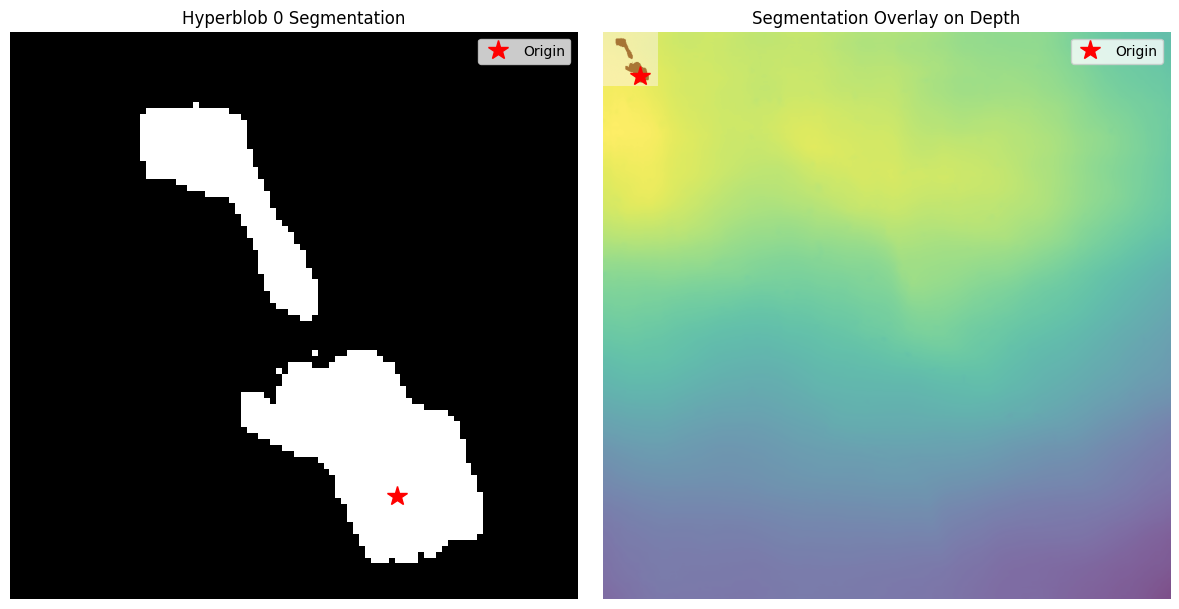

Saved segmentation to: one_frame_gestalt_masks/scene_00001_texture_22_origin_hyperblob_segmentation.png
Origin pixel (65, 78) belongs to Hyperblob 0
Segmentation contains 1247 pixels (13.5%)


In [22]:
# Save segmentation for hyperblobs at origin pixel as PNG
from PIL import Image
import os

# Create output directory
os.makedirs('one_frame_gestalt_masks', exist_ok=True)

# Robustly sample probe point from ROI mask instead of using center
roi_mask_indices = np.where(combined_mask)[0]
if len(roi_mask_indices) > 0:
    # Randomly sample a point from the ROI
    probe_pixel_idx = np.random.choice(roi_mask_indices)
    origin_pixel_idx = probe_pixel_idx
    origin_y, origin_x = probe_pixel_idx // target_hw, probe_pixel_idx % target_hw
    print(f"Probe point sampled from ROI: ({origin_x}, {origin_y})")
else:
    # Fallback to center if no ROI found
    origin_x, origin_y = target_hw // 2, target_hw // 2
    origin_pixel_idx = origin_y * target_hw + origin_x
    print(f"Warning: No ROI found, using center: ({origin_x}, {origin_y})")

# Find which blob the origin belongs to
origin_blob = max_blob_assignments[origin_pixel_idx]

if origin_blob < number_of_blobs:
    # Find which hyperblob this blob belongs to
    origin_hyperblob = max_hyperblob_assignments[origin_blob]
    
    # Get all pixels belonging to this hyperblob
    origin_hyperblob_mask = max_pixel_hyperblobs == origin_hyperblob
    
    # Create binary mask image (white = mask, black = background)
    mask_img = (origin_hyperblob_mask.reshape((target_hw, target_hw)) * 255).astype(np.uint8)
    
    # Save as PNG
    output_path = f'one_frame_gestalt_masks/{explore_scene}_{explore_texture}_origin_hyperblob_segmentation.png'
    Image.fromarray(mask_img).save(output_path)
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    axes[0].imshow(mask_img, cmap='gray')
    axes[0].plot(origin_x, origin_y, 'r*', markersize=15, label='Origin')
    axes[0].set_title(f'Hyperblob {origin_hyperblob} Segmentation')
    axes[0].legend()
    axes[0].axis('off')
    
    axes[1].imshow(depth[0], cmap='viridis', alpha=0.7)
    axes[1].imshow(mask_img, cmap='Reds', alpha=0.5)
    axes[1].plot(origin_x, origin_y, 'r*', markersize=15, label='Origin')
    axes[1].set_title('Segmentation Overlay on Depth')
    axes[1].legend()
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Saved segmentation to: {output_path}")
    print(f"Origin pixel ({origin_x}, {origin_y}) belongs to Hyperblob {origin_hyperblob}")
    print(f"Segmentation contains {np.sum(origin_hyperblob_mask)} pixels ({100*np.sum(origin_hyperblob_mask)/len(origin_hyperblob_mask):.1f}%)")
else:
    print(f"Origin pixel is an outlier (blob_id={origin_blob})")

In [23]:
# # ============================================================================
# # PERCEPTUAL UNCERTAINTY ANALYSIS - INITIAL FRAME ONLY
# # ============================================================================
# # Analyze uncertainty from the Gibbs samples of the initial frame

# def compute_assignment_entropy_map(gibbs_samples, num_blobs, target_hw):
#     """Compute per-pixel entropy of blob assignments from Gibbs samples."""
#     # Collect blob assignments from all samples
#     all_assignments = []
#     for state in gibbs_samples:
#         blob_assignments = np.array(state.retval.datapoints_state.blob_assignments)
#         all_assignments.append(blob_assignments)
    
#     all_assignments = np.array(all_assignments)  # (num_samples, num_pixels)
    
#     # Compute empirical probability distribution for each pixel
#     entropy_map = []
#     for pixel_idx in range(all_assignments.shape[1]):
#         pixel_assignments = all_assignments[:, pixel_idx]
        
#         # Count frequency of each blob assignment
#         counts = np.bincount(pixel_assignments, minlength=num_blobs + 1)
#         probs = counts / len(pixel_assignments)
        
#         # Compute Shannon entropy: H = -sum(p * log(p))
#         probs = probs[probs > 0]  # Remove zeros to avoid log(0)
#         entropy = -np.sum(probs * np.log(probs))
#         entropy_map.append(entropy)
    
#     entropy_map = np.array(entropy_map).reshape((target_hw, target_hw))
#     return entropy_map


# def compute_hyperblob_entropy_map(gibbs_samples, num_blobs, num_hyperblobs, target_hw):
#     """Compute per-pixel entropy of hyperblob assignments."""
#     # Collect hyperblob assignments for each pixel
#     all_pixel_hyperblobs = []
    
#     for state in gibbs_samples:
#         blob_assignments = np.array(state.retval.datapoints_state.blob_assignments)
#         hyperblob_assignments = np.array(state.retval.blobs_state.hyperblob_assignments)
        
#         # Map pixels to hyperblobs
#         pixel_hyperblobs = np.array([
#             hyperblob_assignments[blob_id] if blob_id < len(hyperblob_assignments) else -1
#             for blob_id in blob_assignments
#         ])
#         all_pixel_hyperblobs.append(pixel_hyperblobs)
    
#     all_pixel_hyperblobs = np.array(all_pixel_hyperblobs)  # (num_samples, num_pixels)
    
#     # Compute entropy for each pixel
#     entropy_map = []
#     for pixel_idx in range(all_pixel_hyperblobs.shape[1]):
#         pixel_assignments = all_pixel_hyperblobs[:, pixel_idx]
        
#         # Count frequency (+1 to handle -1 outliers)
#         counts = np.bincount(pixel_assignments + 1, minlength=num_hyperblobs + 2)
#         probs = counts / len(pixel_assignments)
        
#         # Compute entropy
#         probs = probs[probs > 0]
#         entropy = -np.sum(probs * np.log(probs)) if len(probs) > 0 else 0.0
#         entropy_map.append(entropy)
    
#     entropy_map = np.array(entropy_map).reshape((target_hw, target_hw))
#     return entropy_map


# # ============================================================================
# # COMPUTE ENTROPY MAPS FROM INITIAL FRAME GIBBS SAMPLES
# # ============================================================================

# print("\n" + "="*70)
# print("PERCEPTUAL UNCERTAINTY ANALYSIS - INITIAL FRAME")
# print("="*70)

# # Use last 25 samples from Gibbs chain (after convergence)
# num_samples_to_use = min(25, len(gibbs_wtrs))
# samples_for_entropy = gibbs_wtrs[-num_samples_to_use:]

# print(f"\nComputing entropy from last {num_samples_to_use} Gibbs samples...")

# # Compute blob-level entropy
# blob_entropy_map = compute_assignment_entropy_map(
#     samples_for_entropy, number_of_blobs, target_hw
# )

# # Compute hyperblob-level entropy  
# hyperblob_entropy_map = compute_hyperblob_entropy_map(
#     samples_for_entropy, number_of_blobs, number_of_hyperblobs, target_hw
# )

# # ============================================================================
# # VISUALIZE UNCERTAINTY
# # ============================================================================

# fig = plt.figure(figsize=(20, 12))

# # Row 1: Original data and assignments
# ax1 = plt.subplot(2, 3, 1)
# ax1.imshow(depth[0], cmap='viridis')
# ax1.set_title('Frame 0: Depth', fontsize=14, fontweight='bold')
# ax1.axis('off')

# ax2 = plt.subplot(2, 3, 2)
# blob_img = max_blob_assignments.reshape((target_hw, target_hw))
# ax2.imshow(blob_img, cmap='tab20')
# ax2.set_title('Blob Assignments', fontsize=14, fontweight='bold')
# ax2.axis('off')

# ax3 = plt.subplot(2, 3, 3)
# hyperblob_img = max_pixel_hyperblobs.reshape((target_hw, target_hw))
# ax3.imshow(hyperblob_img, cmap='tab10')
# ax3.set_title('Hyperblob Assignments', fontsize=14, fontweight='bold')
# ax3.axis('off')

# # Row 2: Uncertainty maps
# ax4 = plt.subplot(2, 3, 4)
# im1 = ax4.imshow(blob_entropy_map, cmap='hot', vmin=0)
# ax4.set_title('Blob Assignment Entropy\n(Fine-grained Uncertainty)', fontsize=14, fontweight='bold')
# ax4.axis('off')
# plt.colorbar(im1, ax=ax4, fraction=0.046, pad=0.04, label='Entropy (nats)')

# ax5 = plt.subplot(2, 3, 5)
# im2 = ax5.imshow(hyperblob_entropy_map, cmap='hot', vmin=0)
# ax5.set_title('Hyperblob Assignment Entropy\n(Segmentation Uncertainty)', fontsize=14, fontweight='bold')
# ax5.axis('off')
# plt.colorbar(im2, ax=ax5, fraction=0.046, pad=0.04, label='Entropy (nats)')

# # Overlay high-uncertainty regions on depth
# ax6 = plt.subplot(2, 3, 6)
# ax6.imshow(depth[0], cmap='viridis', alpha=0.7)
# uncertainty_threshold = np.percentile(hyperblob_entropy_map, 75)  # Top 25% uncertainty
# high_uncertainty_mask = hyperblob_entropy_map > uncertainty_threshold
# ax6.imshow(high_uncertainty_mask, cmap='Reds', alpha=0.6)
# ax6.set_title(f'High Uncertainty Overlay\n(Top 25%: >{uncertainty_threshold:.2f} nats)', 
#               fontsize=14, fontweight='bold')
# ax6.axis('off')

# plt.suptitle('Perceptual Uncertainty Analysis - Initial Frame', fontsize=18, fontweight='bold', y=0.98)
# plt.tight_layout()
# plt.show()

# # ============================================================================
# # STATISTICS
# # ============================================================================

# print(f"\n{'='*60}")
# print("UNCERTAINTY STATISTICS")
# print(f"{'='*60}")

# print(f"\nBlob Assignment Entropy:")
# print(f"  Mean:   {np.mean(blob_entropy_map):.3f} nats")
# print(f"  Median: {np.median(blob_entropy_map):.3f} nats")
# print(f"  Max:    {np.max(blob_entropy_map):.3f} nats")
# print(f"  95th percentile: {np.percentile(blob_entropy_map, 95):.3f} nats")

# print(f"\nHyperblob Assignment Entropy:")
# print(f"  Mean:   {np.mean(hyperblob_entropy_map):.3f} nats")
# print(f"  Median: {np.median(hyperblob_entropy_map):.3f} nats")
# print(f"  Max:    {np.max(hyperblob_entropy_map):.3f} nats")
# print(f"  95th percentile: {np.percentile(hyperblob_entropy_map, 95):.3f} nats")

# print(f"\nHigh uncertainty pixels (top 25%): {np.sum(high_uncertainty_mask)} / {target_hw**2}")
# print(f"Percentage: {100 * np.sum(high_uncertainty_mask) / (target_hw**2):.1f}%")

# print(f"\n{'='*60}")
# print("Interpretation:")
# print("  - High entropy = model is uncertain about assignments")
# print("  - Typically occurs at object boundaries and textureless regions")
# print("  - Hyperblob entropy measures segmentation-level uncertainty")
# print("  - Blob entropy measures finer-grained structural uncertainty")
# print(f"{'='*60}")

# print("\n✓ Perceptual uncertainty analysis complete!")



## Frame-by-Frame Tracking with Inferred Motion

**Key changes for better tracking:**
1. **Use inferred velocities**: Hyperblob translation and rotation from previous frame are now used to propagate forward
2. **Rotation proposals**: Set to 15° max with 1° steps, expecting ~4° rotations
3. **Weak prior**: VMF kappa = 5.0 allows broad proposals around the inferred rotation

This ensures the tracker follows the object as it translates and rotates.


In [24]:
# can we run the segmenter? 

In [25]:
# ============================================================================
# UNCERTAINTY ANALYSIS HELPER FUNCTIONS FOR VIDEO TRACKING
# ============================================================================

def extract_frame_entropy(gibbs_wtrs_frame, num_blobs, num_hyperblobs, target_hw, num_samples_to_use=50):
    """
    Extract uncertainty measures from Gibbs samples for a single frame.
    Returns blob entropy map and hyperblob entropy map.
    """
    # Extract assignments from Gibbs samples
    num_total_samples = len(gibbs_wtrs_frame)
    start_idx = max(0, num_total_samples - num_samples_to_use)
    
    blob_assignments_list = []
    hyperblob_assignments_list = []
    
    for sample_idx in range(start_idx, num_total_samples):
        sample = gibbs_wtrs_frame[sample_idx]
        blob_assigns = np.array(sample.retval.datapoints_state.blob_assignments)
        hyperblob_assigns = np.array(sample.retval.blobs_state.hyperblob_assignments)
        blob_assignments_list.append(blob_assigns)
        hyperblob_assignments_list.append(hyperblob_assigns)
    
    blob_assignments_array = np.array(blob_assignments_list)
    hyperblob_assignments_array = np.array(hyperblob_assignments_list)
    
    # Compute blob entropy
    blob_entropy = compute_blob_entropy_map(blob_assignments_array, num_blobs, target_hw)
    
    # Compute hyperblob entropy
    hyperblob_entropy = compute_hyperblob_entropy_map(
        blob_assignments_array, hyperblob_assignments_array, 
        num_blobs, num_hyperblobs, target_hw
    )
    
    return blob_entropy, hyperblob_entropy

print("✓ Uncertainty analysis helper functions loaded")

✓ Uncertainty analysis helper functions loaded


In [26]:
# Number of frames to track (AFTER the initial frame)
# Note: Flow is computed between frame pairs, so we have one fewer flow frame than depth frames
num_frames_available = len(points_3d)  # Total frames with flow/motion data
num_tracking_frames = num_frames_available - 1  # Frames to track after initial frame 0

# Tracking Gibbs parameters
num_tracking_gibbs_iterations = 500  # Match frame 0 quality
num_velocity_update_iterations = 20   # Initial velocity update

# Storage for all frame results (including initial frame 0)
all_frame_states = []
all_frame_masks = []
all_frame_motion_info = []
all_frame_log_probs = []
all_frame_blob_entropy = []  # Blob-level uncertainty for each frame
all_frame_hyperblob_entropy = []  # Hyperblob-level uncertainty for each frame
all_roi_hyperblob_ids = []  # Track which hyperblob is ROI at each frame

print(f"Data available: {num_frames_available} frames with flow/motion data")
print(f"Running frame-by-frame tracking for {num_tracking_frames} frames (after initial frame)...")
print(f"Using {num_tracking_gibbs_iterations} Gibbs iterations per frame")
print(f"NOTE: Object can translate and rotate - all velocities enabled")
print("="*70)

# Store the initial frame (frame 0) state first
current_state = converged_state
all_frame_states.append(converged_state)
all_roi_hyperblob_ids.append(origin_hyperblob)

# Get initial frame mask
initial_blob_assignments = np.array(converged_state.datapoints_state.blob_assignments)
initial_hyperblob_assignments = np.array(converged_state.blobs_state.hyperblob_assignments)
initial_pixel_hyperblobs = np.array([
    initial_hyperblob_assignments[blob_id] if blob_id < len(initial_hyperblob_assignments) else -1
    for blob_id in initial_blob_assignments
])
all_frame_masks.append(initial_pixel_hyperblobs)

print(f"\n✓ Initial frame (frame 0) stored:")
print(f"  ROI hyperblob ID: {origin_hyperblob}")
print(f"  Number of blobs: {number_of_blobs}")
print(f"  Number of hyperblobs: {number_of_hyperblobs}")

# Now track subsequent frames (1, 2, 3, ...)
for frame_idx in range(1, num_tracking_frames + 1):
    print(f"\n--- Tracking Frame {frame_idx}/{num_tracking_frames} (from initial frame 0) ---")
    
    # Get frame data
    tracked_points_frame = points_3d[frame_idx]
    tracked_motion_frame = motion_3d[frame_idx]
    
    # Extract motion information from current state
    blob_means_current = np.array(current_state.blobs_state.blob_means)
    blob_hyperblob_assignments = np.array(current_state.blobs_state.hyperblob_assignments)
    blob_vel_means_current = np.array(current_state.blobs_state.blob_vel_means)
    
    hyperblob_means_current = np.array(current_state.hyperblobs_state.hyperblob_means)
    hyperblob_trans_vels_current = np.array(current_state.hyperblobs_state.hyperblob_trans_vels)
    hyperblob_rot_vels_current = np.array(current_state.hyperblobs_state.hyperblob_rot_vels)
    
    # Print inferred motion from previous frame
    print(f"\n  Inferred Hyperblob Motion from Previous Frame:")
    print(f"  ------------------------------------------------")
    for hb_id in range(number_of_hyperblobs):
        hb_rot_vel = hyperblob_rot_vels_current[hb_id]
        # Extract rotation angle and axis from rotation matrix
        trace_R = np.trace(hb_rot_vel)
        cos_theta = np.clip((trace_R - 1) / 2, -1, 1)
        angle_rad = np.arccos(cos_theta)
        angle_deg = np.degrees(angle_rad)
        
        if angle_rad > 1e-6:
            sin_theta = np.sin(angle_rad)
            skew = (hb_rot_vel - hb_rot_vel.T) / 2
            axis = np.array([skew[2,1], skew[0,2], skew[1,0]]) / sin_theta
            axis_norm = np.linalg.norm(axis)
            axis = axis / axis_norm if axis_norm > 1e-6 else np.array([0., 0., 1.])
        else:
            axis = np.array([0., 0., 1.])
        
        print(f"    Hyperblob {hb_id}:")
        print(f"      Rotation: {angle_deg:.2f}° around axis [{axis[0]:+.3f}, {axis[1]:+.3f}, {axis[2]:+.3f}]")
    
    # Get blob-level motion statistics
    active_blob_mask = np.array(current_state.blobs_state.blob_weights) > 0.01
    active_blob_vels = blob_vel_means_current[active_blob_mask]
    if len(active_blob_vels) > 0:
        mean_blob_vel = np.mean(np.linalg.norm(active_blob_vels, axis=1))
        max_blob_vel = np.max(np.linalg.norm(active_blob_vels, axis=1))
        print(f"\n    Blob-level velocities:")
        print(f"      Mean magnitude: {mean_blob_vel:.4f}")
        print(f"      Max magnitude: {max_blob_vel:.4f}")
    
    # Store motion info from previous frame
    motion_info = {
        'hyperblob_trans_vels': hyperblob_trans_vels_current.copy(),
        'hyperblob_rot_vels': hyperblob_rot_vels_current.copy(),
        'blob_vel_means': blob_vel_means_current.copy(),
        'blob_means': blob_means_current.copy(),
        'hyperblob_means': hyperblob_means_current.copy()
    }
    all_frame_motion_info.append(motion_info)
    
    # Propagate blob positions using BOTH hyperblob rotation AND translation
    propagated_blob_means = np.zeros_like(blob_means_current)
    propagated_hyperblob_means = np.zeros_like(hyperblob_means_current)
    
    print(f"\n  Propagating blob/hyperblob positions using inferred rotation + translation:")
    for hb_id in range(number_of_hyperblobs):
        # Get blobs belonging to this hyperblob
        hb_blob_mask = blob_hyperblob_assignments == hb_id
        n_blobs_in_hb = np.sum(hb_blob_mask)
        
        if n_blobs_in_hb > 0:
            # Get hyperblob center (old position)
            hb_center_old = hyperblob_means_current[hb_id]
            
            # Get inferred rotation and translation velocities from previous frame
            hb_rotation = hyperblob_rot_vels_current[hb_id]
            hb_translation = hyperblob_trans_vels_current[hb_id]
            
            # Apply translation to hyperblob center (propagate forward)
            hb_center_new = hb_center_old + hb_translation
            propagated_hyperblob_means[hb_id] = hb_center_new
            
            # For each blob in this hyperblob
            for blob_id in np.where(hb_blob_mask)[0]:
                # Get blob position relative to OLD hyperblob center
                blob_pos = blob_means_current[blob_id]
                relative_pos = blob_pos - hb_center_old
                
                # Apply rotation: R * relative_pos
                rotated_relative_pos = hb_rotation @ relative_pos
                
                # Add back NEW hyperblob center (with translation applied)
                propagated_blob_means[blob_id] = hb_center_new + rotated_relative_pos
            
            # Compute displacement statistics for this hyperblob
            displacements = np.linalg.norm(
                propagated_blob_means[hb_blob_mask] - blob_means_current[hb_blob_mask], 
                axis=1
            )
            mean_displacement = np.mean(displacements)
            trans_mag = np.linalg.norm(hb_translation)
            print(f"    Hyperblob {hb_id}: {n_blobs_in_hb} blobs, trans={trans_mag:.4f}, mean disp={mean_displacement:.4f}")
    
    # Get current blob and datapoint assignments
    current_blob_assignments = np.array(current_state.datapoints_state.blob_assignments)
    
    # Create choice map for this frame using propagated state
    from genjax import ChoiceMapBuilder as C
    
    propagated_chm = (
        C['hyperblobs', 'hyperblob_weights'].set(current_state.hyperblobs_state.hyperblob_weights) |
        C['hyperblobs', 'hyperblob_means'].set(propagated_hyperblob_means) |
        C['hyperblobs', 'hyperblob_covs'].set(current_state.hyperblobs_state.hyperblob_covs) |
        C['hyperblobs', 'hyperblob_trans_vels'].set(hyperblob_trans_vels_current) |
        C['hyperblobs', 'hyperblob_rot_vels'].set(hyperblob_rot_vels_current) |
        
        C['blobs', 'hyperblob_assignments'].set(blob_hyperblob_assignments) |
        C['blobs', 'blob_weights'].set(current_state.blobs_state.blob_weights) |
        C['blobs', 'blob_means'].set(propagated_blob_means) |
        C['blobs', 'blob_covs'].set(current_state.blobs_state.blob_covs) |
        C['blobs', 'blob_vel_means'].set(blob_vel_means_current) |
        C['blobs', 'blob_vel_covs'].set(current_state.blobs_state.blob_vel_covs) |
        
        C['datapoints', 'blob_assignments'].set(current_blob_assignments) |
        C['datapoints', 'datapoint_positions'].set(tracked_points_frame) |
        C['datapoints', 'datapoint_vels'].set(tracked_motion_frame)
    )
    
    # Initialize model with propagated state
    key, frame_key_importance = jax.random.split(key)
    frame_init_tr, _ = model_jimportance(frame_key_importance, propagated_chm, (current_state.hypers,))
    frame_init_hdgmm_state = frame_init_tr.get_retval()
    
    # STEP 1: Update velocities first (blob velocities and hyperblob rotations only)
    print(f"\n  Step 1: Updating velocities ({num_velocity_update_iterations} iterations)...")
    
    VELOCITY_UPDATE_DIALS = {
        "blob_weights": False,
        "hyperblob_weights": False,
        "blob_assignments": True,
        "hyperblob_assignments": False,
        "hyperblob_covs": False,
        "blob_covs": False,
        "blob_vel_covs": True,         # Update blob velocity covariances
        "blob_vel_means": True,         # Update blob velocity means
        "hyperblob_means": True,
        "blob_means": True,
        'hyperblob_rot_vels': True,     # Update hyperblob rotation velocities
        'hyperblob_trans_vels': True   # Enable translation - object can move
    }
    
    key, velocity_gibbs_key = jax.random.split(key)
    velocity_update_wtrs = hdgmm_full_gibbs(
        velocity_gibbs_key, 
        frame_init_hdgmm_state, 
        num_velocity_update_iterations,
        VELOCITY_UPDATE_DIALS, 
        use_weighted_blobs=True, 
        num_gibbs_inner_loops=num_inner_loops
    )
    
    # Pick best sample from velocity updates
    print(f"  Finding best velocity update sample...")
    velocity_log_probs = []
    velocity_sample_freq = max(1, num_velocity_update_iterations // 10)
    
    for idx in range(0, len(velocity_update_wtrs), velocity_sample_freq):
        state = velocity_update_wtrs[idx].retval
        chm = (
            C['hyperblobs', 'hyperblob_weights'].set(state.hyperblobs_state.hyperblob_weights) |
            C['hyperblobs', 'hyperblob_means'].set(state.hyperblobs_state.hyperblob_means) |
            C['hyperblobs', 'hyperblob_covs'].set(state.hyperblobs_state.hyperblob_covs) |
            C['hyperblobs', 'hyperblob_trans_vels'].set(state.hyperblobs_state.hyperblob_trans_vels) |
            C['hyperblobs', 'hyperblob_rot_vels'].set(state.hyperblobs_state.hyperblob_rot_vels) |
            C['blobs', 'hyperblob_assignments'].set(state.blobs_state.hyperblob_assignments) |
            C['blobs', 'blob_weights'].set(state.blobs_state.blob_weights) |
            C['blobs', 'blob_means'].set(state.blobs_state.blob_means) |
            C['blobs', 'blob_covs'].set(state.blobs_state.blob_covs) |
            C['blobs', 'blob_vel_means'].set(state.blobs_state.blob_vel_means) |
            C['blobs', 'blob_vel_covs'].set(state.blobs_state.blob_vel_covs) |
            C['datapoints', 'blob_assignments'].set(state.datapoints_state.blob_assignments) |
            C['datapoints', 'datapoint_positions'].set(state.datapoints_state.datapoint_positions) |
            C['datapoints', 'datapoint_vels'].set(state.datapoints_state.datapoint_vels)
        )
        weight, _ = HDGMM_model_3d.assess(chm, (state.hypers,))
        velocity_log_probs.append(float(weight))
    
    best_velocity_idx = np.argmax(velocity_log_probs) * velocity_sample_freq
    velocity_updated_state = velocity_update_wtrs[best_velocity_idx].retval
    print(f"  Best sample at iteration {best_velocity_idx}, log prob: {velocity_log_probs[np.argmax(velocity_log_probs)]:.2f}")
    
    # Print updated velocities with proper rotation angle/axis
    updated_hyperblob_rot_vels = np.array(velocity_updated_state.hyperblobs_state.hyperblob_rot_vels)
    
    print(f"\n  Updated Hyperblob Motion (Rotation Only):")
    for hb_id in range(number_of_hyperblobs):
        hb_rot_vel = updated_hyperblob_rot_vels[hb_id]
        trace_R = np.trace(hb_rot_vel)
        cos_theta = np.clip((trace_R - 1) / 2, -1, 1)
        angle_rad = np.arccos(cos_theta)
        angle_deg = np.degrees(angle_rad)
        
        if angle_rad > 1e-6:
            sin_theta = np.sin(angle_rad)
            skew = (hb_rot_vel - hb_rot_vel.T) / 2
            axis = np.array([skew[2,1], skew[0,2], skew[1,0]]) / sin_theta
            axis_norm = np.linalg.norm(axis)
            axis = axis / axis_norm if axis_norm > 1e-6 else np.array([0., 0., 1.])
        else:
            axis = np.array([0., 0., 1.])
        
        print(f"    Hyperblob {hb_id}: {angle_deg:.2f}° around [{axis[0]:+.3f}, {axis[1]:+.3f}, {axis[2]:+.3f}]")
    
    # STEP 2: Full Gibbs sampling
    print(f"\n  Step 2: Full Gibbs sampling ({num_tracking_gibbs_iterations} iterations)...")
    
    key, frame_gibbs_key = jax.random.split(key)
    frame_gibbs_wtrs = hdgmm_full_gibbs(
        frame_gibbs_key, 
        velocity_updated_state,
        num_tracking_gibbs_iterations, 
        GIBBS_DIALS, 
        use_weighted_blobs=True, 
        num_gibbs_inner_loops=num_inner_loops
    )
    
    # Extract uncertainty from this frame's Gibbs samples
    print(f"    Computing uncertainty for frame {frame_idx + 1}...")
    frame_blob_entropy, frame_hyperblob_entropy = extract_frame_entropy(
        frame_gibbs_wtrs, number_of_blobs, number_of_hyperblobs, target_hw, 
        num_samples_to_use=50
    )
    all_frame_blob_entropy.append(frame_blob_entropy)
    all_frame_hyperblob_entropy.append(frame_hyperblob_entropy)
    
    # Pick best sample from full Gibbs
    print(f"  Finding best full Gibbs sample...")
    full_log_probs = []
    full_sample_freq = max(1, num_tracking_gibbs_iterations // 20)
    
    for idx in range(0, len(frame_gibbs_wtrs), full_sample_freq):
        state = frame_gibbs_wtrs[idx].retval
        chm = (
            C['hyperblobs', 'hyperblob_weights'].set(state.hyperblobs_state.hyperblob_weights) |
            C['hyperblobs', 'hyperblob_means'].set(state.hyperblobs_state.hyperblob_means) |
            C['hyperblobs', 'hyperblob_covs'].set(state.hyperblobs_state.hyperblob_covs) |
            C['hyperblobs', 'hyperblob_trans_vels'].set(state.hyperblobs_state.hyperblob_trans_vels) |
            C['hyperblobs', 'hyperblob_rot_vels'].set(state.hyperblobs_state.hyperblob_rot_vels) |
            C['blobs', 'hyperblob_assignments'].set(state.blobs_state.hyperblob_assignments) |
            C['blobs', 'blob_weights'].set(state.blobs_state.blob_weights) |
            C['blobs', 'blob_means'].set(state.blobs_state.blob_means) |
            C['blobs', 'blob_covs'].set(state.blobs_state.blob_covs) |
            C['blobs', 'blob_vel_means'].set(state.blobs_state.blob_vel_means) |
            C['blobs', 'blob_vel_covs'].set(state.blobs_state.blob_vel_covs) |
            C['datapoints', 'blob_assignments'].set(state.datapoints_state.blob_assignments) |
            C['datapoints', 'datapoint_positions'].set(state.datapoints_state.datapoint_positions) |
            C['datapoints', 'datapoint_vels'].set(state.datapoints_state.datapoint_vels)
        )
        weight, _ = HDGMM_model_3d.assess(chm, (state.hypers,))
        full_log_probs.append(float(weight))
    
    best_full_idx = np.argmax(full_log_probs) * full_sample_freq
    current_state = frame_gibbs_wtrs[best_full_idx].retval
    best_log_prob = full_log_probs[np.argmax(full_log_probs)]
    
    print(f"  Best sample at iteration {best_full_idx}, log prob: {best_log_prob:.2f}")
    all_frame_log_probs.append(best_log_prob)
    
    # Extract blob and hyperblob assignments
    frame_blob_assignments = np.array(current_state.datapoints_state.blob_assignments)
    frame_hyperblob_assignments = np.array(current_state.blobs_state.hyperblob_assignments)
    
    # Map pixels to hyperblobs
    frame_pixel_hyperblobs = np.zeros_like(frame_blob_assignments)
    for i in range(len(frame_blob_assignments)):
        blob_id = frame_blob_assignments[i]
        if blob_id < number_of_blobs:
            frame_pixel_hyperblobs[i] = frame_hyperblob_assignments[blob_id]
        else:
            frame_pixel_hyperblobs[i] = -1
    
    # Determine ROI hyperblob for this frame by tracking from previous frame
    # Find hyperblob with best overlap with previous frame's tracked mask
    prev_frame_roi_hb_id = all_roi_hyperblob_ids[-1]
    prev_frame_pixel_hyperblobs = all_frame_masks[-1]
    prev_roi_mask = (prev_frame_pixel_hyperblobs == prev_frame_roi_hb_id)
    
    # Find which current hyperblob has maximum overlap with previous ROI
    hyperblob_roi_overlap = np.zeros(number_of_hyperblobs)
    for hb_id in range(number_of_hyperblobs):
        hb_mask = (frame_pixel_hyperblobs == hb_id)
        overlap = np.sum(hb_mask & prev_roi_mask)
        hyperblob_roi_overlap[hb_id] = overlap
    
    frame_roi_hyperblob_id = int(np.argmax(hyperblob_roi_overlap)) if np.sum(hyperblob_roi_overlap) > 0 else prev_frame_roi_hb_id
    print(f"  ROI hyperblob ID: {frame_roi_hyperblob_id} (overlap with prev frame: {int(hyperblob_roi_overlap[frame_roi_hyperblob_id])} pixels)")
    
    # Store the tracked mask as heuristic segmentation for this frame
    frame_segmentation_mask = (frame_pixel_hyperblobs == frame_roi_hyperblob_id)
    all_frame_segmentation_masks[frame_idx] = frame_segmentation_mask
    
    # Store results
    all_frame_states.append(current_state)
    all_roi_hyperblob_ids.append(frame_roi_hyperblob_id)
    all_frame_masks.append(frame_pixel_hyperblobs)
    
    n_outliers = np.sum(frame_blob_assignments >= number_of_blobs)
    n_active_blobs = np.sum(np.array(current_state.blobs_state.blob_weights) > 0.01)
    print(f"  ✓ Complete!")
    print(f"    Outliers: {n_outliers}/{len(frame_blob_assignments)} ({100*n_outliers/len(frame_blob_assignments):.1f}%)")
    print(f"    Active blobs: {n_active_blobs}/{number_of_blobs}")

print("\n" + "="*70)
print(f"✓ All {num_tracking_frames + 1} frames processed successfully!")
print(f"  (1 initial frame + {num_tracking_frames} tracked frames)")
print(f"Mean log probability across tracked frames: {np.mean(all_frame_log_probs):.2f}")
print("="*70)


Data available: 5 frames with flow/motion data
Running frame-by-frame tracking for 4 frames (after initial frame)...
Using 500 Gibbs iterations per frame
NOTE: Object can translate and rotate - all velocities enabled

✓ Initial frame (frame 0) stored:
  ROI hyperblob ID: 0
  Number of blobs: 100
  Number of hyperblobs: 5

--- Tracking Frame 1/4 (from initial frame 0) ---

  Inferred Hyperblob Motion from Previous Frame:
  ------------------------------------------------
    Hyperblob 0:
      Rotation: 14.00° around axis [-0.990, +0.142, +0.000]
    Hyperblob 1:
      Rotation: 15.00° around axis [-0.933, +0.359, +0.000]
    Hyperblob 2:
      Rotation: 12.00° around axis [+0.167, +0.986, +0.000]
    Hyperblob 3:
      Rotation: 10.00° around axis [+0.975, -0.223, +0.000]
    Hyperblob 4:
      Rotation: 12.00° around axis [-0.844, +0.536, +0.000]

    Blob-level velocities:
      Mean magnitude: 0.0964
      Max magnitude: 0.9433

  Propagating blob/hyperblob positions using inferred 


PERCEPTUAL UNCERTAINTY EVOLUTION ACROSS VIDEO

Total frames with uncertainty: 4


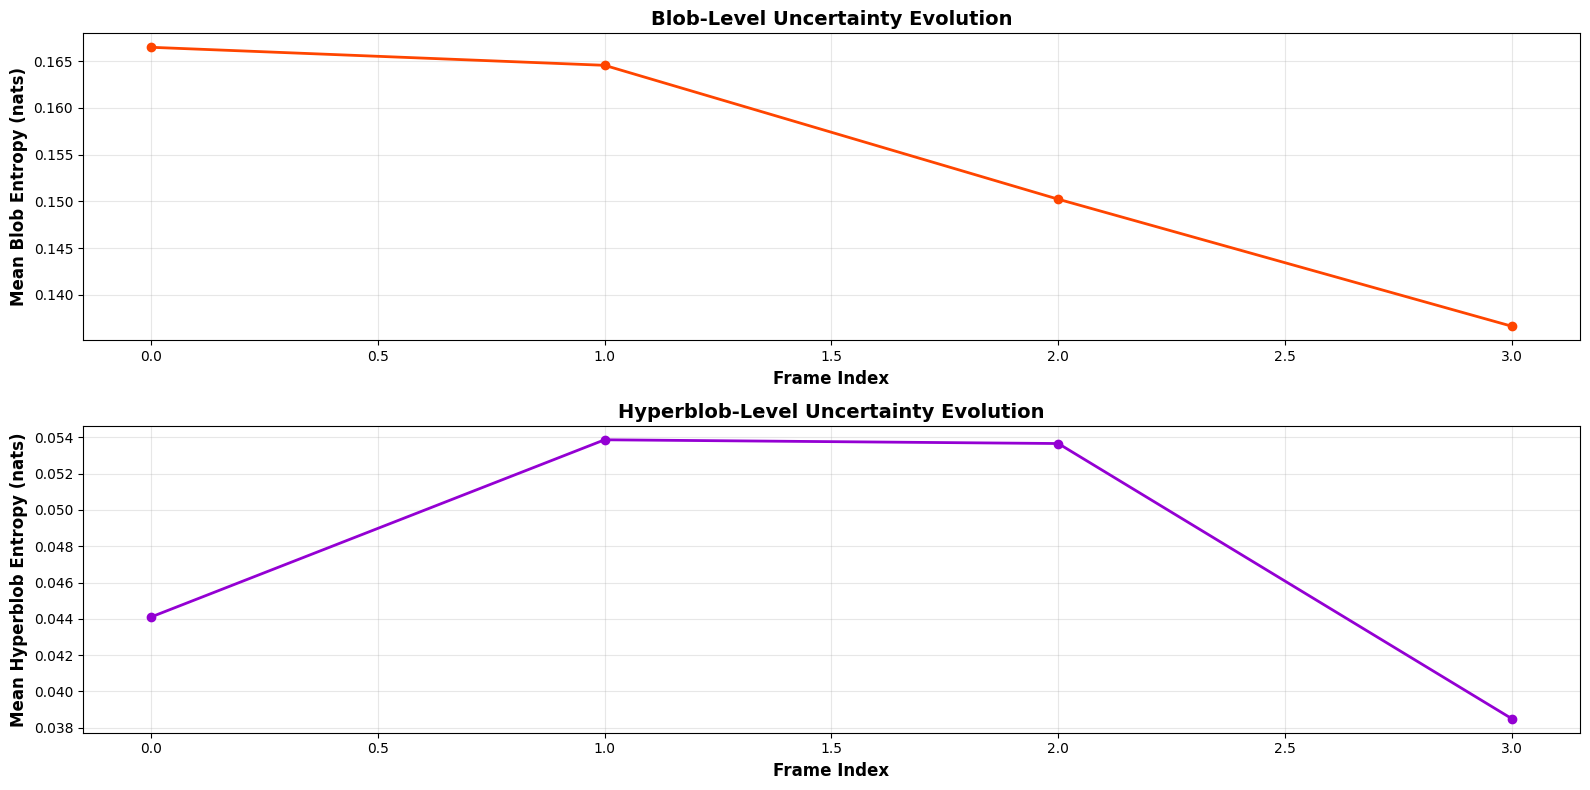

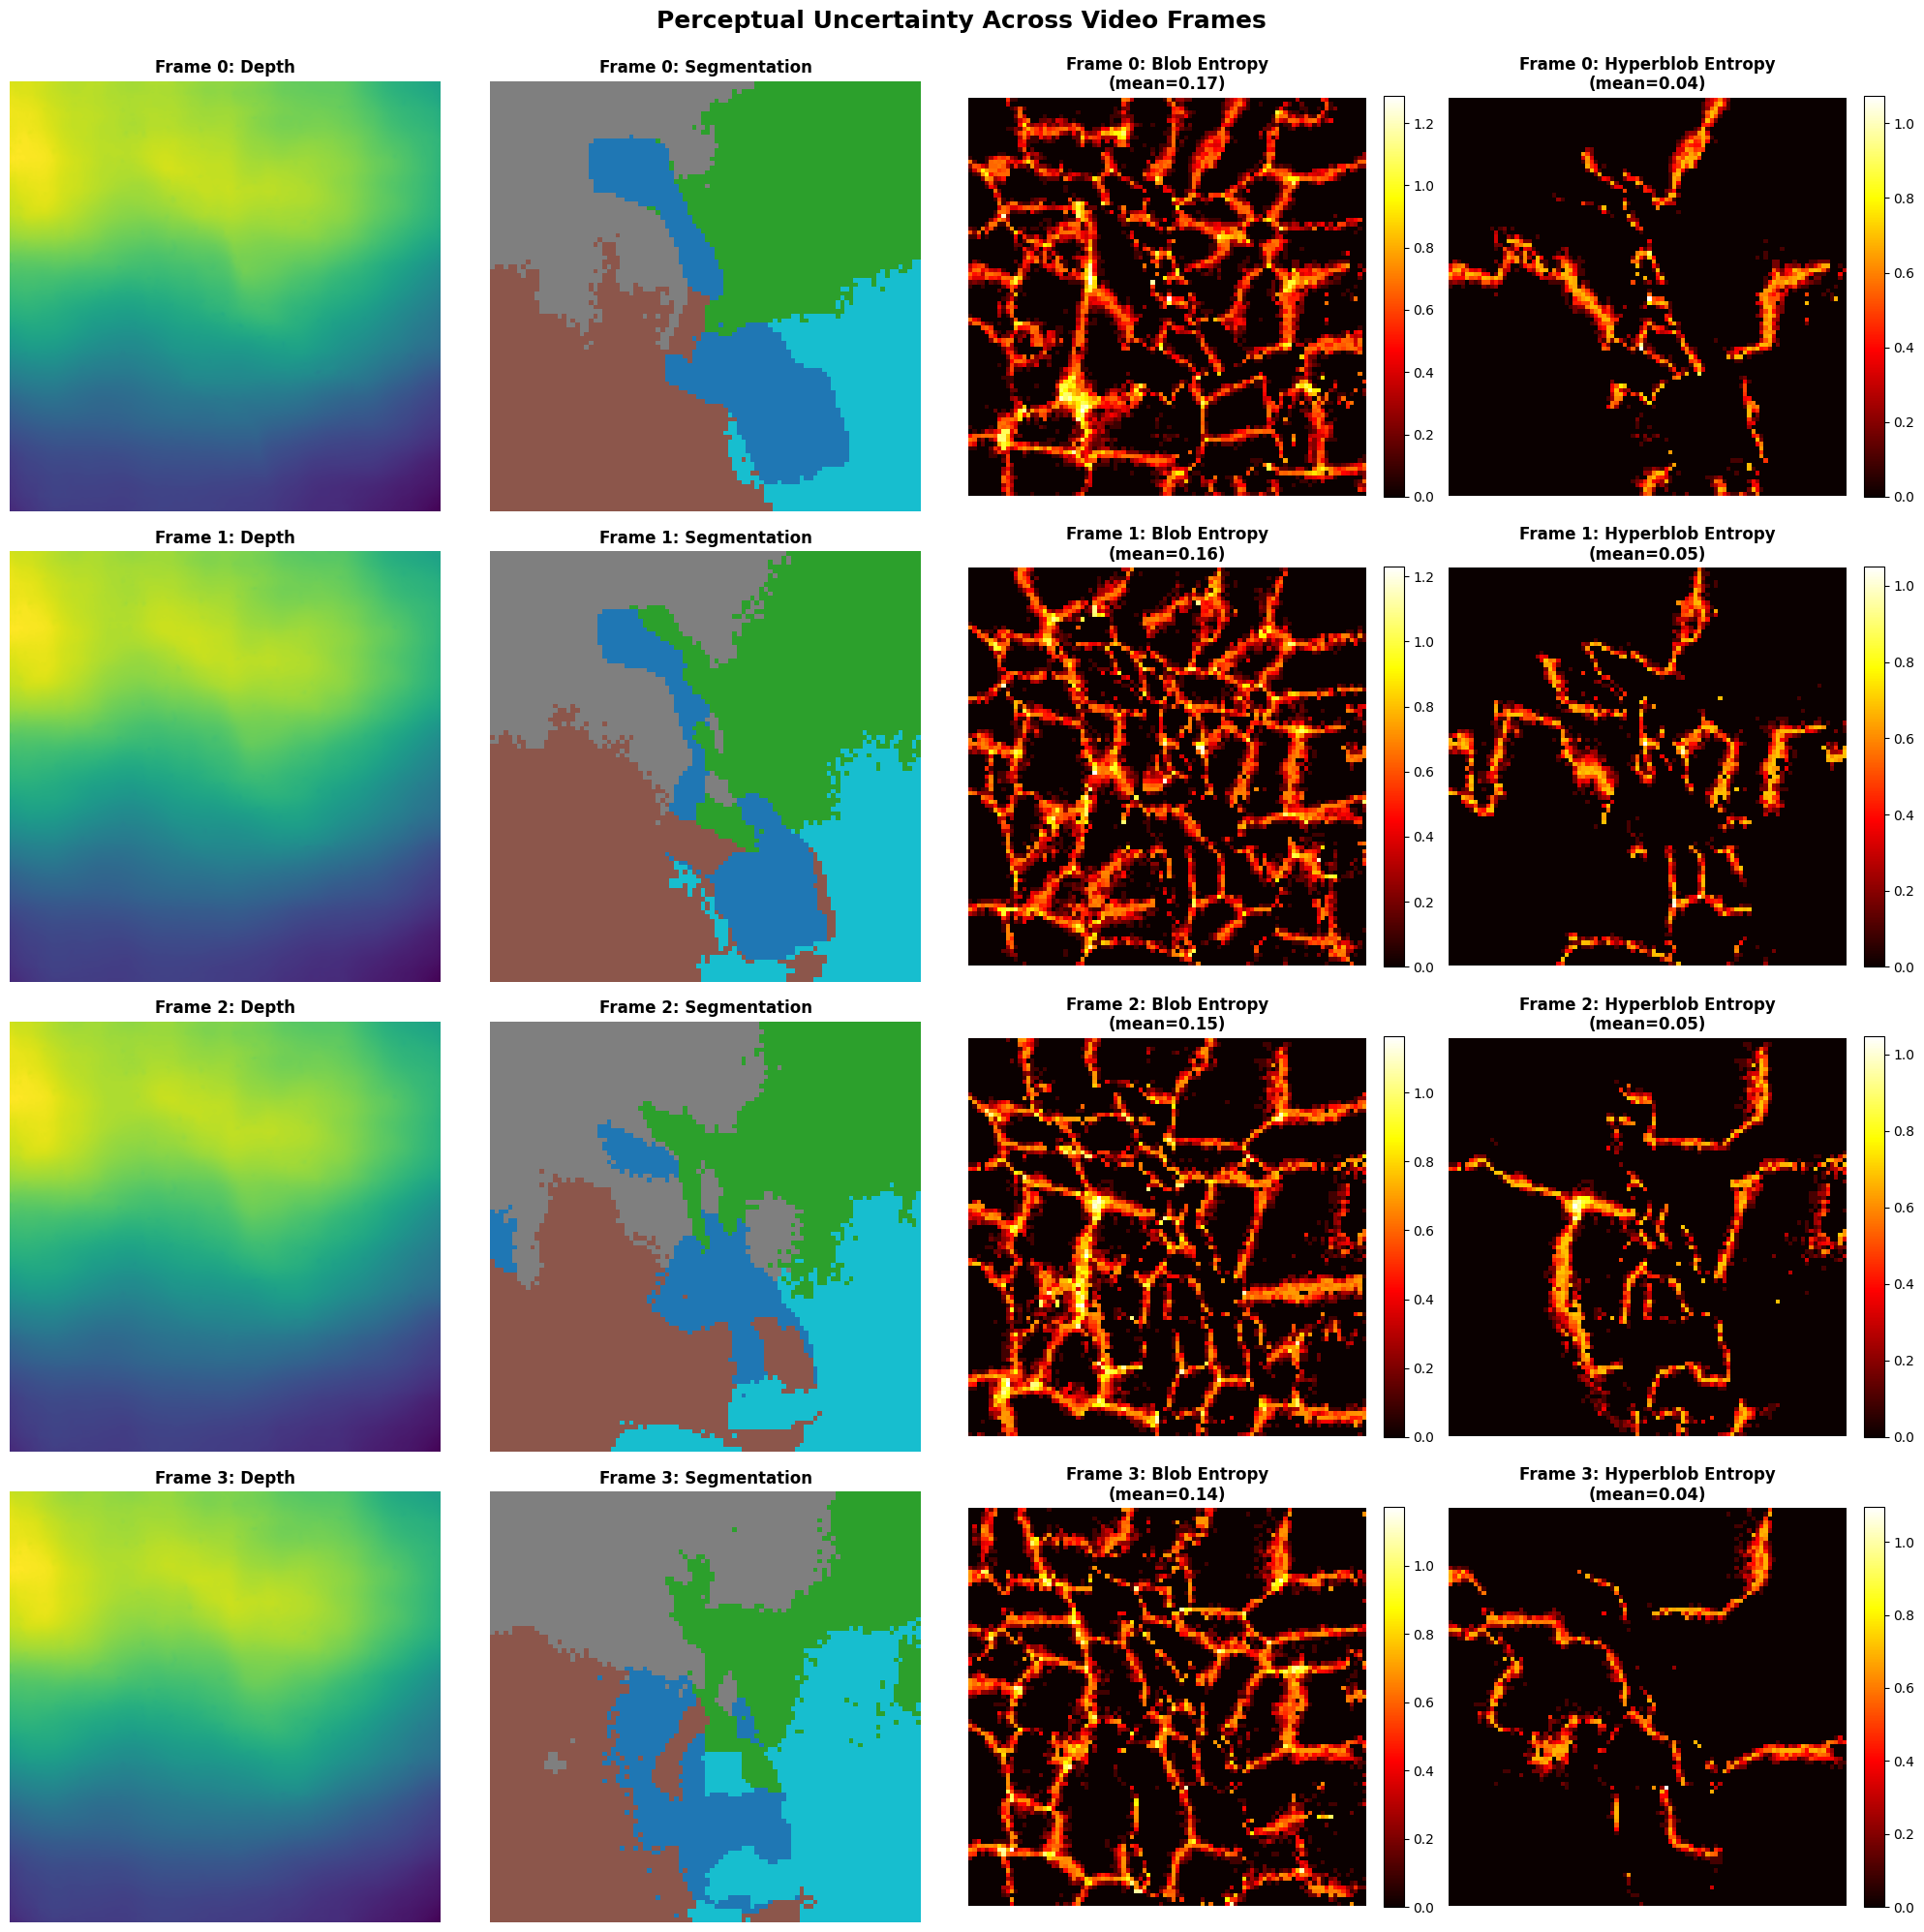


UNCERTAINTY STATISTICS SUMMARY

Blob Entropy Across Video:
  Mean (all frames): 0.154 nats
  Std dev: 0.012 nats
  Min (frame 3): 0.137 nats
  Max (frame 0): 0.166 nats

Hyperblob Entropy Across Video:
  Mean (all frames): 0.048 nats
  Std dev: 0.007 nats
  Min (frame 3): 0.038 nats
  Max (frame 1): 0.054 nats

✓ Video uncertainty analysis complete!


In [27]:
# ============================================================================
# VIDEO UNCERTAINTY VISUALIZATION
# ============================================================================

print("\n" + "="*70)
print("PERCEPTUAL UNCERTAINTY EVOLUTION ACROSS VIDEO")
print("="*70)

print(f"\nTotal frames with uncertainty: {len(all_frame_blob_entropy)}")

# ============================================================================
# UNCERTAINTY STATISTICS OVER TIME
# ============================================================================

# Compute mean entropy for each frame
mean_blob_entropy_per_frame = [np.mean(e) for e in all_frame_blob_entropy]
mean_hyperblob_entropy_per_frame = [np.mean(e) for e in all_frame_hyperblob_entropy]

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# Plot blob uncertainty over time
ax1 = axes[0]
ax1.plot(range(len(mean_blob_entropy_per_frame)), mean_blob_entropy_per_frame, 
         'o-', linewidth=2, markersize=6, color='orangered')
ax1.set_xlabel('Frame Index', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Blob Entropy (nats)', fontsize=12, fontweight='bold')
ax1.set_title('Blob-Level Uncertainty Evolution', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot hyperblob uncertainty over time
ax2 = axes[1]
ax2.plot(range(len(mean_hyperblob_entropy_per_frame)), mean_hyperblob_entropy_per_frame, 
         'o-', linewidth=2, markersize=6, color='darkviolet')
ax2.set_xlabel('Frame Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Mean Hyperblob Entropy (nats)', fontsize=12, fontweight='bold')
ax2.set_title('Hyperblob-Level Uncertainty Evolution', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# SPATIAL UNCERTAINTY MAPS FOR SELECTED FRAMES
# ============================================================================

# Select frames to visualize (first, middle, last, and peak uncertainty)
num_frames = len(all_frame_blob_entropy)
selected_frames = [
    0,  # First frame
    num_frames // 2,  # Middle frame
    np.argmax(mean_hyperblob_entropy_per_frame),  # Peak uncertainty
    num_frames - 1  # Last frame
]
selected_frames = sorted(list(set(selected_frames)))  # Remove duplicates

fig = plt.figure(figsize=(20, 5 * len(selected_frames)))

for plot_idx, frame_idx in enumerate(selected_frames):
    row = plot_idx
    
    # Depth image
    ax1 = plt.subplot(len(selected_frames), 4, row * 4 + 1)
    ax1.imshow(depth[frame_idx], cmap='viridis')
    ax1.set_title(f'Frame {frame_idx}: Depth', fontsize=12, fontweight='bold')
    ax1.axis('off')
    
    # Segmentation mask
    ax2 = plt.subplot(len(selected_frames), 4, row * 4 + 2)
    ax2.imshow(all_frame_masks[frame_idx].reshape((target_hw, target_hw)), cmap='tab10')
    ax2.set_title(f'Frame {frame_idx}: Segmentation', fontsize=12, fontweight='bold')
    ax2.axis('off')
    
    # Blob entropy
    ax3 = plt.subplot(len(selected_frames), 4, row * 4 + 3)
    im1 = ax3.imshow(all_frame_blob_entropy[frame_idx], cmap='hot', vmin=0)
    ax3.set_title(f'Frame {frame_idx}: Blob Entropy\n(mean={mean_blob_entropy_per_frame[frame_idx]:.2f})', 
                  fontsize=12, fontweight='bold')
    ax3.axis('off')
    plt.colorbar(im1, ax=ax3, fraction=0.046, pad=0.04)
    
    # Hyperblob entropy
    ax4 = plt.subplot(len(selected_frames), 4, row * 4 + 4)
    im2 = ax4.imshow(all_frame_hyperblob_entropy[frame_idx], cmap='hot', vmin=0)
    ax4.set_title(f'Frame {frame_idx}: Hyperblob Entropy\n(mean={mean_hyperblob_entropy_per_frame[frame_idx]:.2f})', 
                  fontsize=12, fontweight='bold')
    ax4.axis('off')
    plt.colorbar(im2, ax=ax4, fraction=0.046, pad=0.04)

plt.suptitle('Perceptual Uncertainty Across Video Frames', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

# ============================================================================
# SUMMARY STATISTICS
# ============================================================================

print(f"\n{'='*60}")
print("UNCERTAINTY STATISTICS SUMMARY")
print(f"{'='*60}")

print(f"\nBlob Entropy Across Video:")
print(f"  Mean (all frames): {np.mean(mean_blob_entropy_per_frame):.3f} nats")
print(f"  Std dev: {np.std(mean_blob_entropy_per_frame):.3f} nats")
print(f"  Min (frame {np.argmin(mean_blob_entropy_per_frame)}): {np.min(mean_blob_entropy_per_frame):.3f} nats")
print(f"  Max (frame {np.argmax(mean_blob_entropy_per_frame)}): {np.max(mean_blob_entropy_per_frame):.3f} nats")

print(f"\nHyperblob Entropy Across Video:")
print(f"  Mean (all frames): {np.mean(mean_hyperblob_entropy_per_frame):.3f} nats")
print(f"  Std dev: {np.std(mean_hyperblob_entropy_per_frame):.3f} nats")
print(f"  Min (frame {np.argmin(mean_hyperblob_entropy_per_frame)}): {np.min(mean_hyperblob_entropy_per_frame):.3f} nats")
print(f"  Max (frame {np.argmax(mean_hyperblob_entropy_per_frame)}): {np.max(mean_hyperblob_entropy_per_frame):.3f} nats")

print(f"\n{'='*60}")
print("✓ Video uncertainty analysis complete!")
print(f"{'='*60}")

## Visualize Inferred Motion Over Time

Plot the inferred translation and rotation velocities for each hyperblob across all frames.

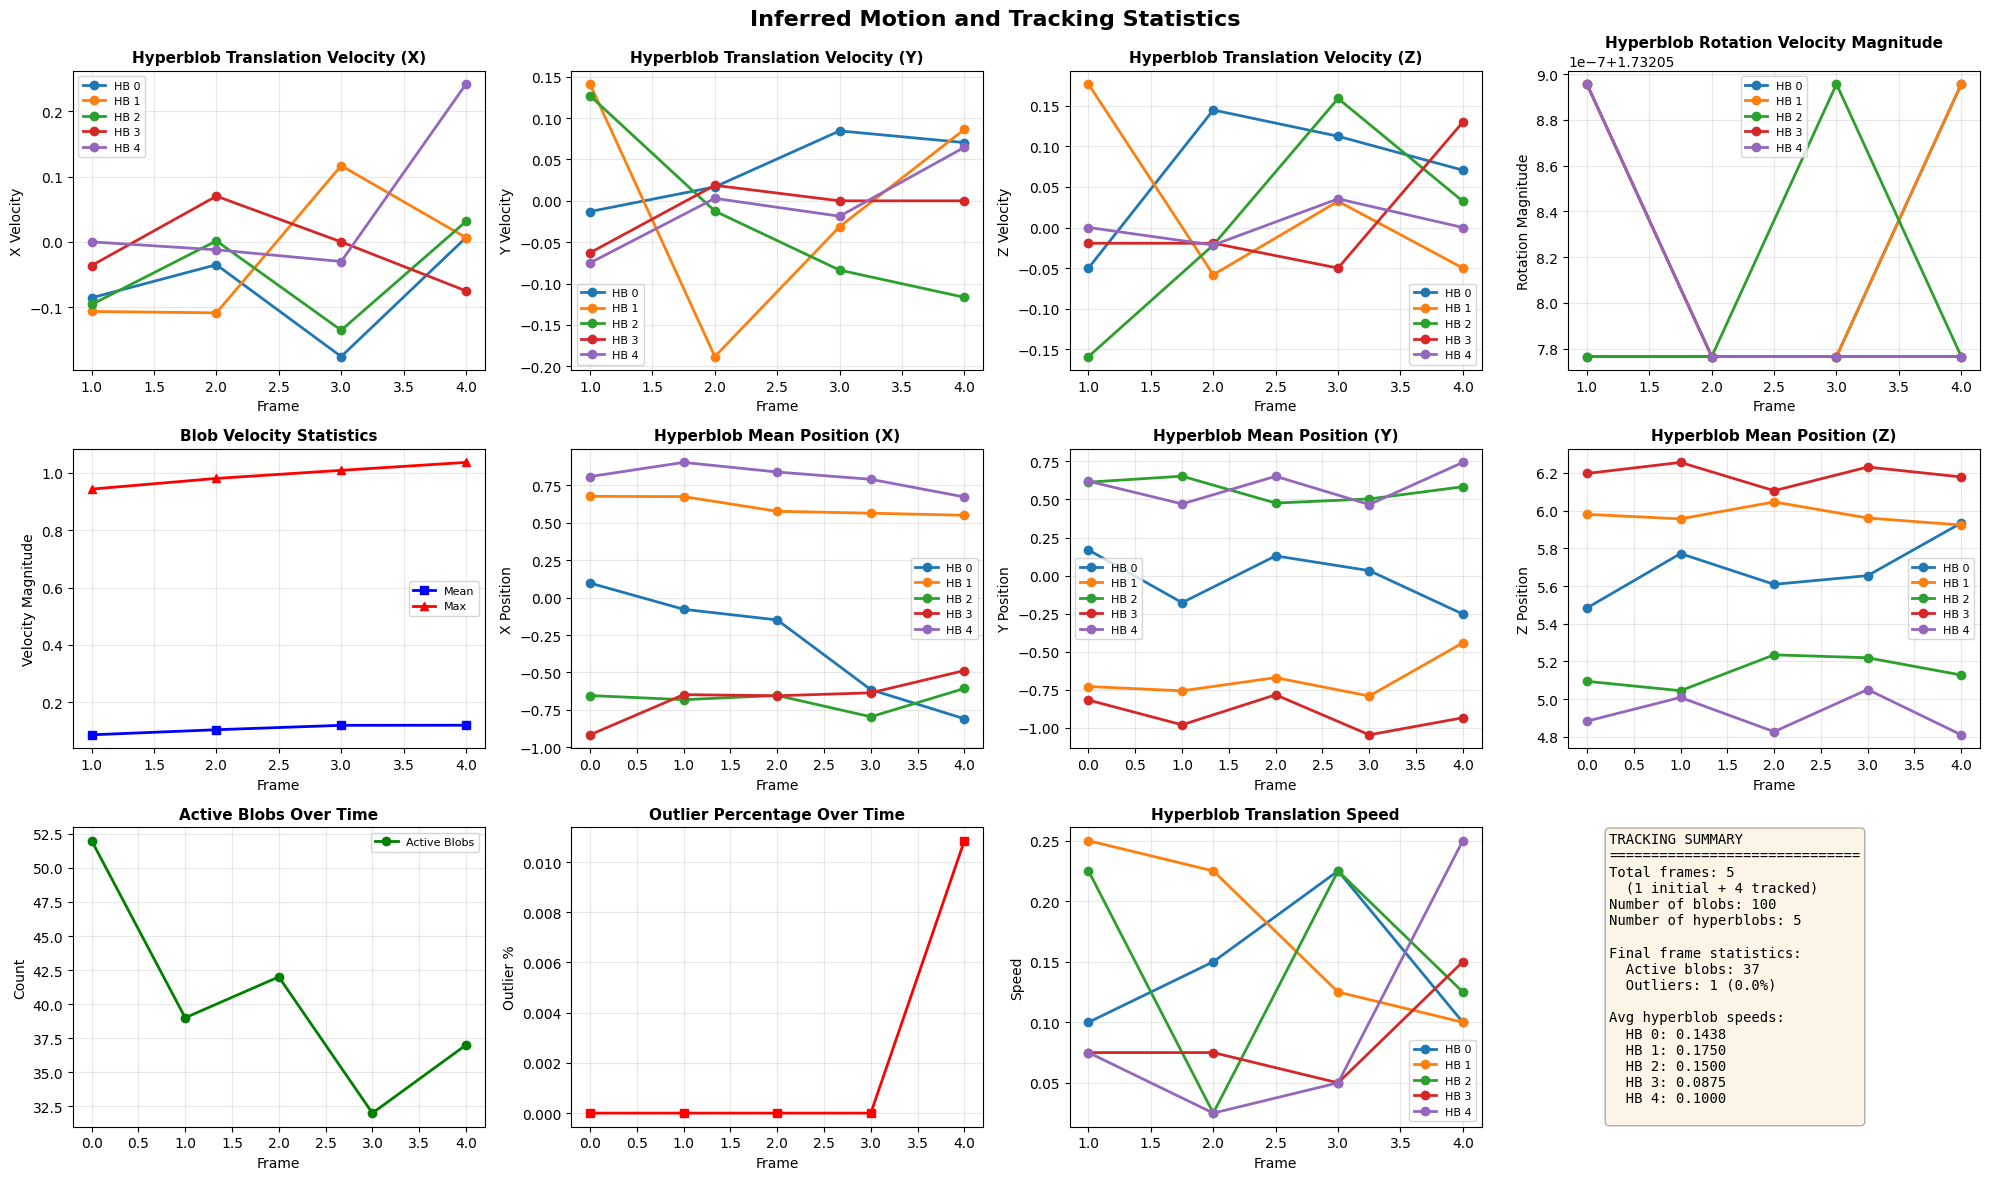


✓ Motion visualization complete


In [28]:
# Extract motion data for tracked frames
# Motion info is only for tracked frames (1, 2, 3, ...)
tracked_frames = np.arange(1, num_tracking_frames + 1)
# All frames includes initial frame (0, 1, 2, 3, ...)
all_frames = np.arange(0, num_tracking_frames + 1)

# Create comprehensive motion visualization
fig = plt.figure(figsize=(20, 12))

# Plot hyperblob translation velocities (X, Y, Z components)
# Motion info only exists for tracked frames
for component_idx, component_name in enumerate(['X', 'Y', 'Z']):
    ax = plt.subplot(3, 4, component_idx + 1)
    for hb_id in range(number_of_hyperblobs):
        trans_vels = [motion_info['hyperblob_trans_vels'][hb_id][component_idx] 
                      for motion_info in all_frame_motion_info]
        ax.plot(tracked_frames, trans_vels, marker='o', linewidth=2, label=f'HB {hb_id}')
    ax.set_xlabel('Frame', fontsize=10)
    ax.set_ylabel(f'{component_name} Velocity', fontsize=10)
    ax.set_title(f'Hyperblob Translation Velocity ({component_name})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Plot hyperblob rotation velocity magnitudes
ax = plt.subplot(3, 4, 4)
for hb_id in range(number_of_hyperblobs):
    rot_vel_mags = [np.linalg.norm(motion_info['hyperblob_rot_vels'][hb_id]) 
                    for motion_info in all_frame_motion_info]
    ax.plot(tracked_frames, rot_vel_mags, marker='o', linewidth=2, label=f'HB {hb_id}')
ax.set_xlabel('Frame', fontsize=10)
ax.set_ylabel('Rotation Magnitude', fontsize=10)
ax.set_title('Hyperblob Rotation Velocity Magnitude', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot blob velocity statistics
ax = plt.subplot(3, 4, 5)
mean_blob_vels = []
max_blob_vels = []
for motion_info in all_frame_motion_info:
    blob_vels = motion_info['blob_vel_means']
    vel_mags = np.linalg.norm(blob_vels, axis=1)
    mean_blob_vels.append(np.mean(vel_mags))
    max_blob_vels.append(np.max(vel_mags))

ax.plot(tracked_frames, mean_blob_vels, marker='s', linewidth=2, label='Mean', color='blue')
ax.plot(tracked_frames, max_blob_vels, marker='^', linewidth=2, label='Max', color='red')
ax.set_xlabel('Frame', fontsize=10)
ax.set_ylabel('Velocity Magnitude', fontsize=10)
ax.set_title('Blob Velocity Statistics', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Plot hyperblob mean positions over time (to show trajectory)
# Positions exist for all frames (including initial frame 0)
for component_idx, component_name in enumerate(['X', 'Y', 'Z']):
    ax = plt.subplot(3, 4, 6 + component_idx)
    for hb_id in range(number_of_hyperblobs):
        hb_positions = []
        for state in all_frame_states:
            hb_mean = np.array(state.hyperblobs_state.hyperblob_means)[hb_id]
            hb_positions.append(hb_mean[component_idx])
        ax.plot(all_frames, hb_positions, marker='o', linewidth=2, label=f'HB {hb_id}')
    ax.set_xlabel('Frame', fontsize=10)
    ax.set_ylabel(f'{component_name} Position', fontsize=10)
    ax.set_title(f'Hyperblob Mean Position ({component_name})', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

# Plot number of active blobs and outliers over time
# Statistics exist for all frames
ax = plt.subplot(3, 4, 9)
n_active_blobs = []
n_outliers = []
n_total_points = []

for state in all_frame_states:
    blob_weights = np.array(state.blobs_state.blob_weights)
    blob_assignments = np.array(state.datapoints_state.blob_assignments)
    
    n_active_blobs.append(np.sum(blob_weights > 0.01))
    n_outliers.append(np.sum(blob_assignments >= number_of_blobs))
    n_total_points.append(len(blob_assignments))

ax.plot(all_frames, n_active_blobs, marker='o', linewidth=2, label='Active Blobs', color='green')
ax.set_xlabel('Frame', fontsize=10)
ax.set_ylabel('Count', fontsize=10)
ax.set_title('Active Blobs Over Time', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = plt.subplot(3, 4, 10)
outlier_pct = [100 * n_outliers[i] / n_total_points[i] for i in range(len(n_outliers))]
ax.plot(all_frames, outlier_pct, marker='s', linewidth=2, color='red')
ax.set_xlabel('Frame', fontsize=10)
ax.set_ylabel('Outlier %', fontsize=10)
ax.set_title('Outlier Percentage Over Time', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)

# Plot hyperblob velocity magnitudes (combined translation)
ax = plt.subplot(3, 4, 11)
for hb_id in range(number_of_hyperblobs):
    trans_vel_mags = [np.linalg.norm(motion_info['hyperblob_trans_vels'][hb_id]) 
                      for motion_info in all_frame_motion_info]
    ax.plot(tracked_frames, trans_vel_mags, marker='o', linewidth=2, label=f'HB {hb_id}')
ax.set_xlabel('Frame', fontsize=10)
ax.set_ylabel('Speed', fontsize=10)
ax.set_title('Hyperblob Translation Speed', fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Summary statistics text
ax = plt.subplot(3, 4, 12)
ax.axis('off')
summary_text = f"TRACKING SUMMARY\n{'='*30}\n"
summary_text += f"Total frames: {num_tracking_frames + 1}\n"
summary_text += f"  (1 initial + {num_tracking_frames} tracked)\n"
summary_text += f"Number of blobs: {number_of_blobs}\n"
summary_text += f"Number of hyperblobs: {number_of_hyperblobs}\n\n"
summary_text += f"Final frame statistics:\n"
summary_text += f"  Active blobs: {n_active_blobs[-1]}\n"
summary_text += f"  Outliers: {n_outliers[-1]} ({outlier_pct[-1]:.1f}%)\n\n"

# Compute average velocities
avg_trans_vels = np.mean([np.linalg.norm(motion_info['hyperblob_trans_vels'], axis=1) 
                          for motion_info in all_frame_motion_info], axis=0)
summary_text += f"Avg hyperblob speeds:\n"
for hb_id in range(number_of_hyperblobs):
    summary_text += f"  HB {hb_id}: {avg_trans_vels[hb_id]:.4f}\n"

ax.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
        family='monospace', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.suptitle('Inferred Motion and Tracking Statistics', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✓ Motion visualization complete")

## Save Tracked Segmentation Masks

Save the segmentation masks for all tracked frames to a new folder.

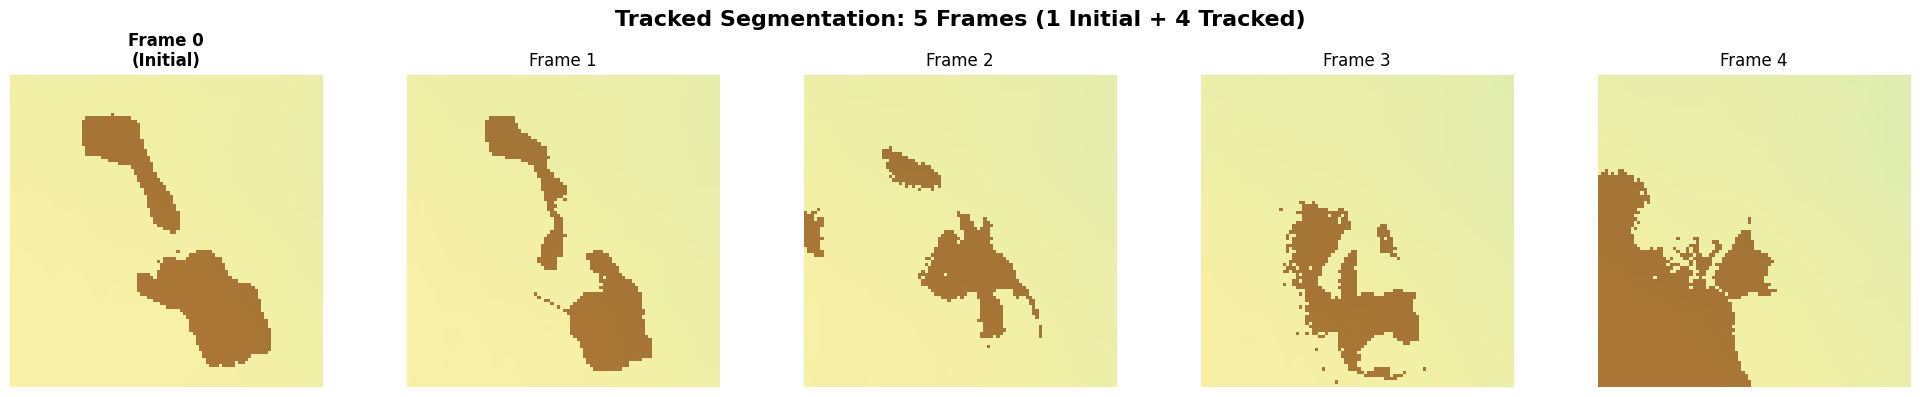


✓ Visualized all 5 frames (1 initial + 4 tracked)


In [29]:
# Visualize ALL frames (initial + tracked) in a grid
total_frames = num_tracking_frames + 1  # 1 initial + N tracked

# Create a grid that fits all frames nicely
n_cols = min(5, total_frames)
n_rows = (total_frames + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)
axes = axes.flatten()

for frame_idx in range(total_frames):
    # Get frame state
    frame_state = all_frame_states[frame_idx]
    
    # Get blob and hyperblob assignments
    frame_blob_assignments = np.array(frame_state.datapoints_state.blob_assignments)
    frame_hyperblob_assignments = np.array(frame_state.blobs_state.hyperblob_assignments)
    
    # Map datapoints to hyperblobs
    frame_pixel_hyperblobs = np.array([
        frame_hyperblob_assignments[blob_id] if blob_id < len(frame_hyperblob_assignments) else -1
        for blob_id in frame_blob_assignments
    ])
    
    # Use the ROI hyperblob ID determined by mask-guided k-means
    roi_hyperblob_id = all_roi_hyperblob_ids[frame_idx]
    roi_hyperblob_mask = (frame_pixel_hyperblobs == roi_hyperblob_id)
    
    # Create binary mask image
    mask_img = (roi_hyperblob_mask.reshape((target_hw, target_hw)) * 255).astype(np.uint8)
    
    # Display
    axes[frame_idx].imshow(depth[frame_idx], cmap='viridis', alpha=0.7)
    axes[frame_idx].imshow(mask_img, cmap='Reds', alpha=0.5)
    
    # Label frame 0 as initial, rest as their frame number
    if frame_idx == 0:
        axes[frame_idx].set_title('Frame 0\n(Initial)', fontsize=12, fontweight='bold')
    else:
        axes[frame_idx].set_title(f'Frame {frame_idx}', fontsize=12)
    axes[frame_idx].axis('off')

# Hide any extra subplots
for idx in range(total_frames, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'Tracked Segmentation: {total_frames} Frames (1 Initial + {num_tracking_frames} Tracked)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Visualized all {total_frames} frames (1 initial + {num_tracking_frames} tracked)")

## Accuracy Evaluation

Compute segmentation accuracy by sampling probe points from the true mask.

**Method:**
1. For each frame, sample multiple probe points from the TRUE ROI mask
2. For each probe point:
   - Find which estimated hyperblob contains that point
   - Compute pixel-wise accuracy of that hyperblob's mask vs true mask (over whole image)
3. Average the accuracy scores across all probe points and all frames

This gives us the expected accuracy when using any point from the true ROI as a probe.

ACCURACY EVALUATION
Frame 0 (initial): Accuracy = 0.930 ± 0.121 (n=100 probes)
Frame 1: Accuracy = 0.834 ± 0.149 (n=100 probes)
Frame 2: Accuracy = 0.735 ± 0.101 (n=100 probes)
Frame 3: Accuracy = 0.719 ± 0.074 (n=100 probes)
Frame 4: Accuracy = 0.708 ± 0.036 (n=100 probes)

OVERALL ACCURACY: 0.785 ± 0.085
  Averaged over 5 frames (1 initial + 4 tracked)
  100 probe points sampled per frame


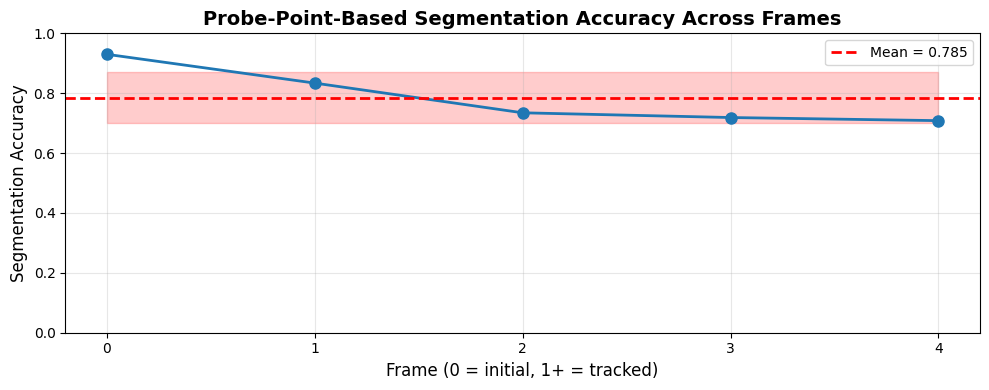


✓ Accuracy evaluation complete!


In [30]:
# Accuracy Evaluation with Probe Point Sampling

def compute_segmentation_accuracy(true_mask, estimated_mask):
    """
    Compute pixel-wise accuracy between true and estimated masks.
    
    Args:
        true_mask: Boolean array (H*W,) - ground truth
        estimated_mask: Boolean array (H*W,) - predicted segmentation
    
    Returns:
        accuracy: Float in [0, 1]
    """
    # Pixel-wise accuracy over entire image
    correct = (true_mask == estimated_mask)
    accuracy = np.mean(correct)
    return accuracy

def evaluate_frame_with_probe_sampling(frame_idx, num_probes=50):
    """
    Evaluate segmentation accuracy for a frame by sampling probe points from true mask.
    
    Args:
        frame_idx: Frame index to evaluate
        num_probes: Number of probe points to sample from true mask
    
    Returns:
        mean_accuracy: Average accuracy across all probe points
        std_accuracy: Standard deviation of accuracies
        probe_accuracies: List of individual probe accuracies
    """
    # Get ground truth mask (properly loaded) and estimated state for this frame
    if gt_masks_resized is None or frame_idx >= len(gt_masks_resized):
        print(f"Warning: No ground truth mask available for frame {frame_idx}")
        return 0.0, 0.0, []
    
    true_mask = gt_masks_resized[frame_idx]
    frame_state = all_frame_states[frame_idx]
    
    # Get estimated blob and hyperblob assignments
    frame_blob_assignments = np.array(frame_state.datapoints_state.blob_assignments)
    frame_hyperblob_assignments = np.array(frame_state.blobs_state.hyperblob_assignments)
    
    # Map datapoints to hyperblobs
    frame_pixel_hyperblobs = np.array([
        frame_hyperblob_assignments[blob_id] if blob_id < len(frame_hyperblob_assignments) else -1
        for blob_id in frame_blob_assignments
    ])
    
    # Find probe points (indices where true mask is True)
    true_roi_indices = np.where(true_mask)[0]
    
    if len(true_roi_indices) == 0:
        print(f"Warning: Frame {frame_idx} has no true ROI points")
        return 0.0, 0.0, []
    
    # Sample probe points (with replacement if fewer than num_probes)
    num_samples = min(num_probes, len(true_roi_indices))
    probe_indices = np.random.choice(true_roi_indices, size=num_samples, replace=False)
    
    probe_accuracies = []
    
    for probe_idx in probe_indices:
        # Find which hyperblob contains this probe point
        probe_hyperblob_id = frame_pixel_hyperblobs[probe_idx]
        
        if probe_hyperblob_id < 0:
            # Probe point is an outlier - skip
            continue
        
        # Create estimated mask for this hyperblob
        estimated_mask = (frame_pixel_hyperblobs == probe_hyperblob_id)
        
        # Compute accuracy
        accuracy = compute_segmentation_accuracy(true_mask, estimated_mask)
        probe_accuracies.append(accuracy)
    
    if len(probe_accuracies) == 0:
        return 0.0, 0.0, []
    
    mean_accuracy = np.mean(probe_accuracies)
    std_accuracy = np.std(probe_accuracies)
    
    return mean_accuracy, std_accuracy, probe_accuracies

# Run evaluation across all frames (initial + tracked)
total_frames = num_tracking_frames + 1
print("="*60)
print("ACCURACY EVALUATION")
print("="*60)

num_probes_per_frame = 100
all_frame_accuracies = []

for frame_idx in range(total_frames):
    mean_acc, std_acc, probe_accs = evaluate_frame_with_probe_sampling(
        frame_idx, 
        num_probes=num_probes_per_frame
    )
    
    all_frame_accuracies.append(mean_acc)
    
    frame_label = f"Frame 0 (initial)" if frame_idx == 0 else f"Frame {frame_idx}"
    print(f"{frame_label}: Accuracy = {mean_acc:.3f} ± {std_acc:.3f} (n={len(probe_accs)} probes)")

# Overall statistics
overall_mean = np.mean(all_frame_accuracies)
overall_std = np.std(all_frame_accuracies)

print("\n" + "="*60)
print(f"OVERALL ACCURACY: {overall_mean:.3f} ± {overall_std:.3f}")
print(f"  Averaged over {total_frames} frames (1 initial + {num_tracking_frames} tracked)")
print(f"  {num_probes_per_frame} probe points sampled per frame")
print("="*60)

# Visualize accuracy across frames
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
frame_numbers = range(0, total_frames)  # Frame 0, 1, 2, ...
ax.plot(frame_numbers, all_frame_accuracies, 'o-', linewidth=2, markersize=8)
ax.axhline(overall_mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {overall_mean:.3f}')
ax.fill_between(frame_numbers, 
                 overall_mean - overall_std, 
                 overall_mean + overall_std, 
                 alpha=0.2, color='red')
ax.set_xlabel('Frame (0 = initial, 1+ = tracked)', fontsize=12)
ax.set_ylabel('Segmentation Accuracy', fontsize=12)
ax.set_title('Probe-Point-Based Segmentation Accuracy Across Frames', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1])
ax.set_xticks(frame_numbers)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\n✓ Accuracy evaluation complete!")

## Standard ROI Metrics

Compute standard segmentation metrics (IoU, Precision, Recall, F1) for each frame by comparing the tracked ROI masks against ground truth.


STANDARD ROI METRICS

Frame 0 (initial):
  IoU:       0.849
  Precision: 0.990
  Recall:    0.856
  F1 Score:  0.918
  Accuracy:  0.976

Frame 1:
  IoU:       0.632
  Precision: 0.962
  Recall:    0.648
  F1 Score:  0.775
  Accuracy:  0.942

Frame 2:
  IoU:       0.319
  Precision: 0.671
  Recall:    0.378
  F1 Score:  0.484
  Accuracy:  0.877

Frame 3:
  IoU:       0.213
  Precision: 0.425
  Recall:    0.299
  F1 Score:  0.351
  Accuracy:  0.834

Frame 4:
  IoU:       0.072
  Precision: 0.109
  Recall:    0.174
  F1 Score:  0.134
  Accuracy:  0.664

AVERAGE METRICS ACROSS ALL FRAMES
IoU:       0.417 ± 0.284
Precision: 0.631 ± 0.333
Recall:    0.471 ± 0.248
F1 Score:  0.532 ± 0.283
Accuracy:  0.859 ± 0.109


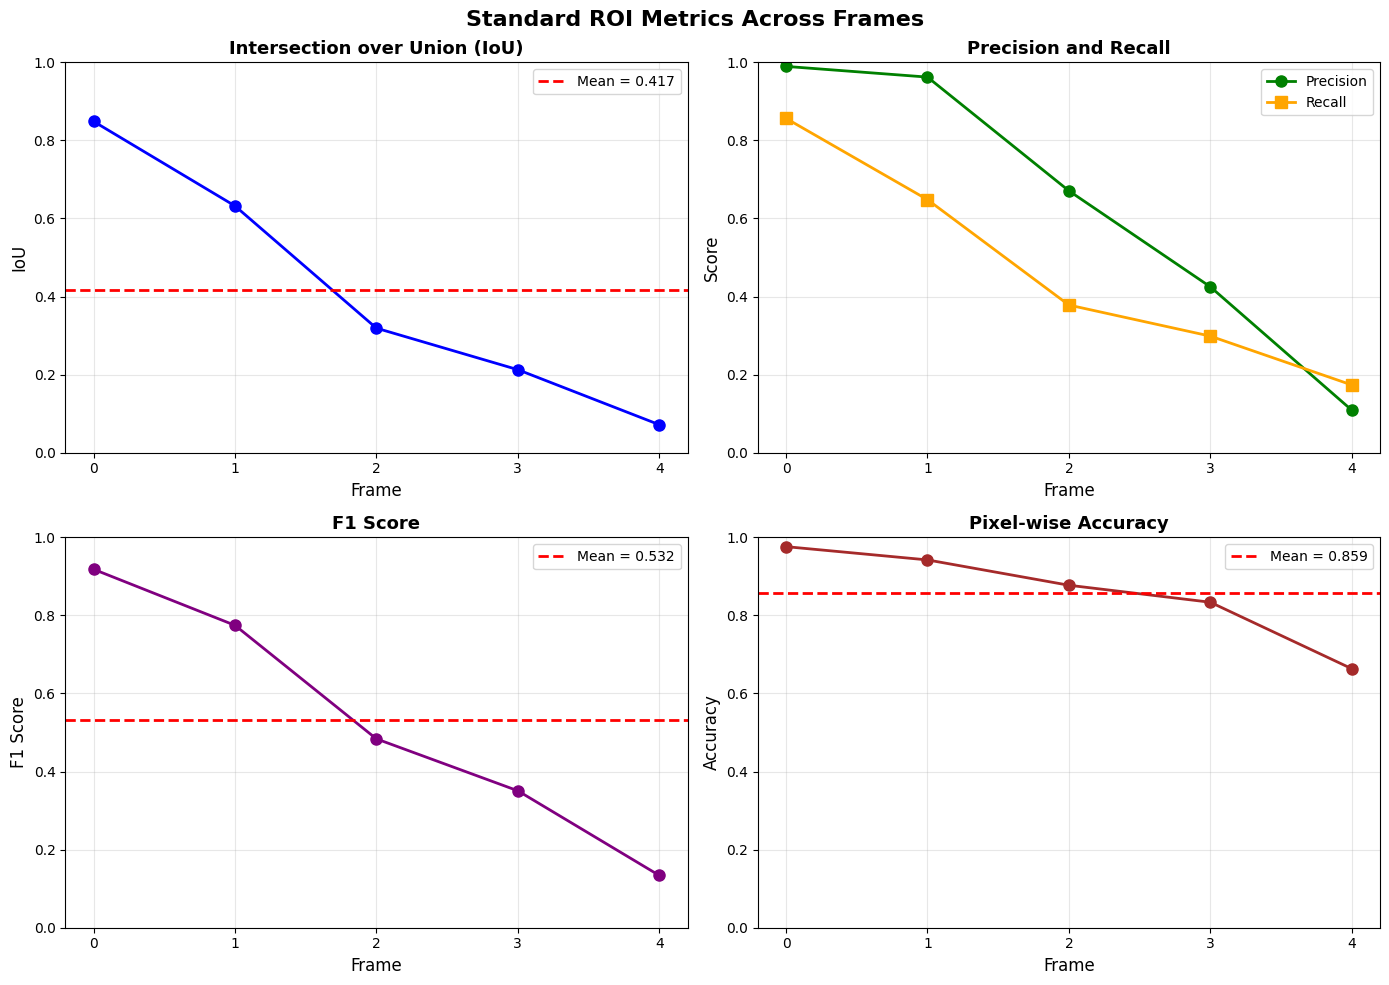


✓ ROI metrics evaluation complete!


In [31]:
# Compute standard ROI metrics (IoU, Precision, Recall, F1) for each frame

def compute_roi_metrics(true_mask, pred_mask):
    """
    Compute standard ROI segmentation metrics.
    
    Args:
        true_mask: Boolean array - ground truth ROI
        pred_mask: Boolean array - predicted ROI
    
    Returns:
        dict with IoU, Precision, Recall, F1, and Accuracy
    """
    # True Positives, False Positives, False Negatives
    tp = np.sum(true_mask & pred_mask)
    fp = np.sum(~true_mask & pred_mask)
    fn = np.sum(true_mask & ~pred_mask)
    tn = np.sum(~true_mask & ~pred_mask)
    
    # IoU (Intersection over Union)
    intersection = tp
    union = tp + fp + fn
    iou = intersection / union if union > 0 else 0.0
    
    # Precision (Positive Predictive Value)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    # Recall (Sensitivity, True Positive Rate)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    # F1 Score (Harmonic mean of precision and recall)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # Pixel-wise Accuracy
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    return {
        'iou': iou,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn
    }

# Evaluate all frames
print("="*70)
print("STANDARD ROI METRICS")
print("="*70)

all_metrics = []

for frame_idx in range(total_frames):
    # Get ground truth mask
    if gt_masks_resized is None or frame_idx >= len(gt_masks_resized):
        print(f"Warning: No ground truth for frame {frame_idx}")
        continue
    
    true_mask = gt_masks_resized[frame_idx]
    
    # Get predicted mask
    frame_state = all_frame_states[frame_idx]
    frame_blob_assignments = np.array(frame_state.datapoints_state.blob_assignments)
    frame_hyperblob_assignments = np.array(frame_state.blobs_state.hyperblob_assignments)
    
    # Map datapoints to hyperblobs
    frame_pixel_hyperblobs = np.array([
        frame_hyperblob_assignments[blob_id] if blob_id < len(frame_hyperblob_assignments) else -1
        for blob_id in frame_blob_assignments
    ])
    
    # Get predicted ROI mask using the tracked hyperblob ID
    roi_hyperblob_id = all_roi_hyperblob_ids[frame_idx]
    pred_mask = (frame_pixel_hyperblobs == roi_hyperblob_id)
    
    # Compute metrics
    metrics = compute_roi_metrics(true_mask, pred_mask)
    all_metrics.append(metrics)
    
    # Print frame metrics
    frame_label = "Frame 0 (initial)" if frame_idx == 0 else f"Frame {frame_idx}"
    print(f"\n{frame_label}:")
    print(f"  IoU:       {metrics['iou']:.3f}")
    print(f"  Precision: {metrics['precision']:.3f}")
    print(f"  Recall:    {metrics['recall']:.3f}")
    print(f"  F1 Score:  {metrics['f1']:.3f}")
    print(f"  Accuracy:  {metrics['accuracy']:.3f}")

# Compute average metrics
if all_metrics:
    avg_metrics = {
        'iou': np.mean([m['iou'] for m in all_metrics]),
        'precision': np.mean([m['precision'] for m in all_metrics]),
        'recall': np.mean([m['recall'] for m in all_metrics]),
        'f1': np.mean([m['f1'] for m in all_metrics]),
        'accuracy': np.mean([m['accuracy'] for m in all_metrics])
    }
    
    std_metrics = {
        'iou': np.std([m['iou'] for m in all_metrics]),
        'precision': np.std([m['precision'] for m in all_metrics]),
        'recall': np.std([m['recall'] for m in all_metrics]),
        'f1': np.std([m['f1'] for m in all_metrics]),
        'accuracy': np.std([m['accuracy'] for m in all_metrics])
    }
    
    print("\n" + "="*70)
    print("AVERAGE METRICS ACROSS ALL FRAMES")
    print("="*70)
    print(f"IoU:       {avg_metrics['iou']:.3f} ± {std_metrics['iou']:.3f}")
    print(f"Precision: {avg_metrics['precision']:.3f} ± {std_metrics['precision']:.3f}")
    print(f"Recall:    {avg_metrics['recall']:.3f} ± {std_metrics['recall']:.3f}")
    print(f"F1 Score:  {avg_metrics['f1']:.3f} ± {std_metrics['f1']:.3f}")
    print(f"Accuracy:  {avg_metrics['accuracy']:.3f} ± {std_metrics['accuracy']:.3f}")
    print("="*70)
    
    # Visualize metrics over time
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    frame_numbers = range(0, total_frames)
    
    # Plot IoU
    ax = axes[0, 0]
    ious = [m['iou'] for m in all_metrics]
    ax.plot(frame_numbers, ious, 'o-', linewidth=2, markersize=8, color='blue')
    ax.axhline(avg_metrics['iou'], color='red', linestyle='--', linewidth=2, label=f"Mean = {avg_metrics['iou']:.3f}")
    ax.set_xlabel('Frame', fontsize=12)
    ax.set_ylabel('IoU', fontsize=12)
    ax.set_title('Intersection over Union (IoU)', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticks(frame_numbers)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot Precision and Recall
    ax = axes[0, 1]
    precisions = [m['precision'] for m in all_metrics]
    recalls = [m['recall'] for m in all_metrics]
    ax.plot(frame_numbers, precisions, 'o-', linewidth=2, markersize=8, color='green', label='Precision')
    ax.plot(frame_numbers, recalls, 's-', linewidth=2, markersize=8, color='orange', label='Recall')
    ax.set_xlabel('Frame', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Precision and Recall', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticks(frame_numbers)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot F1 Score
    ax = axes[1, 0]
    f1s = [m['f1'] for m in all_metrics]
    ax.plot(frame_numbers, f1s, 'o-', linewidth=2, markersize=8, color='purple')
    ax.axhline(avg_metrics['f1'], color='red', linestyle='--', linewidth=2, label=f"Mean = {avg_metrics['f1']:.3f}")
    ax.set_xlabel('Frame', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_title('F1 Score', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticks(frame_numbers)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot Accuracy
    ax = axes[1, 1]
    accuracies = [m['accuracy'] for m in all_metrics]
    ax.plot(frame_numbers, accuracies, 'o-', linewidth=2, markersize=8, color='brown')
    ax.axhline(avg_metrics['accuracy'], color='red', linestyle='--', linewidth=2, label=f"Mean = {avg_metrics['accuracy']:.3f}")
    ax.set_xlabel('Frame', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Pixel-wise Accuracy', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticks(frame_numbers)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.suptitle('Standard ROI Metrics Across Frames', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✓ ROI metrics evaluation complete!")


STANDARD ROI METRICS

Frame 0 (initial):
  IoU:       0.849
  Precision: 0.990
  Recall:    0.856
  F1 Score:  0.918
  Accuracy:  0.976

Frame 1:
  IoU:       0.632
  Precision: 0.962
  Recall:    0.648
  F1 Score:  0.775
  Accuracy:  0.942

Frame 2:
  IoU:       0.319
  Precision: 0.671
  Recall:    0.378
  F1 Score:  0.484
  Accuracy:  0.877

Frame 3:
  IoU:       0.213
  Precision: 0.425
  Recall:    0.299
  F1 Score:  0.351
  Accuracy:  0.834

Frame 4:
  IoU:       0.072
  Precision: 0.109
  Recall:    0.174
  F1 Score:  0.134
  Accuracy:  0.664

AVERAGE METRICS ACROSS ALL FRAMES
IoU:       0.417 ± 0.284
Precision: 0.631 ± 0.333
Recall:    0.471 ± 0.248
F1 Score:  0.532 ± 0.283
Accuracy:  0.859 ± 0.109


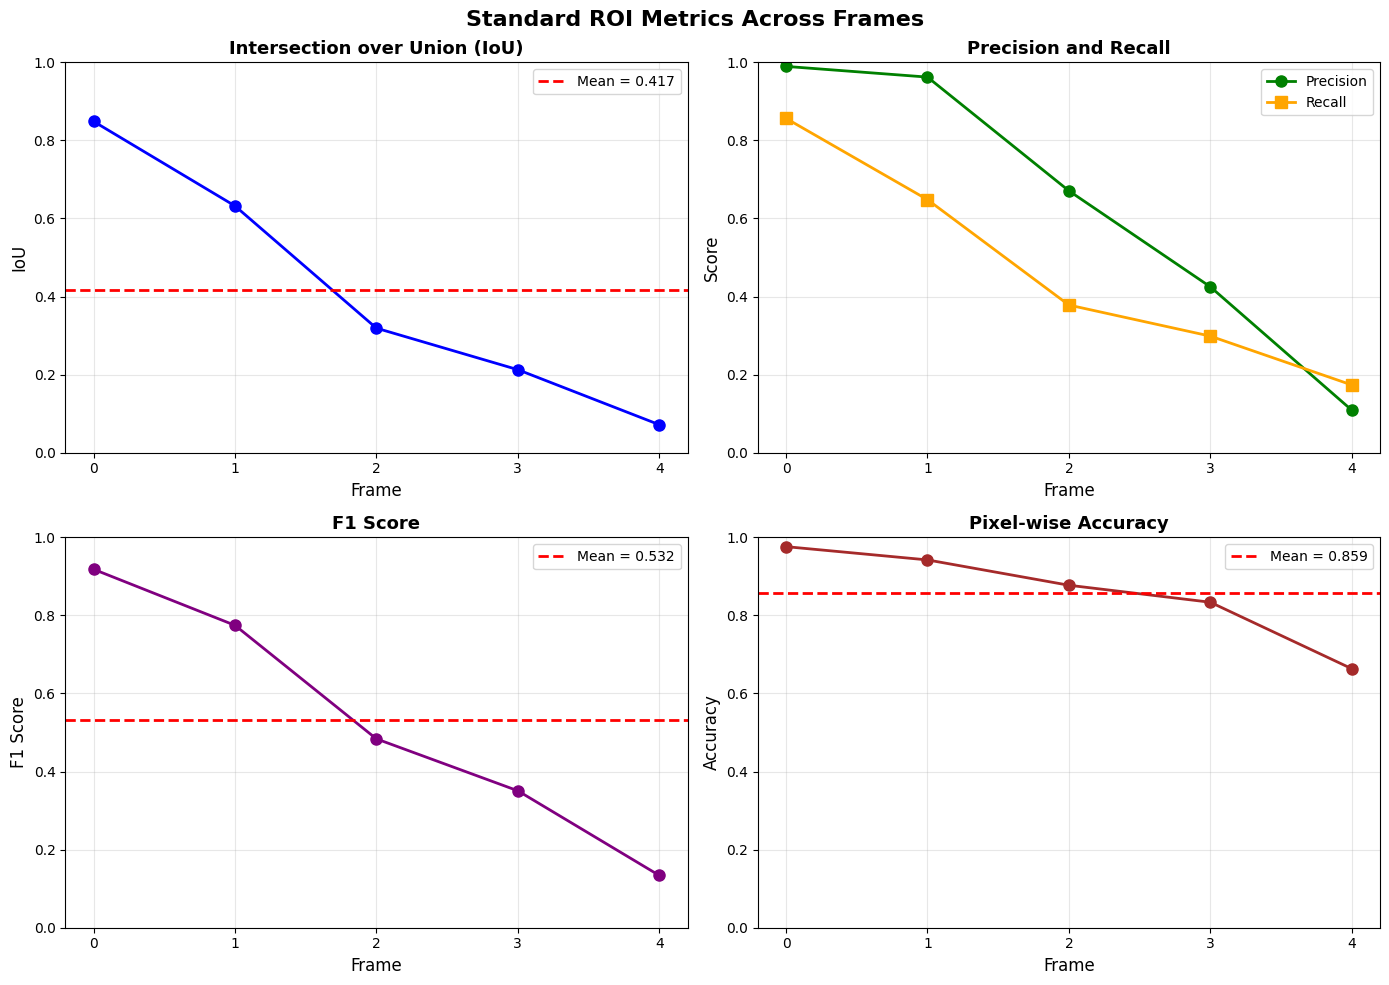


✓ ROI metrics evaluation complete!


In [32]:
# Compute standard ROI metrics (IoU, Precision, Recall, F1) for each frame

def compute_roi_metrics(true_mask, pred_mask):
    """
    Compute standard ROI segmentation metrics.
    
    Args:
        true_mask: Boolean array - ground truth ROI
        pred_mask: Boolean array - predicted ROI
    
    Returns:
        dict with IoU, Precision, Recall, F1, and Accuracy
    """
    # True Positives, False Positives, False Negatives
    tp = np.sum(true_mask & pred_mask)
    fp = np.sum(~true_mask & pred_mask)
    fn = np.sum(true_mask & ~pred_mask)
    tn = np.sum(~true_mask & ~pred_mask)
    
    # IoU (Intersection over Union)
    intersection = tp
    union = tp + fp + fn
    iou = intersection / union if union > 0 else 0.0
    
    # Precision (Positive Predictive Value)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    
    # Recall (Sensitivity, True Positive Rate)
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    
    # F1 Score (Harmonic mean of precision and recall)
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0
    
    # Pixel-wise Accuracy
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    
    return {
        'iou': iou,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'accuracy': accuracy,
        'tp': tp,
        'fp': fp,
        'fn': fn,
        'tn': tn
    }

# Evaluate all frames
print("="*70)
print("STANDARD ROI METRICS")
print("="*70)

all_metrics = []

for frame_idx in range(total_frames):
    # Get ground truth mask
    if gt_masks_resized is None or frame_idx >= len(gt_masks_resized):
        print(f"Warning: No ground truth for frame {frame_idx}")
        continue
    
    true_mask = gt_masks_resized[frame_idx]
    
    # Get predicted mask
    frame_state = all_frame_states[frame_idx]
    frame_blob_assignments = np.array(frame_state.datapoints_state.blob_assignments)
    frame_hyperblob_assignments = np.array(frame_state.blobs_state.hyperblob_assignments)
    
    # Map datapoints to hyperblobs
    frame_pixel_hyperblobs = np.array([
        frame_hyperblob_assignments[blob_id] if blob_id < len(frame_hyperblob_assignments) else -1
        for blob_id in frame_blob_assignments
    ])
    
    # Get predicted ROI mask using the tracked hyperblob ID
    roi_hyperblob_id = all_roi_hyperblob_ids[frame_idx]
    pred_mask = (frame_pixel_hyperblobs == roi_hyperblob_id)
    
    # Compute metrics
    metrics = compute_roi_metrics(true_mask, pred_mask)
    all_metrics.append(metrics)
    
    # Print frame metrics
    frame_label = "Frame 0 (initial)" if frame_idx == 0 else f"Frame {frame_idx}"
    print(f"\n{frame_label}:")
    print(f"  IoU:       {metrics['iou']:.3f}")
    print(f"  Precision: {metrics['precision']:.3f}")
    print(f"  Recall:    {metrics['recall']:.3f}")
    print(f"  F1 Score:  {metrics['f1']:.3f}")
    print(f"  Accuracy:  {metrics['accuracy']:.3f}")

# Compute average metrics
if all_metrics:
    avg_metrics = {
        'iou': np.mean([m['iou'] for m in all_metrics]),
        'precision': np.mean([m['precision'] for m in all_metrics]),
        'recall': np.mean([m['recall'] for m in all_metrics]),
        'f1': np.mean([m['f1'] for m in all_metrics]),
        'accuracy': np.mean([m['accuracy'] for m in all_metrics])
    }
    
    std_metrics = {
        'iou': np.std([m['iou'] for m in all_metrics]),
        'precision': np.std([m['precision'] for m in all_metrics]),
        'recall': np.std([m['recall'] for m in all_metrics]),
        'f1': np.std([m['f1'] for m in all_metrics]),
        'accuracy': np.std([m['accuracy'] for m in all_metrics])
    }
    
    print("\n" + "="*70)
    print("AVERAGE METRICS ACROSS ALL FRAMES")
    print("="*70)
    print(f"IoU:       {avg_metrics['iou']:.3f} ± {std_metrics['iou']:.3f}")
    print(f"Precision: {avg_metrics['precision']:.3f} ± {std_metrics['precision']:.3f}")
    print(f"Recall:    {avg_metrics['recall']:.3f} ± {std_metrics['recall']:.3f}")
    print(f"F1 Score:  {avg_metrics['f1']:.3f} ± {std_metrics['f1']:.3f}")
    print(f"Accuracy:  {avg_metrics['accuracy']:.3f} ± {std_metrics['accuracy']:.3f}")
    print("="*70)
    
    # Visualize metrics over time
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    frame_numbers = range(0, total_frames)
    
    # Plot IoU
    ax = axes[0, 0]
    ious = [m['iou'] for m in all_metrics]
    ax.plot(frame_numbers, ious, 'o-', linewidth=2, markersize=8, color='blue')
    ax.axhline(avg_metrics['iou'], color='red', linestyle='--', linewidth=2, label=f"Mean = {avg_metrics['iou']:.3f}")
    ax.set_xlabel('Frame', fontsize=12)
    ax.set_ylabel('IoU', fontsize=12)
    ax.set_title('Intersection over Union (IoU)', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticks(frame_numbers)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot Precision and Recall
    ax = axes[0, 1]
    precisions = [m['precision'] for m in all_metrics]
    recalls = [m['recall'] for m in all_metrics]
    ax.plot(frame_numbers, precisions, 'o-', linewidth=2, markersize=8, color='green', label='Precision')
    ax.plot(frame_numbers, recalls, 's-', linewidth=2, markersize=8, color='orange', label='Recall')
    ax.set_xlabel('Frame', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Precision and Recall', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticks(frame_numbers)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot F1 Score
    ax = axes[1, 0]
    f1s = [m['f1'] for m in all_metrics]
    ax.plot(frame_numbers, f1s, 'o-', linewidth=2, markersize=8, color='purple')
    ax.axhline(avg_metrics['f1'], color='red', linestyle='--', linewidth=2, label=f"Mean = {avg_metrics['f1']:.3f}")
    ax.set_xlabel('Frame', fontsize=12)
    ax.set_ylabel('F1 Score', fontsize=12)
    ax.set_title('F1 Score', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticks(frame_numbers)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Plot Accuracy
    ax = axes[1, 1]
    accuracies = [m['accuracy'] for m in all_metrics]
    ax.plot(frame_numbers, accuracies, 'o-', linewidth=2, markersize=8, color='brown')
    ax.axhline(avg_metrics['accuracy'], color='red', linestyle='--', linewidth=2, label=f"Mean = {avg_metrics['accuracy']:.3f}")
    ax.set_xlabel('Frame', fontsize=12)
    ax.set_ylabel('Accuracy', fontsize=12)
    ax.set_title('Pixel-wise Accuracy', fontsize=13, fontweight='bold')
    ax.set_ylim([0, 1])
    ax.set_xticks(frame_numbers)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    plt.suptitle('Standard ROI Metrics Across Frames', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n✓ ROI metrics evaluation complete!")
